# Chapter 03rl — The same MCBM loss experiment after visibility-aware relabeling

This is an analysis-parity copy of Chapter 03. It asks whether RLv2 changes
the MCBM gamma story. Every RLv2 calculation uses the same formula, panel
layout, denominator, exclusion, and gamma order as Standard MCBM. Before
each RLv2 result, the exact executed Standard-MCBM output is displayed.

The only scientific substitutions are explicit: Standard MCBM run names
become `funnybirds-mcbm-rlv2matched-*`; the fixed-swap CSVs come from the
matched RLv2 root; and ordinary labels/checkpoints are the RLv2 versions.
No model is trained and no Slurm job is submitted here.


## Models, symbols, and losses

### Koh Joint Standard CBM

The ResNet-50 image encoder emits features.  Twenty-six scalar concept heads
produce raw concept logits `z`.  A single saved linear layer reads all 26
logits and predicts one of 50 species.  Training minimizes the normalized
species loss plus `0.01 ×` concept loss.

### MCBM

The ResNet-50 encoder and a shared projector produce a 26-number internal
vector called `h` in this report.  The official MCBM source calls this vector
`z`; we rename it only to avoid confusing it with Koh's raw concept logits.
Each coordinate has a small learned reader `q_j`, giving the concept logit

`z_j = q_j(h_j)`.

The saved species classifier reads the **entire h vector**, not the
thresholded concepts and not the post-reader `z` vector.  Its loss is

`L = L_species + beta L_concept + gamma L_min`,

with `beta=1`.  For binary label `c_j`, the MCBM target is

`t_j = 6 c_j - 3`, so a negative label targets `-3` and a positive label
targets `+3`.  The implemented minimality term is

`L_min = 0.2 Σ_j mean[(h_j - t_j)^2]`.

It is a soft training pressure, not a hard clamp: `h_j` may still differ
from `-3/+3`.  Gamma 0 removes this term but keeps the MCBM architecture,
noise path, preprocessing, optimizer, and nonlinear species head.  Therefore
gamma 0 is the correct internal baseline for gamma, but it is not Koh.

### Controlled-swap quantities

For a source bird whose old value is replaced with a donor value:

- `m_orig = z_donor,orig - z_source,orig`;
- `donor_gain = z_donor,cf - z_donor,orig`;
- `source_decrease = z_source,orig - z_source,cf`;
- `response_delta = donor_gain + source_decrease`;
- `m_cf = m_orig + response_delta`.

Example: `m_orig=-10`, donor rises by 6, and source falls by 3.  Then
`response_delta=9` but `m_cf=-1`: the pixels helped, yet the old value is
still above the inserted value.  That is the controlled backwash candidate.
Exact-value recognition is stricter: among *all values for that part*, did
the inserted value have the largest final `z`?


## Evidence plan and Notebook 02 parity

Each listed Standard analysis is retained, combined, or replaced for a
stated reason.  “Combined” means the metric and denominator are unchanged;
only model/gamma is added as a color, row, or column.  Complex Standard
figures are shown exactly as rendered in Notebook 02 and followed by a
separately constructed MCBM figure.

| Notebook 02 evidence | Treatment here | Reason |
|---|---|---|
| exact concept health (1) | exact Standard, then MCBM heatmaps | different internal architecture; do not fake one scale |
| semantic and one-swap checks (2a/2b) | exact Standard once | identical accepted rendered inputs |
| response/decomposition/event/outcomes (3/3b/4/4b) | exact Standard, then combined all-gamma MCBM tables | same swap definitions; MCBM also needs `h→q(h)` localization |
| direction, visibility, conflict (5/6/6b/6c) | Standard reference plus all-gamma summaries | candidate contributors, not automatic explanations |
| exact values/gallery/support (7/7a/7b/7c) | Standard reference plus per-value MCBM table | part averages can hide opposite value behavior |
| source residuals (8) | Standard reference plus gamma/value residual audit | asks what remains after exact transition is controlled |
| species information/head use (8b/8c/8d) | Standard reference plus MCBM information and direct frozen-head intervention | decoding, use, and causal head sensitivity are different questions |
| predictive accounting (9) | Standard reference plus MCBM measured-contributor table | prediction is not causal decomposition |
| descriptive synthesis (9b) | retired | selected four fractions arbitrarily; the final all-fronts table is complete |
| downstream species association (10) | Standard reference plus model/gamma table | separates concept grounding from species-head consequences |
| within-part evidence correlation | appendix only | weak secondary question; it does not rank parts |


In [1]:
import os, json, re, hashlib, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from IPython.display import display, Markdown

CURATED=Path(os.environ['CURATED_DATA'])
REPO=Path.cwd() if (Path.cwd()/'analysis').is_dir() else Path.cwd().parent
sys.path.insert(0,str(REPO/'analysis'))
sys.path.insert(0,str(REPO/'data/funnybirds'))
from minimal_cbm_scores import concept_logits_from_saved_latent, validate_saved_probabilities
from funnybirds_concepts import load_parts, concept_names, group_slices

ORDER=['tail','wing','beak','foot','eye']
COLORS=dict(tail='#7115B5',wing='#087EB8',beak='#E9A000',foot='#00A478',eye='#C878A5')
GAMMAS=[0.,.1,.3,1.,3.,5.]
LABELS={0.:'RLv2 MCBM γ0',.1:'RLv2 RLv2 MCBM γ0.1',.3:'RLv2 RLv2 MCBM γ0.3',1.:'RLv2 MCBM γ1',3.:'RLv2 MCBM γ3',5.:'RLv2 MCBM γ5'}
TAG={0.:'g0',.1:'g0p1',.3:'g0p3',1.:'g1',3.:'g3',5.:'g5'}
STANDARD_TAGS=["f1", "f2a", "f2b", "f3", "f3b", "f4", "f4b", "f5", "f6", "f6b", "f6c", "f7", "f7a", "f7b", "f7c", "f8", "f8b", "r8b-compare", "f8c-source", "f8d-source", "f9-new", "f9b", "f10", "app-evidence-correlation-code"]
STANDARD_NOTEBOOK=REPO/'notebooks/02_funnybirds_cbm.ipynb'
STANDARD=json.loads(STANDARD_NOTEBOOK.read_text(encoding='utf-8'))
STANDARD_HASHES={"app-evidence-correlation-code": "4ec482678a79180e8bcdb3ff7ed5f1bf867b85a5c5edd2a8116053edd75c33d9", "f1": "f1b7ef30f54f623fe9ec34824a4aba08dca719b72d610e06167fa001022cc6c2", "f10": "796bb0af33395c3f929f0835af886d661bc7a0727ec83e673f4216ed53faf4d6", "f2a": "fa3f4e2dfabc210875bccd677f18971e1699432b580c78078a934b4c412add4e", "f2b": "0b3ed37591394ec19f5f3290aee3840b40658f00be46eccb09b6d40c2f160fdc", "f3": "c66e716777071168111da7b2ff7dd26523a4d549d7ee3661173aa6b6863670cc", "f3b": "ea2f39f8bdd5fe41ffdb01bdd7656130c6225a736b72a698e819d7041f82a8c2", "f4": "756706a0764dd5d8474f6addb659b845de363c428bfdc4c18e2ddaa8a33294f2", "f4b": "2341a3f225887aebf199db0a444ab5772b9bdd74d0efcaddc36803e3dadcc310", "f5": "422ba05a3fb417ecbfe6cc654c516f24563aef4aead92046bf636e3f91961b08", "f6": "7300bd1a2ea661fa54bf832f85302465f9c474126219ebd2568573623f8a0395", "f6b": "ab380cee73f6ca84956c2b15817f7e43f792e468ad9ec7ec82fbd389dc0e6efd", "f6c": "5636adeeb056c433835eadb6c8e1f77f343c479bae9b3ad2b03d163d25db164a", "f7": "38446cadc8f00c4abe86c70b4faedd9f50b740e391e20e52950548d0055ac86e", "f7a": "458650adef91c5ebe94824048bde3d30b6ca8efb809d1e331b46c1a4d0cae212", "f7b": "ff5308d5b5a6a77c8142d537b9d558a5af2bd41830172224efe1b8f06894d8a1", "f7c": "ccf045a1e97b14bc22e5fce1d0c3656f5c6cdd9800c3a4f7ebfdfbb24355340d", "f8": "9d405b5043e5d1bdb2741bd0b4d582aa59f0dead9f810e3e242b16113f9e00ae", "f8b": "f3a0afce515090eb5f62dbe53c8e34efa39fb2c88cec3e4b6a8ca87b3e6c9f04", "f8c-source": "15ff6768c379631ea81efc98f8297b0884721bf5f226e16593d81ebda6fccc2b", "f8d-source": "d2abd857ab8be3370cbdf2c892fac7e4e915c4b9c9ccb04cc0b005c1d8b03c28", "f9-new": "0721a3c241465b4f636371425b2f02c1427100095d4ad8e9b0e12bf0850c88b9", "f9b": "68ccde0ac74548185b9b035b646160413d93d1cd175dc1291f71cb3d439c600d", "r8b-compare": "bea7fc15c6438349ccb31a3645ab97bcc96e49cd702fa50177a08b262ac588d7"}
SHOWN_STANDARD=set()
plt.rcParams.update({'figure.dpi':120,'axes.grid':False})
pd.set_option('display.max_columns',50)
pd.set_option('display.max_rows',250)

def emit_standard_cell(cell):
    if cell.get('cell_type')=='markdown':
        display(Markdown(''.join(cell.get('source',[]))))
        return
    for out in cell.get('outputs',[]):
        if 'data' in out:
            data={k:''.join(v) if isinstance(v,list) else v for k,v in out['data'].items()}
            metadata=dict(out.get('metadata',{}))
            source_alt=str(cell.get('metadata',{}).get('alt','')).strip()
            if source_alt and any(mime in data for mime in ('image/png','image/jpeg','image/svg+xml')):
                metadata['alt']=source_alt
            display(data,raw=True,metadata=metadata)
        elif out.get('output_type')=='stream': print(''.join(out.get('text',[])),end='')

def show_standard(*tags):
    for tag in tags:
        if tag in SHOWN_STANDARD: continue
        positions=[i for i,c in enumerate(STANDARD['cells']) if c.get('cell_type')=='code' and
                   re.fullmatch('fb-'+re.escape(tag)+'-[0-9a-f]+',c.get('id',''))]
        if len(positions)!=1: raise RuntimeError(f'Standard figure {tag} missing')
        position=positions[0]; cell=STANDARD['cells'][position]
        actual=hashlib.sha256(''.join(cell['source']).encode()).hexdigest()
        if actual!=STANDARD_HASHES[tag]:
            raise RuntimeError(f'Standard figure {tag} is stale; render Notebook 02 first')
        if not cell.get('outputs') or any(o.get('output_type')=='error' for o in cell['outputs']):
            raise RuntimeError(f'Standard figure {tag} lacks successful output')
        # Copy the question and any immediately following explanation before
        # the figure, not the result paragraph from the preceding figure.
        question_prefix='fb-q'+tag+'-'
        question=[i for i in range(position) if STANDARD['cells'][i].get('id','').startswith(question_prefix)]
        if question:
            for item in STANDARD['cells'][max(question):position]: emit_standard_cell(item)
        display(Markdown(f'**Exact executed Koh Standard block — Notebook 02 `{tag}`**'))
        emit_standard_cell(cell); SHOWN_STANDARD.add(tag)
        # Preserve its method, literal explanation, and executed review cells
        # until the next numbered question begins.
        for item in STANDARD['cells'][position+1:]:
            identity=item.get('id','')
            if item.get('cell_type')=='markdown' and identity.startswith('fb-q'): break
            if item.get('cell_type')=='code':
                match=re.fullmatch(r'fb-([^\s]+)-[0-9a-f]+',identity)
                if match: SHOWN_STANDARD.add(match.group(1))
            emit_standard_cell(item)

def heat(ax,table,title,label,vmin=None,vmax=None,cmap='viridis',fmt='.2f'):
    values=table.astype(float).to_numpy()
    im=ax.imshow(values,aspect='auto',cmap=cmap,vmin=vmin,vmax=vmax)
    ax.set_xticks(range(len(table.columns))); ax.set_xticklabels(table.columns)
    ax.set_yticks(range(len(table.index))); ax.set_yticklabels(table.index)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if np.isfinite(values[i,j]):
                ax.text(j,i,format(values[i,j],fmt),ha='center',va='center',fontsize=8)
    ax.set_title(title); plt.colorbar(im,ax=ax,label=label,fraction=.046)

def show_table(title, explanation, table):
    display(Markdown(f'**Table — {title}.** {explanation}'))
    display(table)

RESPONSE_AUDITS=[]
def read_swap(path,model,gamma):
    d=pd.read_csv(path)
    required={'part','z_new','z_old','z_new_orig','z_old_orig','margin','var_src','var_donor','sid_src'}
    if required-set(d): raise RuntimeError(f'{path} lacks {sorted(required-set(d))}')
    d=d.copy(); d['model']=model; d['gamma']=gamma
    d['m_orig']=d.z_new_orig-d.z_old_orig
    d['m_cf']=d.margin
    d['donor_gain']=d.z_new-d.z_new_orig
    d['source_decrease']=d.z_old_orig-d.z_old
    calculated=d.m_cf-d.m_orig
    if 'response_delta' in d:
        recorded=pd.to_numeric(d.response_delta,errors='coerce')
        RESPONSE_AUDITS.append(dict(
            model=model,
            historical_column_present=True,
            n_rows=len(d),
            maximum_absolute_difference=float(np.nanmax(np.abs(recorded-calculated))),
            positive_sign_disagreements=int(((recorded>0)!=(calculated>0)).sum()),
            controlled_event_disagreements=int((((recorded>0)&(d.m_cf<0))!=((calculated>0)&(d.m_cf<0))).sum())))
        d['response_delta_recorded']=recorded
    else:
        RESPONSE_AUDITS.append(dict(
            model=model,
            historical_column_present=False,
            n_rows=len(d),
            maximum_absolute_difference=np.nan,
            positive_sign_disagreements=0,
            controlled_event_disagreements=0))
    d['response_delta']=calculated
    if not np.allclose(d.response_delta,d.donor_gain+d.source_decrease,atol=2e-4):
        raise RuntimeError(f'margin decomposition failed: {path}')
    d['backwash']=(d.response_delta>0)&(d.m_cf<0)
    d['no_donorward_move']=d.response_delta<=0
    exact=[]
    for row in d.itertuples():
        cols=sorted([c for c in d if c.startswith(f'z_cf_{row.part}_')],key=lambda c:int(c.rsplit('_',1)[1]))
        if not cols: exact.append((np.nan,np.nan,np.nan)); continue
        winner=int(np.argmax([getattr(row,c) for c in cols]))
        exact.append((winner==int(row.var_donor),winner==int(row.var_src),winner not in {int(row.var_donor),int(row.var_src)}))
    d[['exact_donor','exact_source','exact_third']]=pd.DataFrame(exact,index=d.index)
    return d

KOH=read_swap(CURATED/'swap_koh_joint_resnet_accelerated_converged_v1_seed1'/'funnybirds-cbm-rlv2matched-s1.csv','Koh RLv2',np.nan)
MCBM={g:read_swap(CURATED/'swap_fixed_v3_matched'/f'funnybirds-mcbm-rlv2matched-{TAG[g]}-s1.csv',LABELS[g],g) for g in GAMMAS}
ALL=pd.concat([KOH]+[MCBM[g] for g in GAMMAS],ignore_index=True)
RESPONSE_AUDIT=pd.DataFrame(RESPONSE_AUDITS)
ids=KOH.render_id.astype(str).to_numpy()
for g,d in MCBM.items():
    if not np.array_equal(ids,d.render_id.astype(str).to_numpy()):
        raise RuntimeError(f'gamma {g} swap row identity/order differs from Koh')
PATHWAY=CURATED/'mcbm_swap_pathway_rlv2_v3'
required_pathway=['SUCCESS.json','pathway_rows.csv','pathway_summary.csv','per_value_pathway_summary.csv',
  'original_restored_offtarget_summary.csv','matched_original_species_health.csv']
missing=[name for name in required_pathway if not (PATHWAY/name).is_file()]
if missing: raise RuntimeError(f'Run run_mcbm_swap_pathway_report.sh first; missing {missing}')
P_ROWS=pd.read_csv(PATHWAY/'pathway_rows.csv')
P_SUM=pd.read_csv(PATHWAY/'pathway_summary.csv')
P_VALUE=pd.read_csv(PATHWAY/'per_value_pathway_summary.csv')
HYBRID=pd.read_csv(PATHWAY/'original_restored_offtarget_summary.csv')
MATCHED_HEALTH=pd.read_csv(PATHWAY/'matched_original_species_health.csv')
TABLES=CURATED/'mcbm_notebook03rl_tables'
print(f'Loaded {len(KOH):,} Koh rows and {sum(len(v) for v in MCBM.values()):,} MCBM rows; no training.')
STANDARD_MCBM_NOTEBOOK=REPO/'notebooks/03_funnybirds_mcbm.ipynb'
STANDARD_MCBM=json.loads(STANDARD_MCBM_NOTEBOOK.read_text(encoding='utf-8'))
SHOWN_STANDARD_MCBM=set()

def show_standard_mcbm(prefix):
    if prefix in SHOWN_STANDARD_MCBM: return
    matches=[c for c in STANDARD_MCBM['cells'] if c.get('cell_type')=='code' and
             c.get('id','').startswith('m3-'+prefix+'-')]
    if len(matches)!=1: raise RuntimeError(f'Executed Notebook 03 output missing for {prefix}')
    source_matches=[c for c in build_standard_mcbm_template['cells'] if
                    c.get('cell_type')=='code' and c.get('id','').startswith('m3-'+prefix+'-')]
    if len(source_matches)!=1 or ''.join(matches[0]['source'])!=''.join(source_matches[0]['source']):
        raise RuntimeError(f'Notebook 03 {prefix} is stale; rerun run_03_standard_mcbm_report.sh')
    if not matches[0].get('outputs') or any(o.get('output_type')=='error' for o in matches[0]['outputs']):
        raise RuntimeError(f'Notebook 03 {prefix} has no successful output')
    display(Markdown(f'### Executed Standard-MCBM result — {prefix}'))
    emit_standard_cell(matches[0]); SHOWN_STANDARD_MCBM.add(prefix)

RL_CB_NOTEBOOK=json.loads((REPO/'notebooks/02rl_funnybirds_cbm_relabeled.ipynb').read_text(encoding='utf-8'))
RL_CB_MAP={
  'f1':['02rl-f3-'], 'f2a':['02rl-f4-'], 'f2b':['02rl-f4-'],
  'f3':['02rl-f7b-'], 'f3b':['02rl-f7b-'], 'f4':['02rl-f5-'], 'f4b':['02rl-f5b-'],
  'f5':['02rl-f9-'], 'f6':['02rl-f10-'], 'f6b':['02rl-f13a-'], 'f6c':['02rl-f13a-'],
  'f7':['02rl-f11-'], 'f7a':['02rl-f11-'], 'f7b':['02rl-f13b-'], 'f7c':['02rl-f13c-'],
  'f8':['02rl-f12-'], 'f8b':['02rl-f13d-'], 'r8b-compare':['02rl-f13d-'],
  'f8c-source':['02rl-f13d-'], 'f8d-source':['02rl-f13e-'],
  'f9-new':['02rl-f14-'], 'f10':['02rl-f15-'],
}
SHOWN_RL_CB=set()
def show_standard(*tags):
    for tag in tags:
        for wanted in RL_CB_MAP.get(tag,[]):
            if wanted in SHOWN_RL_CB: continue
            matches=[c for c in RL_CB_NOTEBOOK['cells'] if c.get('cell_type')=='code' and c.get('id','').startswith(wanted)]
            if len(matches)!=1 or not matches[0].get('outputs') or any(o.get('output_type')=='error' for o in matches[0].get('outputs',[])):
                raise RuntimeError(f'Executed Notebook 02rl output missing for {wanted}')
            display(Markdown(f'**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `{wanted}`**'))
            emit_standard_cell(matches[0]); SHOWN_RL_CB.add(wanted)
from build_03_standard_mcbm_report import build as _build_standard_mcbm
build_standard_mcbm_template=_build_standard_mcbm()


Loaded 5,000 Koh rows and 30,000 MCBM rows; no training.


## 1. Same physical intervention, checked once

**Question and prediction.** Are Koh and all six MCBMs evaluated on the same
one-part replacements? They must be; otherwise a model comparison could be
an image comparison.

**Inputs and method.** The accepted fixed-render CSVs contain the identical
5,000 rows: 1,000 per part.  The following are the exact Notebook 02 semantic
preflight and representative-swap outputs.  No diagnostic is trained and no
model result is inferred here.

**Reading rule.** These checks establish intervention identity only.  They do
not establish that any model recognized the inserted part.


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f4-`**

,paired_rows,unique_render_ids,unique_counterfactual_hashes,all_counterfactual_hashes_match,all_original_hashes_match,parts,directions
0,5000,5000,3040,True,True,"beak,eye,foot,tail,wing","bwd,fwd"


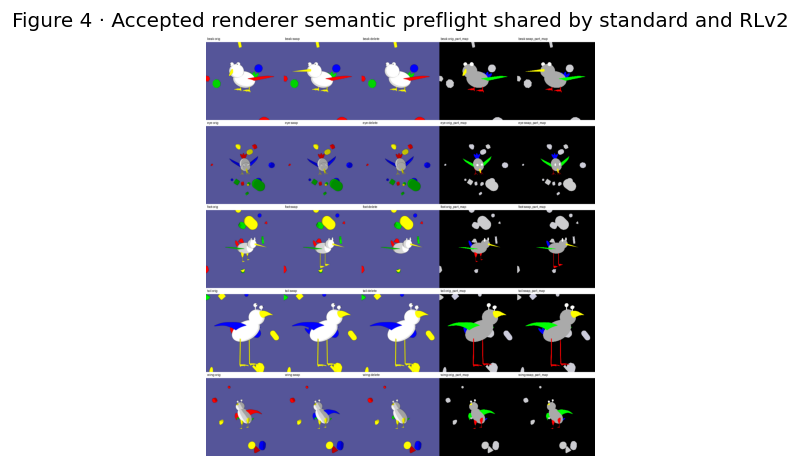

In [2]:
show_standard('f2a','f2b')


**Literal result.** The same render IDs were also asserted when the CSVs were
loaded above.  Thus later differences come from model outputs on matched
pixels.  **Next question:** were the ordinary concept outputs healthy before
examining swaps?


## 2. Ordinary-image health: first rule out collapse

**Question and prediction.** A swap failure is uninterpretable if the concept
coordinate is numerically collapsed or cannot separate its ordinary 0/1
labels.  Healthy models should have nonzero raw-score spread and above-chance
balanced accuracy.

**Standard baseline.** Figure 1 below is copied exactly from executed
Notebook 02.  Its definitions and per-concept denominators remain unchanged.
The MCBM panel then evaluates every gamma on its saved ordinary export.

**MCBM quantities.** For each concept `j`, raw-logit spread is
`Q95(z_j)-Q05(z_j)`. Balanced accuracy is one half of positive recall plus
negative recall after thresholding `z_j` at zero. `h` target RMSE is
`sqrt(mean((h_j-(6c_j-3))^2))`.  Lower target RMSE means compression toward
the label target; it is not grounding evidence.


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f3-`**

,regime,images,task_accuracy,sigmoid_replay_error
0,standard,500,0.992,0.0
1,RLv2,500,0.988,0.0


,regime,concept,part,spread,label_separation,balanced_accuracy,positive_recall
0,standard,beak_0,beak,10.054,8.069,0.994,0.990
1,standard,beak_1,beak,12.014,10.326,0.994,0.990
2,standard,beak_2,beak,13.487,11.214,0.999,1.000
3,standard,beak_3,beak,11.431,8.898,0.996,0.992
4,standard,eye_0,eye,11.156,9.241,0.989,0.987
5,standard,eye_1,eye,10.891,8.934,0.988,0.975
6,standard,eye_2,eye,10.699,8.428,0.985,0.979
7,standard,foot_0,foot,11.098,8.940,0.999,1.000
8,standard,foot_1,foot,11.551,9.560,0.995,0.990
9,standard,foot_2,foot,11.267,8.639,0.993,0.986


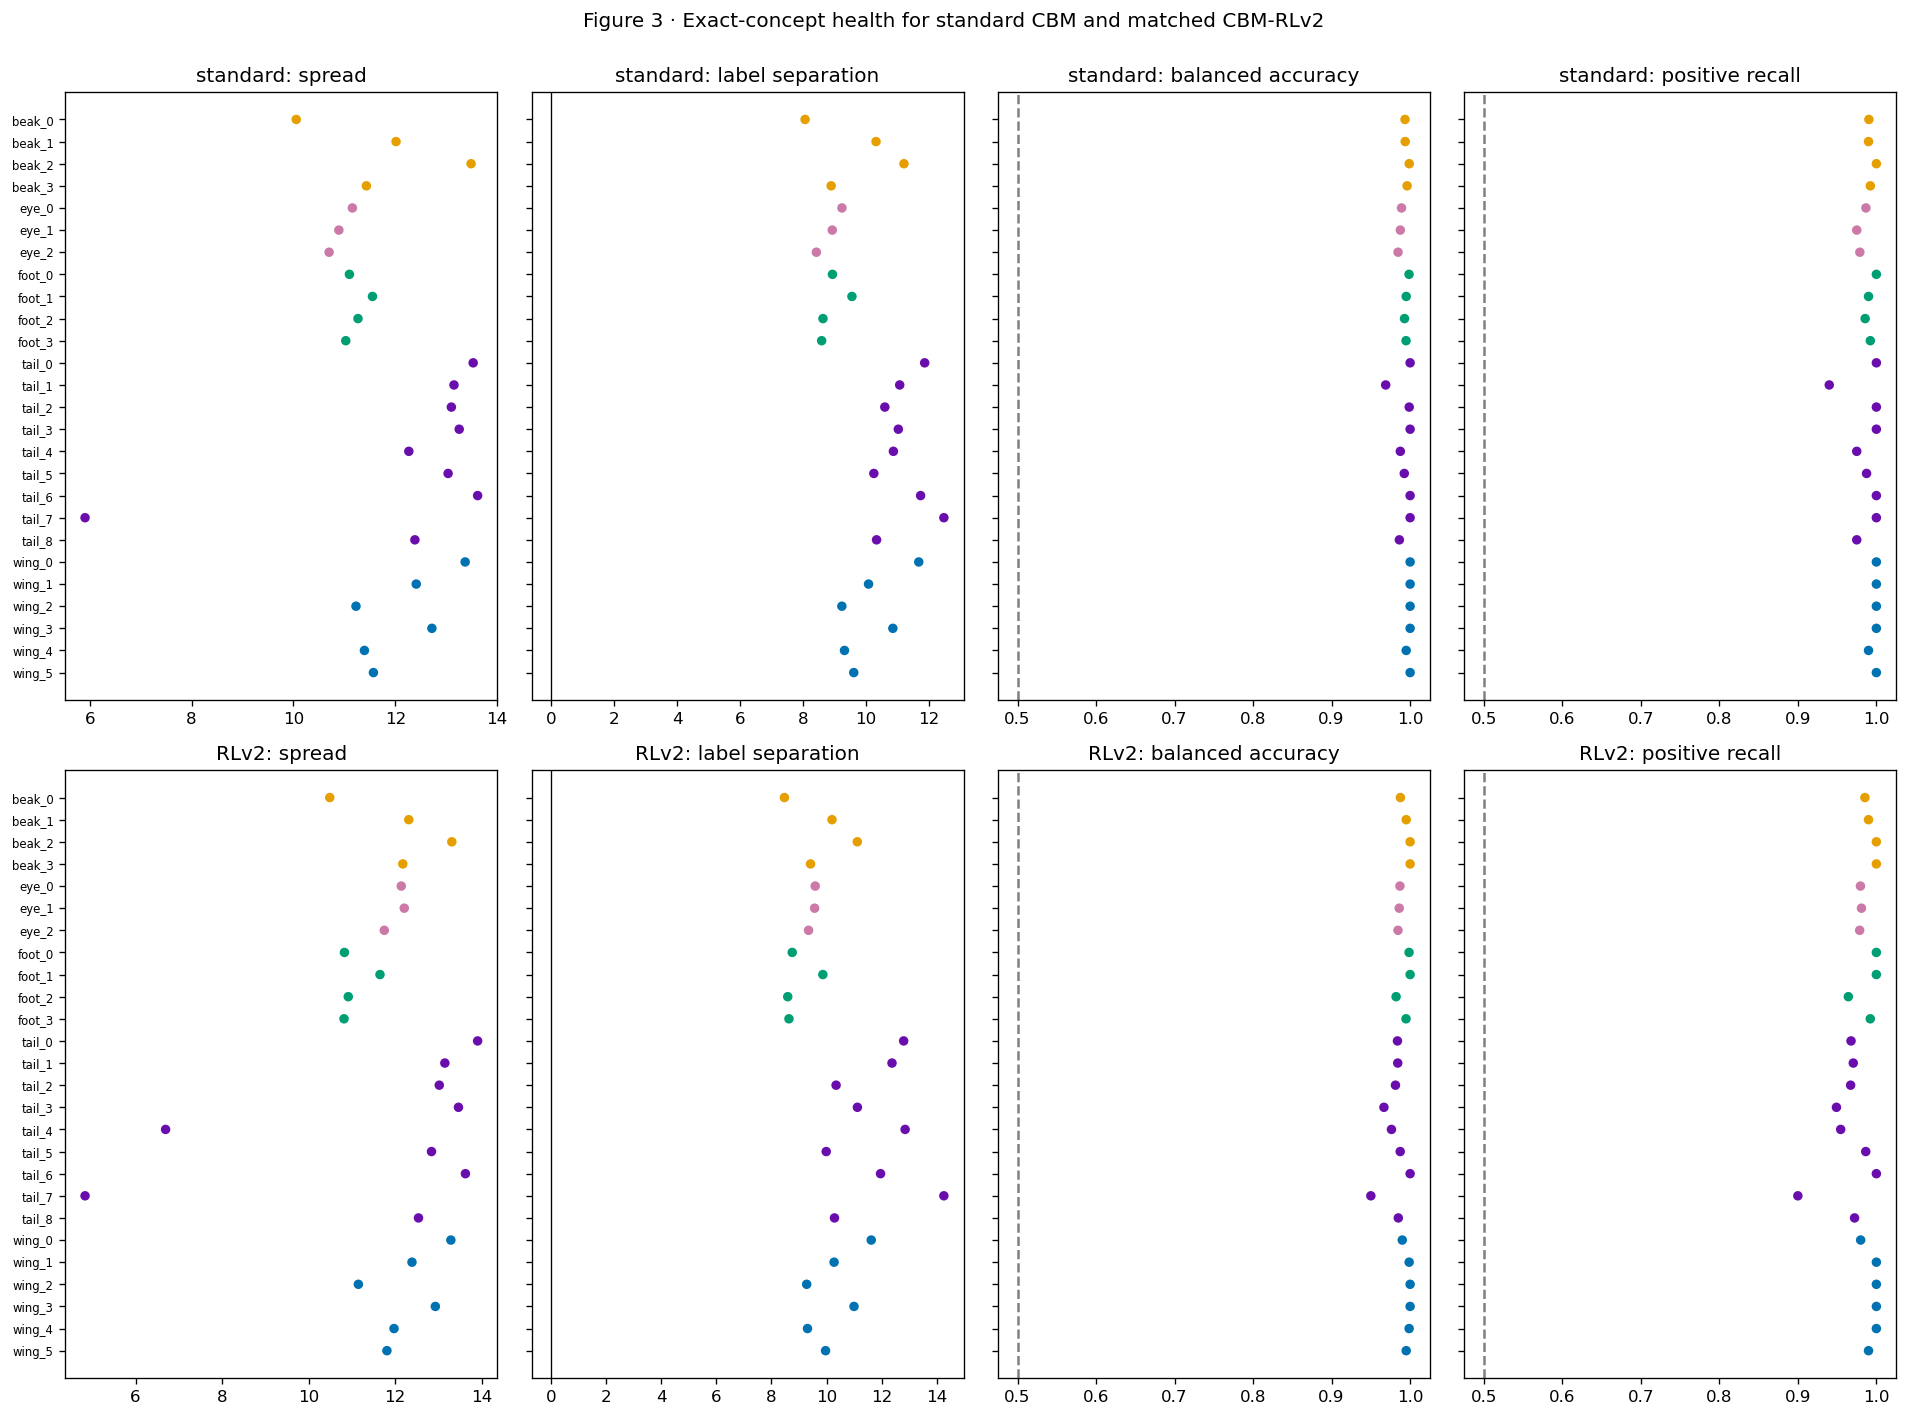

In [3]:
show_standard('f1')


### Executed Standard-MCBM result — health-mcbm

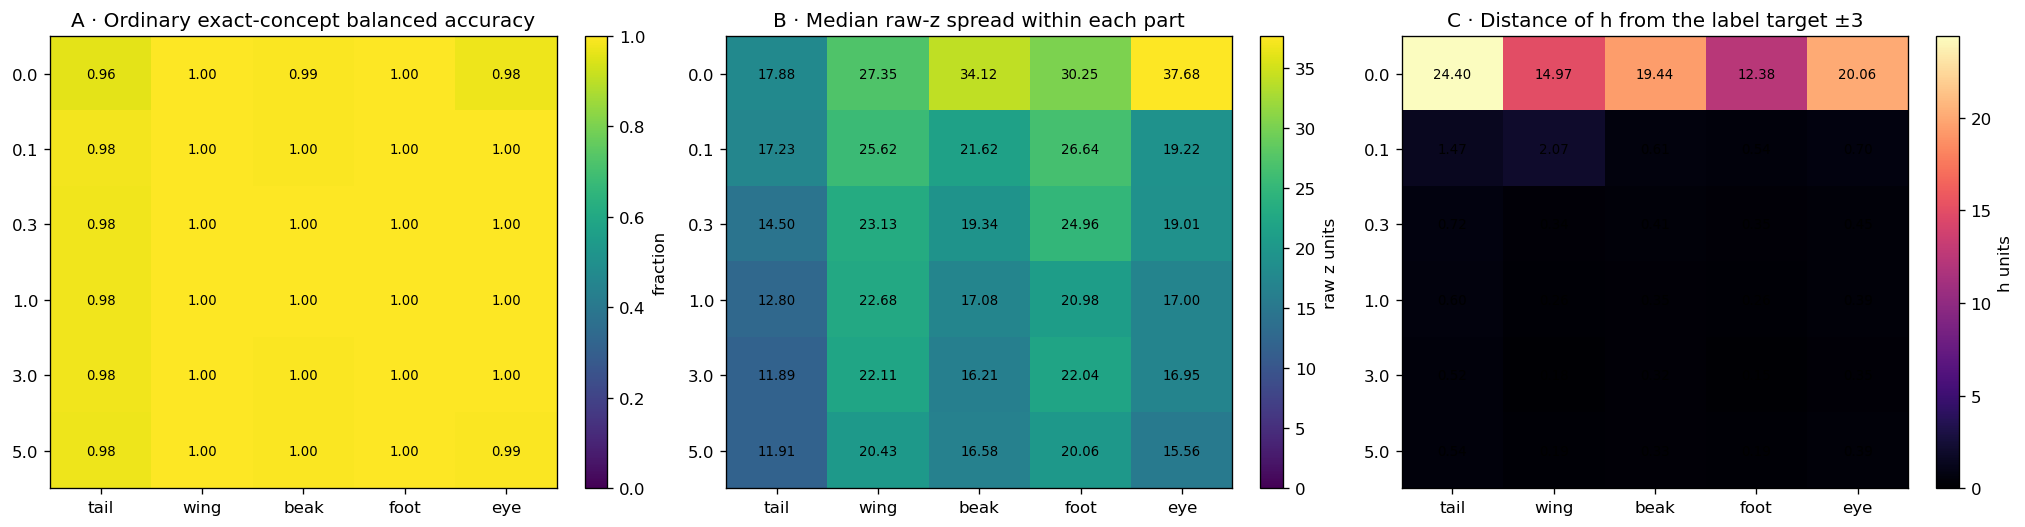

**Table — ordinary MCBM health values behind the three panels.** `balanced_accuracy` is a 0–1 classification rate; `median_z_spread` is the middle concept coordinate’s 95th-minus-5th percentile in raw-logit units; `h_target_RMSE` is the typical distance, in internal-h units, from the requested label target −3 or +3. Rows are gamma/part pairs.

,gamma,part,balanced_accuracy,median_z_spread,h_target_RMSE
0,0.0,tail,0.9592,17.8793,24.3984
1,0.0,wing,0.9991,27.3485,14.9701
2,0.0,beak,0.9946,34.1220,19.4420
3,0.0,foot,0.9985,30.2515,12.3800
4,0.0,eye,0.9757,37.6843,20.0627
5,0.1,tail,0.9813,17.2324,1.4667
6,0.1,wing,0.9993,25.6214,2.0694
7,0.1,beak,0.9960,21.6238,0.6150
8,0.1,foot,0.9991,26.6428,0.5399
9,0.1,eye,0.9964,19.2201,0.6970


In [4]:
show_standard_mcbm('health-mcbm')


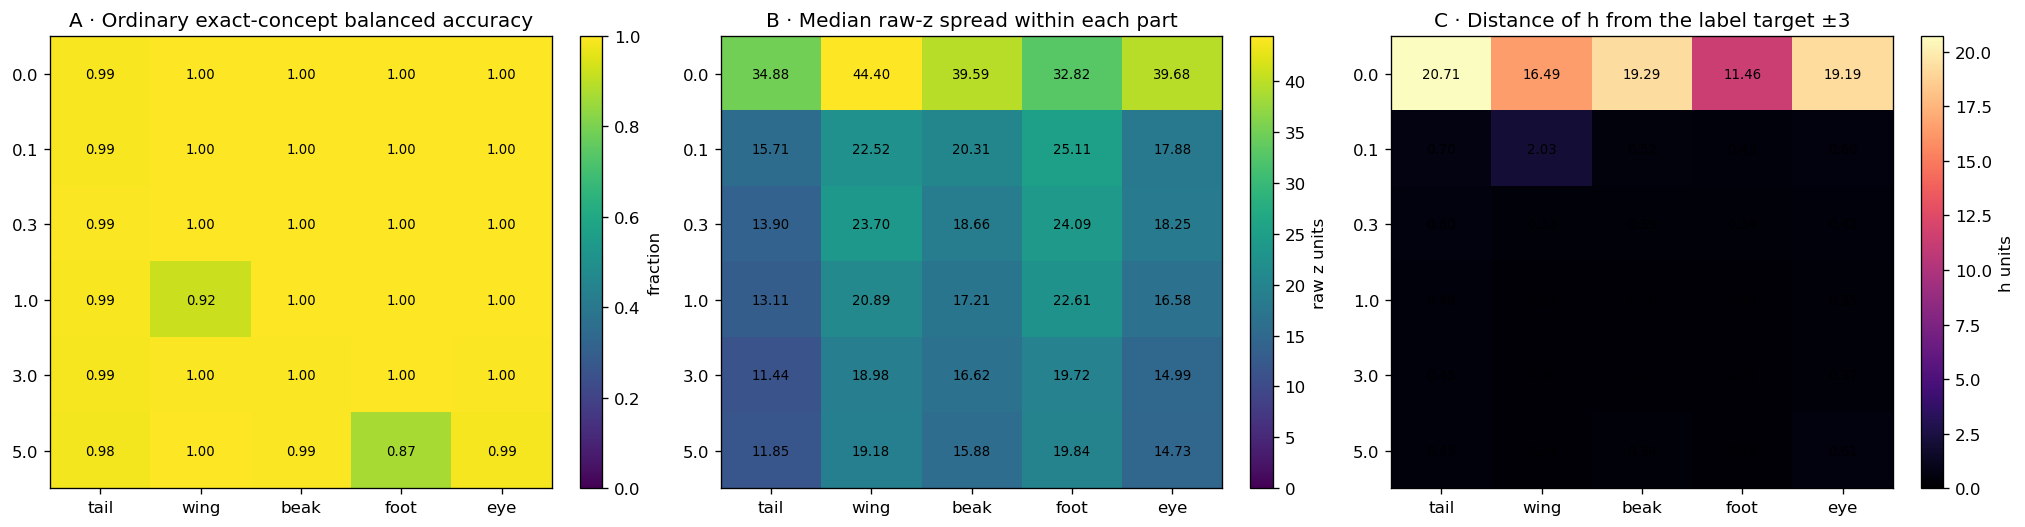

**Table — ordinary MCBM health values behind the three panels.** `balanced_accuracy` is a 0–1 classification rate; `median_z_spread` is the middle concept coordinate’s 95th-minus-5th percentile in raw-logit units; `h_target_RMSE` is the typical distance, in internal-h units, from the requested label target −3 or +3. Rows are gamma/part pairs.

,gamma,part,balanced_accuracy,median_z_spread,h_target_RMSE
0,0.0,tail,0.9921,34.8795,20.7115
1,0.0,wing,0.9993,44.4025,16.4860
2,0.0,beak,0.9971,39.5879,19.2867
3,0.0,foot,0.9995,32.8189,11.4628
4,0.0,eye,0.9968,39.6789,19.1899
5,0.1,tail,0.9916,15.7054,0.7004
6,0.1,wing,0.9994,22.5220,2.0304
7,0.1,beak,0.9966,20.3104,0.5168
8,0.1,foot,0.9992,25.1055,0.4329
9,0.1,eye,0.9973,17.8834,0.6000


In [5]:
from minimal_cbm_scores import concept_logits_from_saved_latent, validate_saved_probabilities
health=[]; per_part=[]
for g in GAMMAS:
    base=REPO/'external/minimal_cbm/results'/f'funnybirds-mcbm-rlv2matched-{TAG[g]}'/'1'
    d=torch.load(base/'predictions/epoch_100.pth',map_location='cpu',weights_only=False)
    h=d['z'].float().reshape(len(d['z']),-1); c=d['c'].float().reshape(len(h),-1)
    z=concept_logits_from_saved_latent(h,base/'models/epoch_100.pt',c.shape[1]).float()
    validate_saved_probabilities(z,d['c_preds'])
    parts=load_parts(Path(os.environ.get('FUNNYBIRDS_ROOT',CURATED/'FunnyBirds')))
    spans=group_slices(parts)
    for part in ORDER:
        lo,hi=spans[part]; zz=z[:,lo:hi]; cc=c[:,lo:hi]
        pred=zz>0
        tpr=((pred)&(cc==1)).sum()/max(1,int((cc==1).sum()))
        tnr=((~pred)&(cc==0)).sum()/max(1,int((cc==0).sum()))
        spreads=[]
        for j in range(lo,hi): spreads.append(float(torch.quantile(z[:,j],.95)-torch.quantile(z[:,j],.05)))
        per_part.append(dict(gamma=g,part=part,balanced_accuracy=float((tpr+tnr)/2),
            median_z_spread=float(np.median(spreads)),h_target_RMSE=float(torch.sqrt(((h[:,lo:hi]-(6*cc-3))**2).mean()))))
HEALTH=pd.DataFrame(per_part)
fig,axes=plt.subplots(1,3,figsize=(17,4.5))
for ax,(col,title,cmap,lo,hi) in zip(axes,[
  ('balanced_accuracy','A · Ordinary exact-concept balanced accuracy','viridis',0,1),
  ('median_z_spread','B · Median raw-z spread within each part','viridis',0,None),
  ('h_target_RMSE','C · Distance of h from the label target ±3','magma',0,None)]):
    table=HEALTH.pivot(index='gamma',columns='part',values=col).reindex(index=GAMMAS,columns=ORDER)
    heat(ax,table,title,'fraction' if col=='balanced_accuracy' else ('raw z units' if col=='median_z_spread' else 'h units'),lo,hi,cmap)
plt.tight_layout(); plt.show()
show_table(
  'ordinary MCBM health values behind the three panels',
  '`balanced_accuracy` is a 0–1 classification rate; `median_z_spread` is '
  'the middle concept coordinate’s 95th-minus-5th percentile in raw-logit units; '
  '`h_target_RMSE` is the typical distance, in internal-h units, from the requested '
  'label target −3 or +3. Rows are gamma/part pairs.', HEALTH.round(4))


**How to read the executed RLv2 result.** The figure and fully
captioned source table immediately above are the result; no expected
observation was written into the notebook before execution.

**Question → test → boundary.** Compare the RLv2 output with the
executed Standard-MCBM output directly above it. A change is evidence
about visibility-aware labels only when model gamma, formula, physical
swap rows, and denominator match. It does not turn an association into
a cause, and seed 1 does not provide initialization uncertainty.

**Next question.** Continue to the next identical analysis stage, then
use the final matched-difference table to decide which part and pathway
actually changed.


## 3. Transition A — Koh Standard to MCBM gamma 0

This transition changes architecture and recipe together: shared projector,
private `q_j` readers, injected training noise, nonlinear species head,
preprocessing, optimizer details, and uncontrolled initialization.  Gamma is
zero, so the minimality penalty cannot explain this transition.

**Question.** Which part of the swap computation changes first?

**Prediction.** If MCBM gamma 0 damage is mainly inside `q_j`, label-calibrated
`h` will recognize the donor but final `z=q(h)` will not.  If `h` already
fails, the representation/encoder stage is the earlier location.

**Standard reference.** The next outputs are Notebook 02's exact donorward
response, five-term decomposition, backwash predicate, and exhaustive
three-way pairwise outcome. They are intentionally not redrawn.


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f7b-`**

/tmp/tmp.Hs29m9YPc8/ipykernel_2363314/3938580946.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout();plt.show()


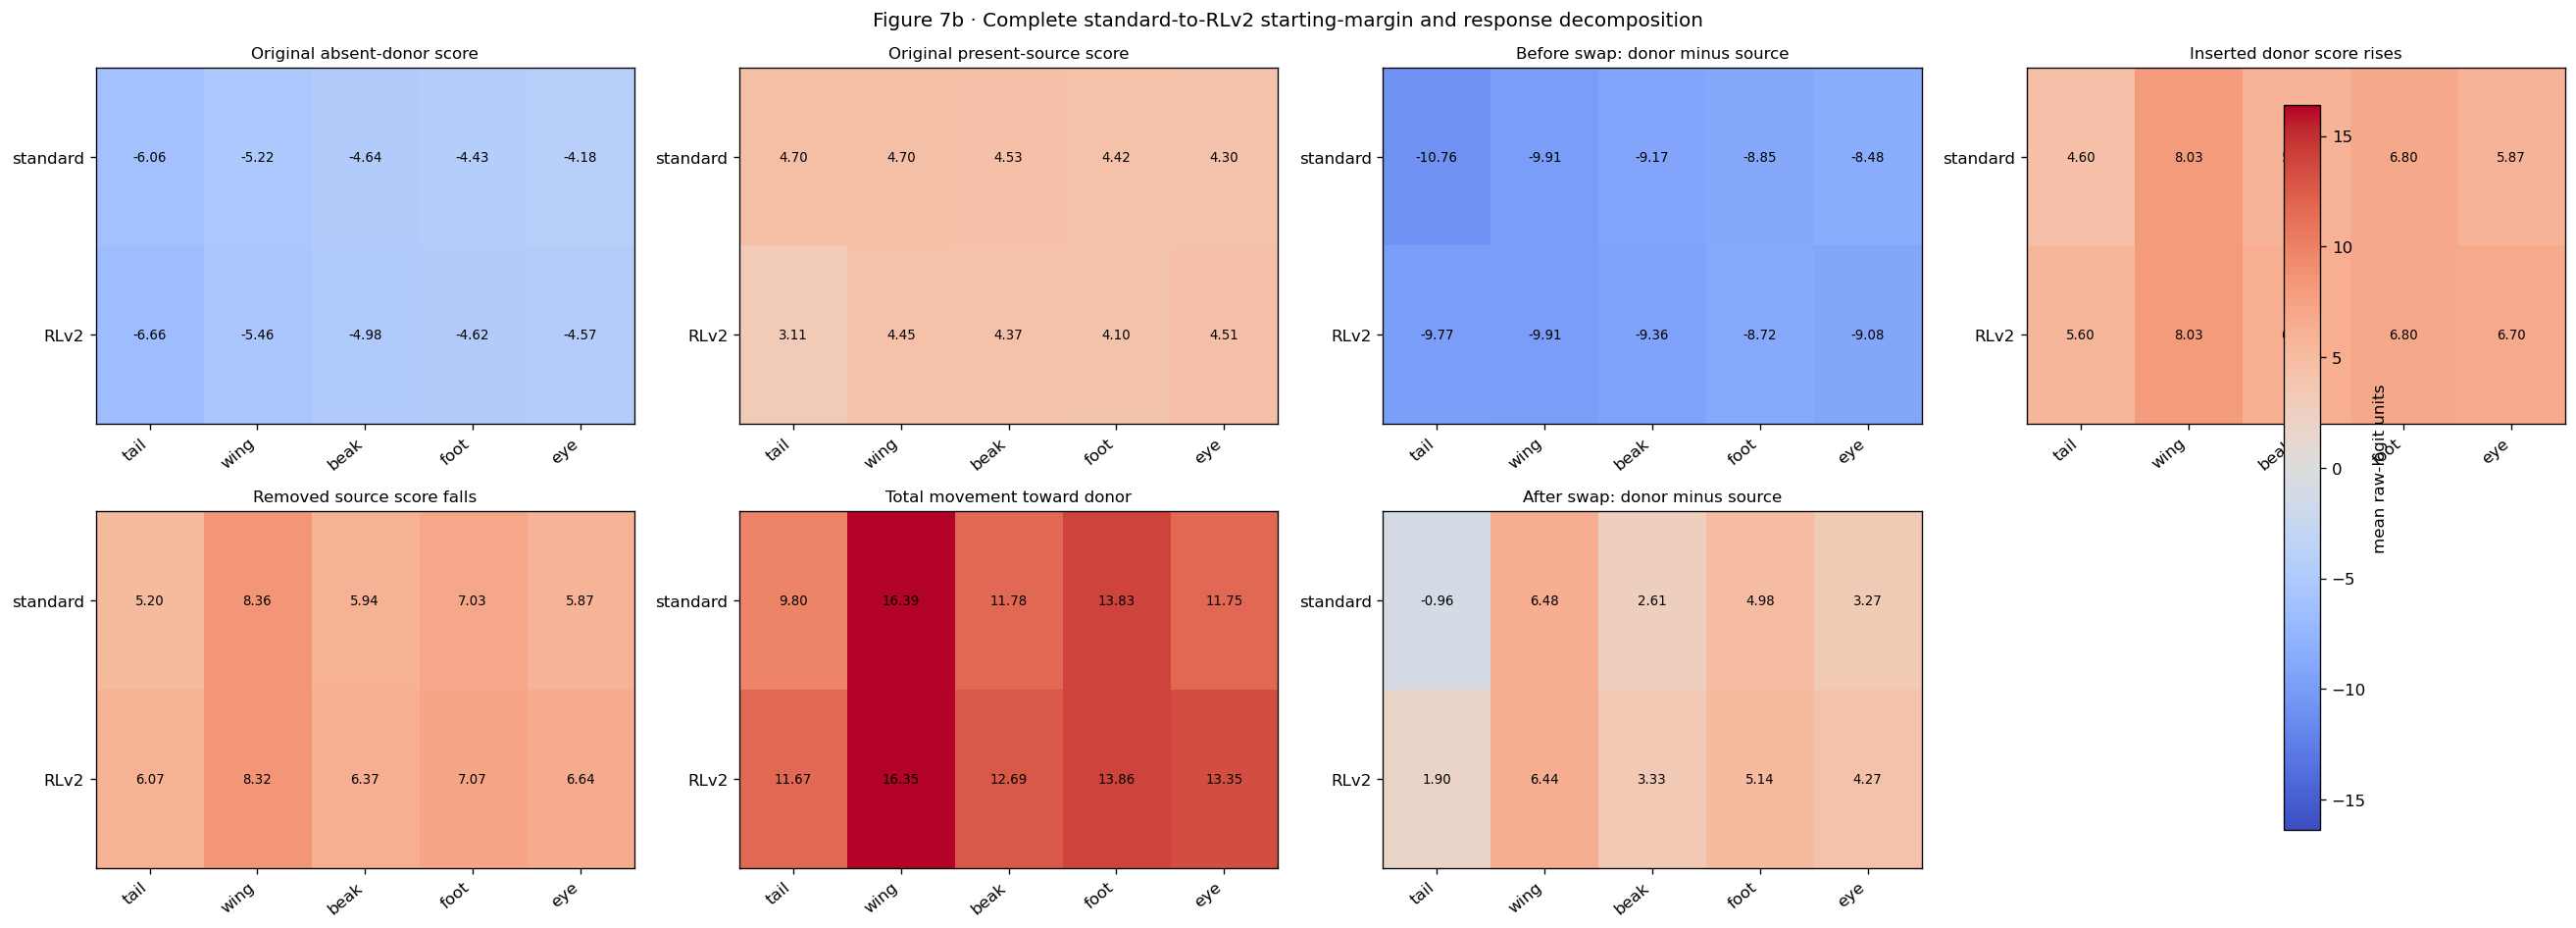

tail    wing    beak    foot     eye
component       regime                                          
D_orig          standard  -6.057  -5.217  -4.640  -4.429  -4.184
                RLv2      -6.656  -5.463  -4.983  -4.623  -4.565
S_orig          standard   4.699   4.697   4.527   4.418   4.297
                RLv2       3.109   4.446   4.372   4.099   4.515
m_orig          standard -10.756  -9.914  -9.167  -8.847  -8.481
                RLv2      -9.766  -9.909  -9.355  -8.722  -9.080
donor_gain      standard   4.599   8.029   5.842   6.804   5.875
                RLv2       5.599   8.028   6.318   6.796   6.702
source_decrease standard   5.201   8.361   5.936   7.027   5.874
                RLv2       6.070   8.323   6.368   7.068   6.645
response_delta  standard   9.800  16.390  11.778  13.831  11.749
                RLv2      11.669  16.351  12.686  13.864  13.347
m_cf            standard  -0.956   6.476   2.611   4.984   3.268
                RLv2       1.903   6.442   3.331   5.142   4.267

**RLv2 minus standard (positive and negative retain each component's defined direction):**

,tail,wing,beak,foot,eye
D_orig,-0.599,-0.246,-0.343,-0.194,-0.381
S_orig,-1.590,-0.251,-0.155,-0.319,0.217
m_orig,0.990,0.005,-0.188,0.125,-0.599
donor_gain,1.000,-0.000,0.476,-0.008,0.827
source_decrease,0.869,-0.038,0.432,0.041,0.770
response_delta,1.869,-0.038,0.908,0.033,1.598
m_cf,2.859,-0.034,0.720,0.158,0.999


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f5-`**

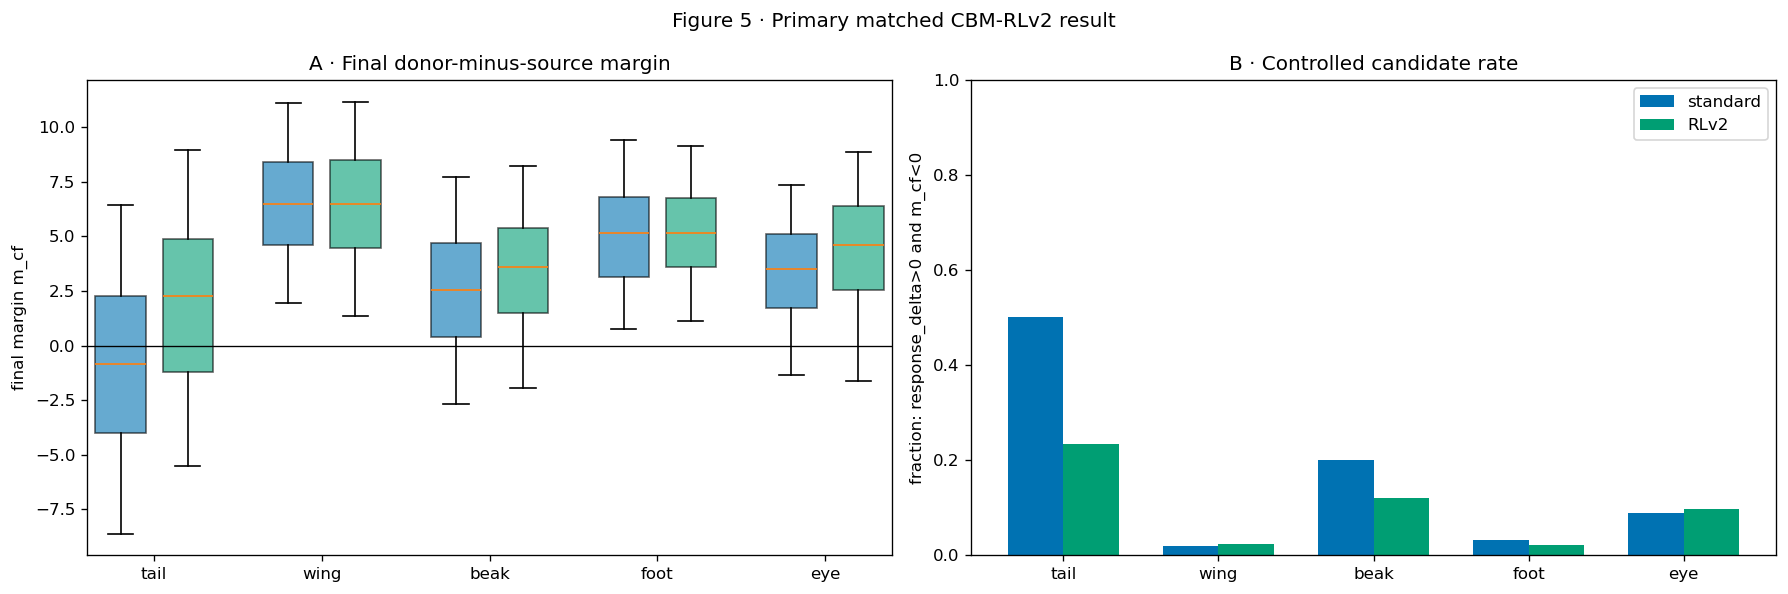

,standard,RLv2,n
part,,,
tail,0.502,0.234,1000
wing,0.019,0.023,1000
beak,0.200,0.120,1000
foot,0.032,0.022,1000
eye,0.089,0.098,1000


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f5b-`**

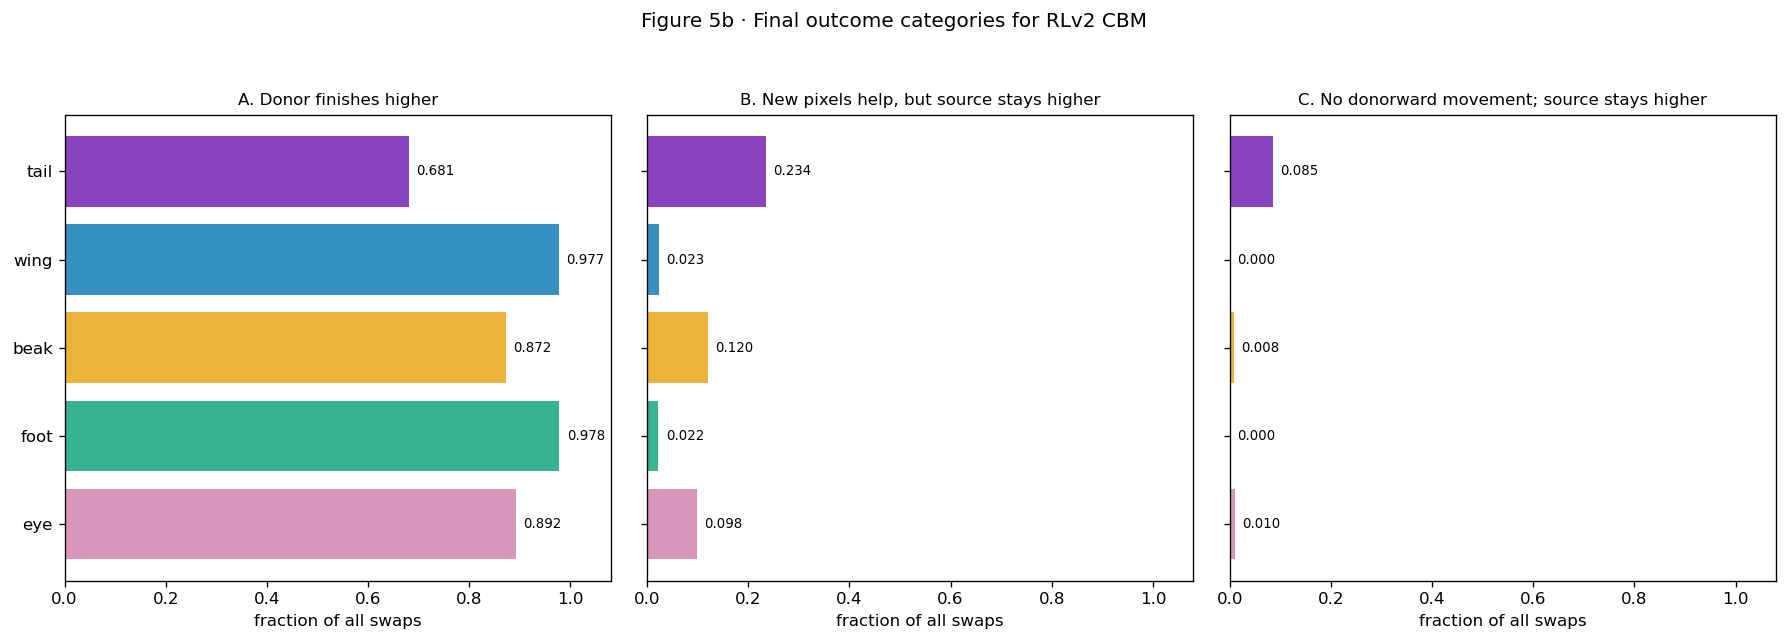

,donor_wins,helped_but_source_wins,no_donorward_move_and_source_wins
tail,0.681,0.234,0.085
wing,0.977,0.023,0.000
beak,0.872,0.120,0.008
foot,0.978,0.022,0.000
eye,0.892,0.098,0.010


In [6]:
show_standard('f3','f3b','f4','f4b')


In [7]:
show_standard_mcbm('response-audit')


### Executed Standard-MCBM result — response-audit

### Response-field accounting

**Table — historical response-column audit.** For each accepted file, this compares its stored response with the declared recalculation `m_cf-m_orig`. `positive_sign_disagreements` counts rows whose direction changes; `controlled_event_disagreements` counts rows whose backwash classification changes.

,model,historical_column_present,n_rows,maximum_absolute_difference,positive_sign_disagreements,controlled_event_disagreements
0,Koh Standard,True,5000,0.0,6,6
1,MCBM γ0,True,5000,0.0,18,18
2,MCBM γ0.1,True,5000,0.0,6,6
3,MCBM γ0.3,True,5000,0.0,10,10
4,MCBM γ1,True,5000,0.0,5,5
5,MCBM γ3,True,5000,0.0,17,17
6,MCBM γ5,True,5000,0.0,7,7


The declared quantity used below is always computed as
`response_delta = m_cf - m_orig`. The table compares that formula with any
historical `response_delta` column carried in the accepted CSV. There are
**69** row-level controlled-event disagreements across all seven
files. These are boundary-accounting differences, not new model inference;
the formula-derived columns drive every new comparison in this chapter.

In [8]:
display(Markdown('### Response-field accounting'))
show_table(
  'historical response-column audit',
  'For each accepted file, this compares its stored response with the declared '
  'recalculation `m_cf-m_orig`. `positive_sign_disagreements` counts rows whose '
  'direction changes; `controlled_event_disagreements` counts rows whose backwash '
  'classification changes.', RESPONSE_AUDIT.round(6))
disagreements=int(RESPONSE_AUDIT.controlled_event_disagreements.sum())
display(Markdown(f'''The declared quantity used below is always computed as
`response_delta = m_cf - m_orig`. The table compares that formula with any
historical `response_delta` column carried in the accepted CSV. There are
**{disagreements}** row-level controlled-event disagreements across all seven
files. These are boundary-accounting differences, not new model inference;
the formula-derived columns drive every new comparison in this chapter.'''))


### Response-field accounting

**Table — historical response-column audit.** For each accepted file, this compares its stored response with the declared recalculation `m_cf-m_orig`. `positive_sign_disagreements` counts rows whose direction changes; `controlled_event_disagreements` counts rows whose backwash classification changes.

,model,historical_column_present,n_rows,maximum_absolute_difference,positive_sign_disagreements,controlled_event_disagreements
0,Koh RLv2,True,5000,0.0,9,9
1,RLv2 MCBM γ0,True,5000,0.0,18,17
2,RLv2 RLv2 MCBM γ0.1,True,5000,0.0,19,13
3,RLv2 RLv2 MCBM γ0.3,True,5000,0.0,10,10
4,RLv2 MCBM γ1,True,5000,0.0,18,17
5,RLv2 MCBM γ3,True,5000,0.0,13,13
6,RLv2 MCBM γ5,True,5000,0.0,18,10


The declared quantity used below is always computed as
`response_delta = m_cf - m_orig`. The table compares that formula with any
historical `response_delta` column carried in the accepted CSV. There are
**89** row-level controlled-event disagreements across all seven
files. These are boundary-accounting differences, not new model inference;
the formula-derived columns drive every new comparison in this chapter.

### Matched MCBM outcome accounting

Rows are gamma and columns are parts. Every cell uses all 1,000 swaps for
that gamma/part.  Panel A asks whether the donor is largest among every exact
value. B asks whether the old value is largest. C records a third value.
D is `response_delta<=0`. E is the controlled backwash predicate
`response_delta>0 and m_cf<0`. Exact-winner panels partition all rows; D/E
are pairwise diagnostics and overlap with the exact categories, so their
percentages must not be added to A/B/C.


### Executed Standard-MCBM result — outcomes

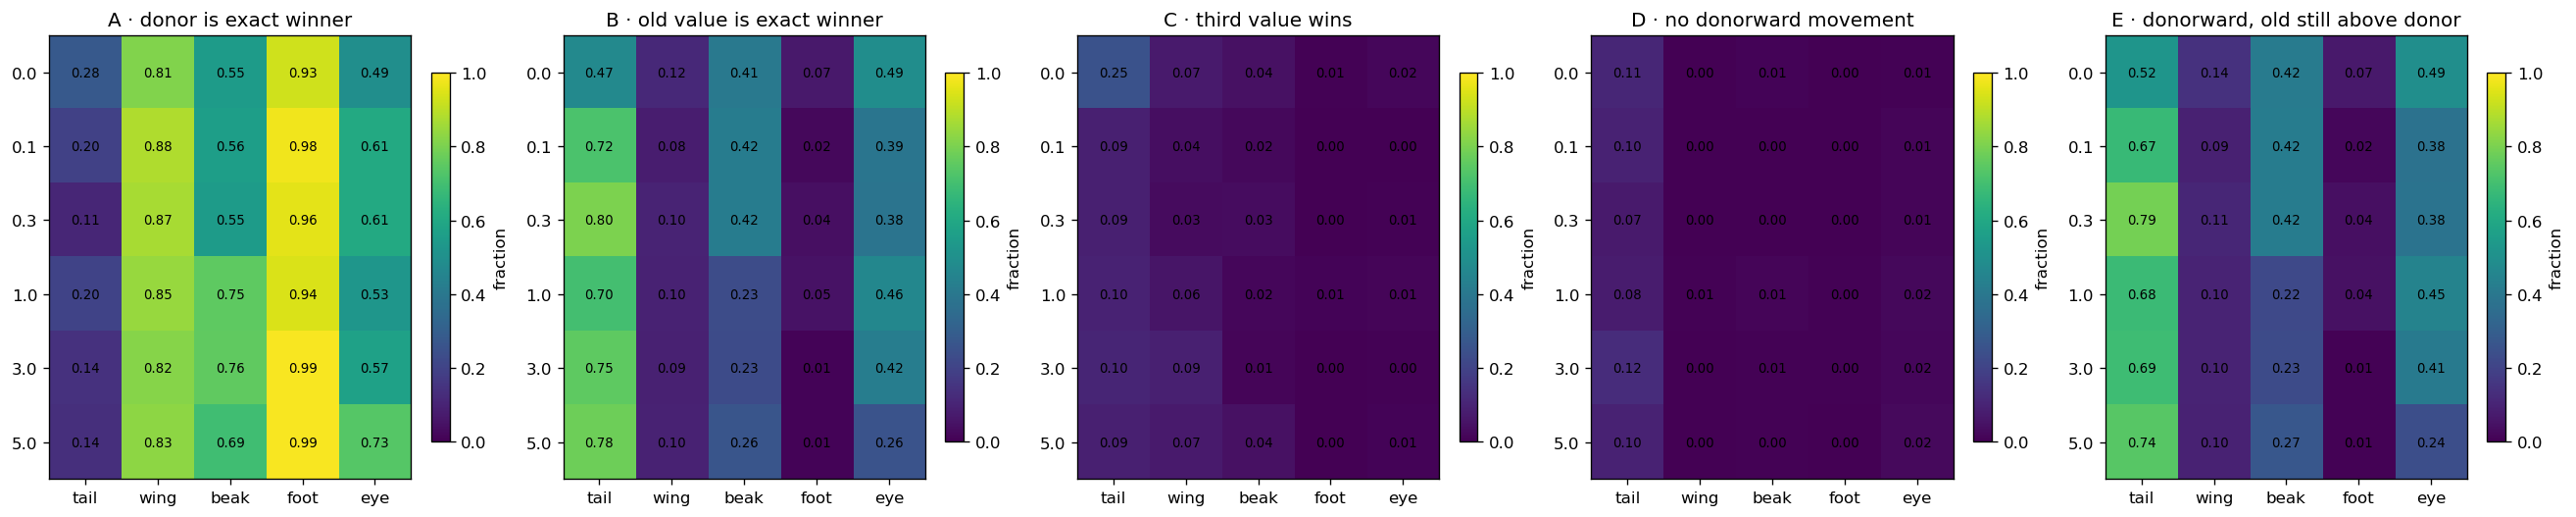

**Table — complete exact-outcome fractions behind Panels A–E.** Each row contains 1,000 swaps for one gamma and part. The first three fractions partition exact-value winners. The final two are separate pairwise predicates and must not be added to the first three.

,gamma,part,n,exact_donor,exact_source,exact_third,no_donorward_move,backwash
0,0.0,beak,1000,0.550,0.405,0.045,0.010,0.416
1,0.0,eye,1000,0.495,0.489,0.016,0.006,0.494
2,0.0,foot,1000,0.926,0.069,0.005,0.001,0.070
3,0.0,tail,1000,0.278,0.470,0.252,0.106,0.522
4,0.0,wing,1000,0.811,0.116,0.073,0.000,0.143
5,0.1,beak,1000,0.562,0.418,0.020,0.002,0.418
6,0.1,eye,1000,0.609,0.390,0.001,0.013,0.378
7,0.1,foot,1000,0.978,0.021,0.001,0.003,0.019
8,0.1,tail,1000,0.195,0.716,0.089,0.097,0.672
9,0.1,wing,1000,0.881,0.082,0.037,0.001,0.092


In [9]:
show_standard_mcbm('outcomes')


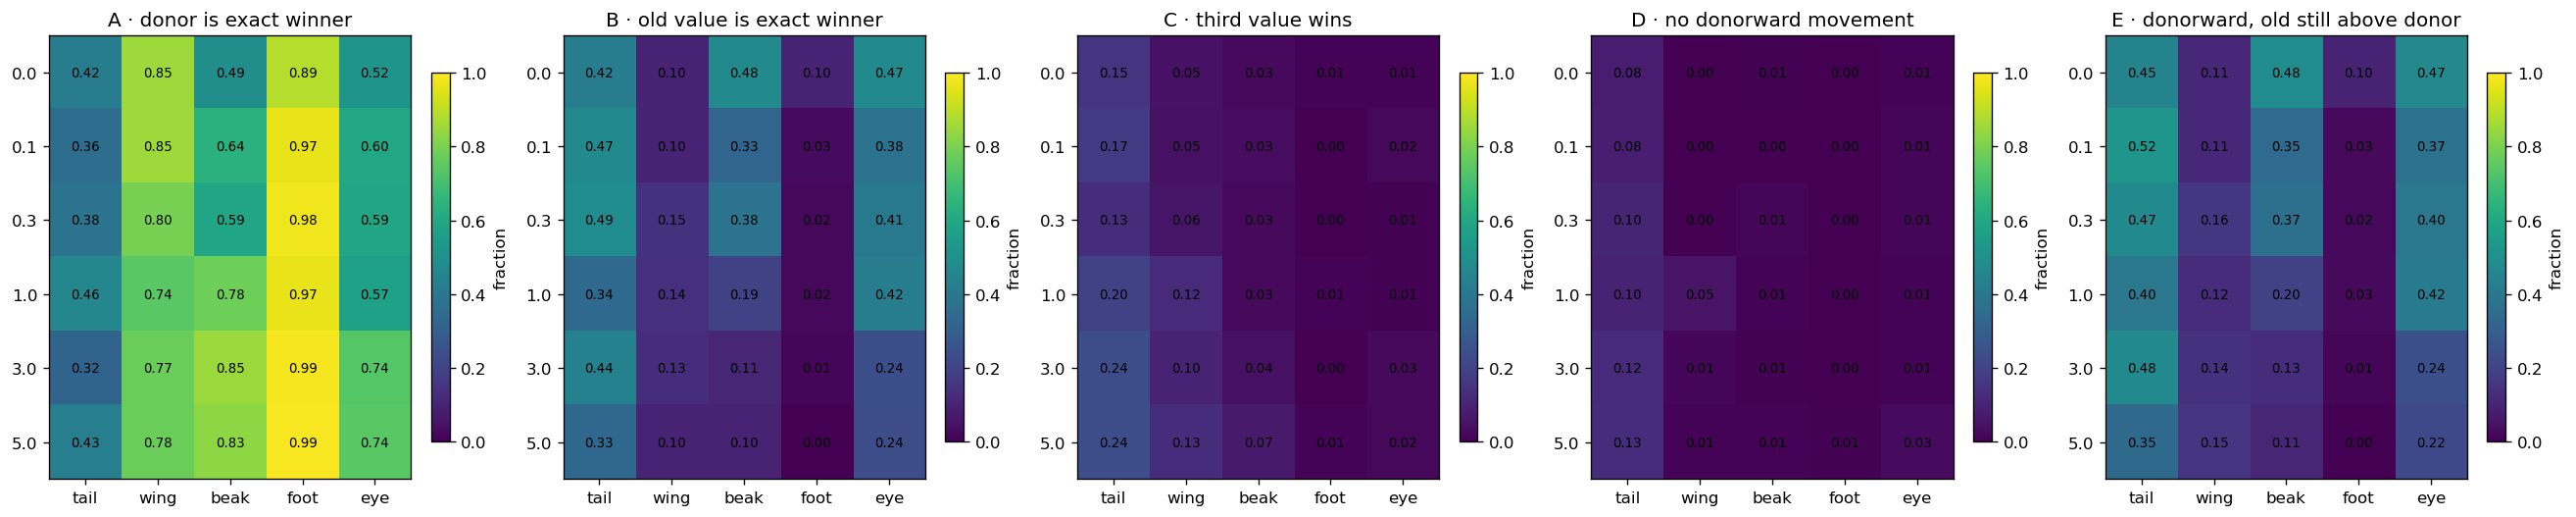

**Table — complete exact-outcome fractions behind Panels A–E.** Each row contains 1,000 swaps for one gamma and part. The first three fractions partition exact-value winners. The final two are separate pairwise predicates and must not be added to the first three.

,gamma,part,n,exact_donor,exact_source,exact_third,no_donorward_move,backwash
0,0.0,beak,1000,0.495,0.479,0.026,0.006,0.485
1,0.0,eye,1000,0.516,0.473,0.011,0.010,0.471
2,0.0,foot,1000,0.890,0.099,0.011,0.003,0.098
3,0.0,tail,1000,0.425,0.425,0.150,0.078,0.448
4,0.0,wing,1000,0.853,0.099,0.048,0.000,0.110
5,0.1,beak,1000,0.639,0.328,0.033,0.001,0.351
6,0.1,eye,1000,0.601,0.378,0.021,0.013,0.374
7,0.1,foot,1000,0.967,0.030,0.003,0.003,0.027
8,0.1,tail,1000,0.356,0.474,0.170,0.084,0.521
9,0.1,wing,1000,0.854,0.100,0.046,0.000,0.110


In [10]:
out=[]
for g,d in MCBM.items():
    for part,q in d.groupby('part'):
        out.append(dict(gamma=g,part=part,n=len(q),exact_donor=q.exact_donor.mean(),
          exact_source=q.exact_source.mean(),exact_third=q.exact_third.mean(),
          no_donorward_move=q.no_donorward_move.mean(),backwash=q.backwash.mean()))
OUT=pd.DataFrame(out)
fig,axes=plt.subplots(1,5,figsize=(22,4.5))
for ax,(col,title) in zip(axes,[('exact_donor','A · donor is exact winner'),('exact_source','B · old value is exact winner'),
  ('exact_third','C · third value wins'),('no_donorward_move','D · no donorward movement'),('backwash','E · donorward, old still above donor')]):
    table=OUT.pivot(index='gamma',columns='part',values=col).reindex(index=GAMMAS,columns=ORDER)
    heat(ax,table,title,'fraction',0,1,'viridis')
plt.tight_layout(); plt.show()
show_table(
  'complete exact-outcome fractions behind Panels A–E',
  'Each row contains 1,000 swaps for one gamma and part. The first three fractions '
  'partition exact-value winners. The final two are separate pairwise predicates and '
  'must not be added to the first three.', OUT.round(4))


**How to read the executed RLv2 result.** The figure and fully
captioned source table immediately above are the result; no expected
observation was written into the notebook before execution.

**Question → test → boundary.** Compare the RLv2 output with the
executed Standard-MCBM output directly above it. A change is evidence
about visibility-aware labels only when model gamma, formula, physical
swap rows, and denominator match. It does not turn an association into
a cause, and seed 1 does not provide initialization uncertainty.

**Next question.** Continue to the next identical analysis stage, then
use the final matched-difference table to decide which part and pathway
actually changed.


### Where the response is lost

The first five panels average the exact equations defined at the chapter
start.  The last three use the v3 replay audit. “Calibrated h response” first
orients each internal coordinate using ordinary absent/present examples, so
positive always means movement toward the inserted label even if a learned
reader reverses sign. “q breaks h” means `h` selected the donor exact value
but `z=q(h)` did not; “q repairs h” is the reverse.

No new diagnostic classifier is trained. The accepted frozen MCBM checkpoint
is replayed, and the existing `q_j` readers are reused.

**What “the output scale of `q(h)`” means.** Each concept has a learned
one-number reader `q_j`. Its numerical slope and range decide how many raw
`z`-logit units are produced by one movement unit in calibrated `h`. For
example, suppose the inserted pixels move calibrated `h` by `+1.0`. One
gamma's reader might turn that into `+30` raw-`z` units, while another
gamma's reader turns it into `+18`. The second reader has the smaller output
scale. This is not a smaller image, a changed zero threshold, or a probability
rescaling. It is why raw-`z` response must be read beside calibrated-`h`
response rather than treated as a direct measurement of encoder movement.


### Executed Standard-MCBM result — decomp

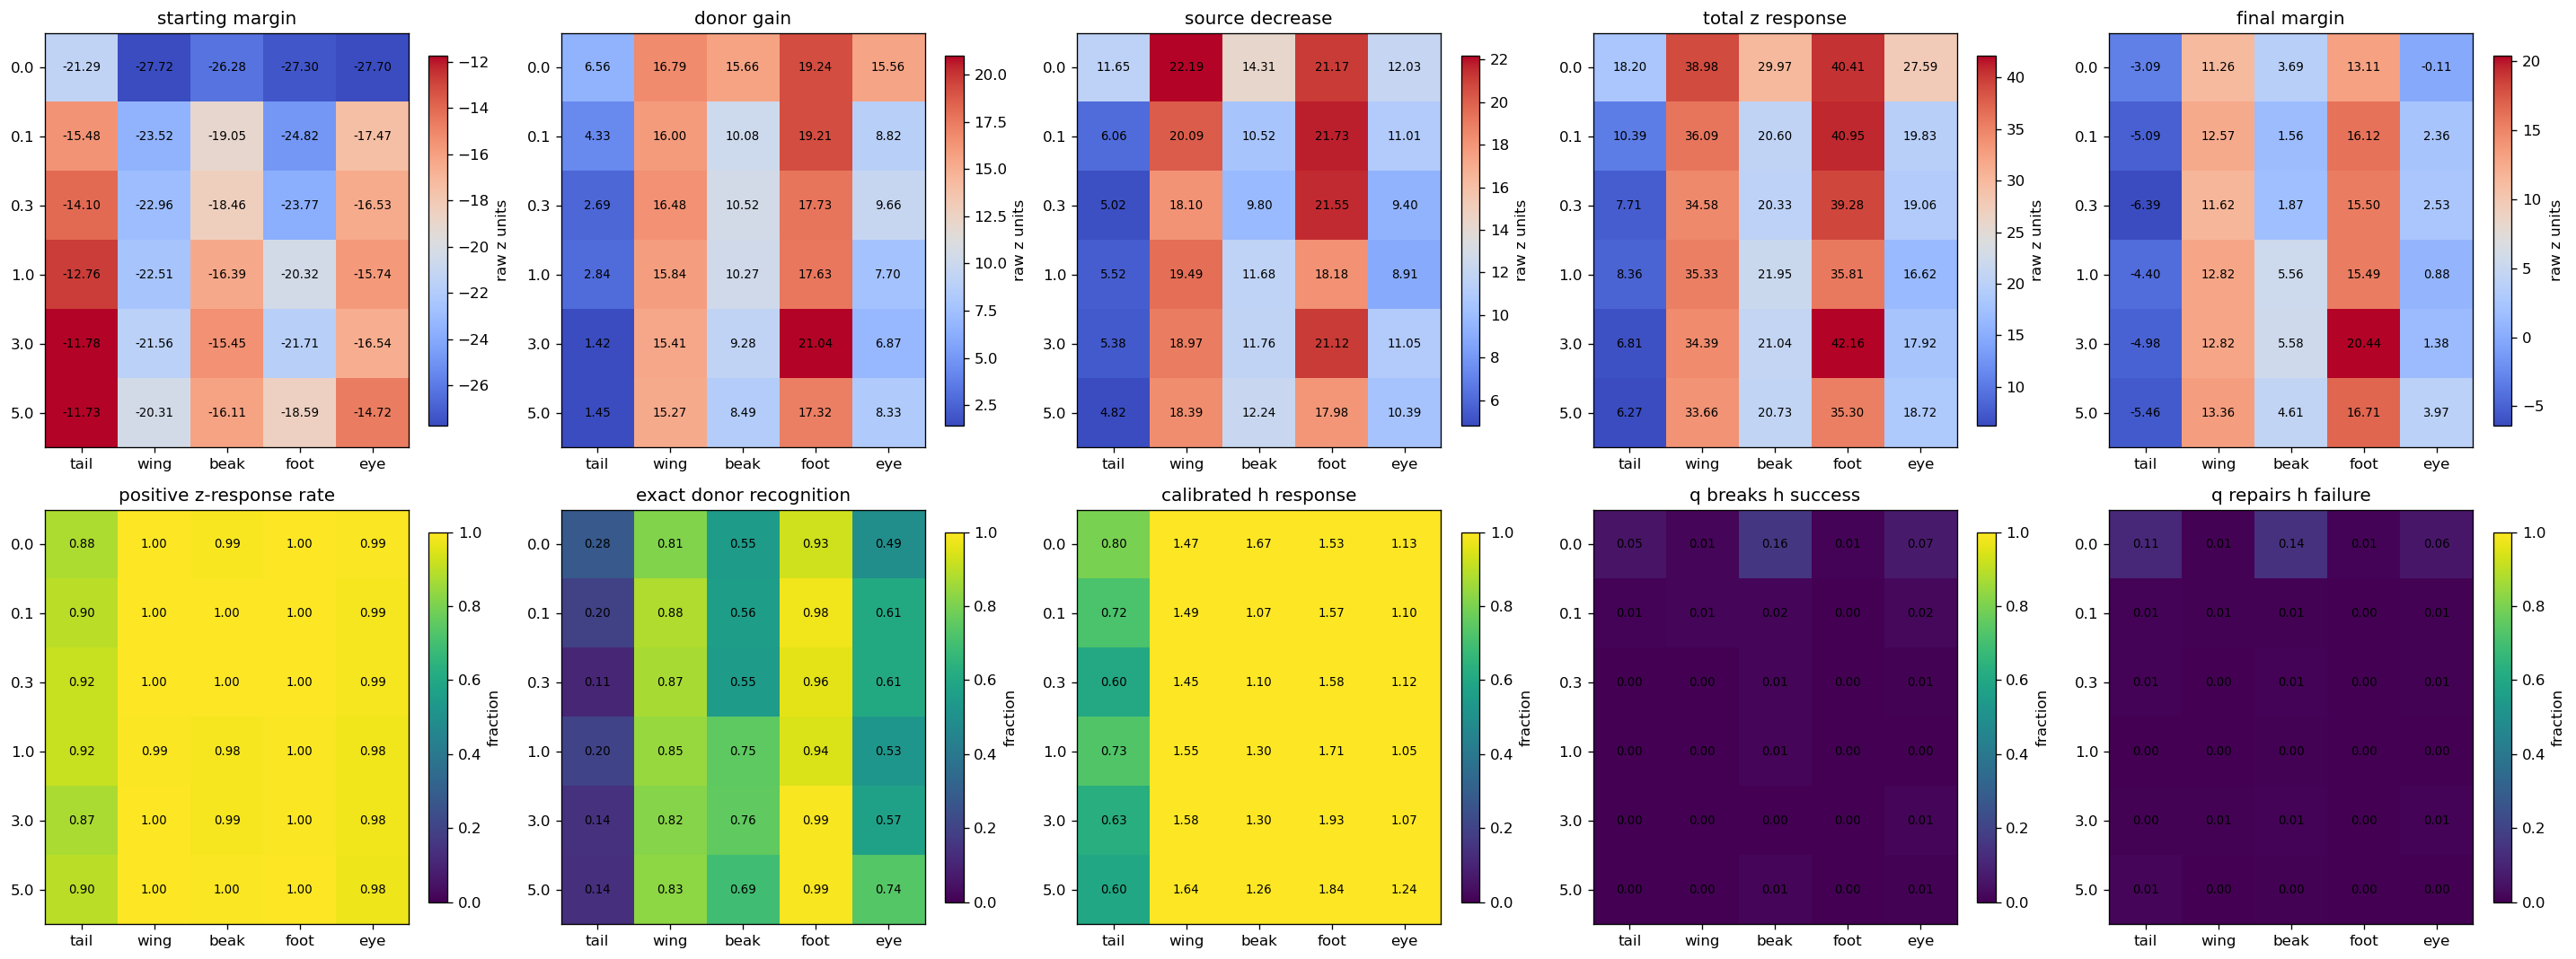

**Table — swap pathway values behind the ten panels.** `mean_z_*` columns are in final raw-logit units. `mean_calibrated_h_response` is in absent-to-present internal units: +1 means the internal donor/source contrast moved by one ordinary-label separation. The two `q_*` columns are fractions of all swaps.

,gamma,part,mean_z_original_margin,mean_z_donor_gain,mean_z_source_decrease,mean_z_response,mean_z_final_margin,z_response_positive_rate,z_exact_donor_recognition,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate
0,0.0,beak,-26.2761,15.6628,14.3051,29.9679,3.6913,0.9890,0.5500,1.6694,0.157,0.143
1,0.0,eye,-27.7016,15.5603,12.0325,27.5928,-0.1089,0.9930,0.4950,1.1258,0.072,0.062
2,0.0,foot,-27.3011,19.2414,21.1727,40.4141,13.1119,0.9990,0.9260,1.5296,0.010,0.008
3,0.0,tail,-21.2911,6.5583,11.6452,18.2035,-3.0875,0.8780,0.2780,0.7978,0.054,0.113
4,0.0,wing,-27.7178,16.7892,22.1926,38.9818,11.2639,1.0000,0.8110,1.4721,0.013,0.007
5,0.1,beak,-19.0454,10.0847,10.5177,20.6024,1.5570,0.9980,0.5620,1.0731,0.018,0.007
6,0.1,eye,-17.4695,8.8220,11.0055,19.8274,2.3580,0.9870,0.6090,1.1049,0.020,0.007
7,0.1,foot,-24.8221,19.2119,21.7348,40.9467,16.1246,0.9970,0.9780,1.5739,0.000,0.000
8,0.1,tail,-15.4800,4.3278,6.0593,10.3871,-5.0928,0.8960,0.1950,0.7175,0.011,0.009
9,0.1,wing,-23.5205,15.9987,20.0923,36.0909,12.5707,0.9990,0.8810,1.4894,0.013,0.006


**Table — ordinary source-image species health for the matched replay population.** This checks that pathway comparisons are not artifacts of a different set of original images. Accuracy is a 0–1 fraction; `n_originals` is its denominator.

,gamma,n_images,species_accuracy,mean_true_species_probability
0,0.0,250,0.992,0.9917
1,0.1,250,0.988,0.9877
2,0.3,250,0.988,0.9890
3,1.0,250,1.000,0.9975
4,3.0,250,0.996,0.9941
5,5.0,250,0.984,0.9851


In [11]:
show_standard_mcbm('decomp')


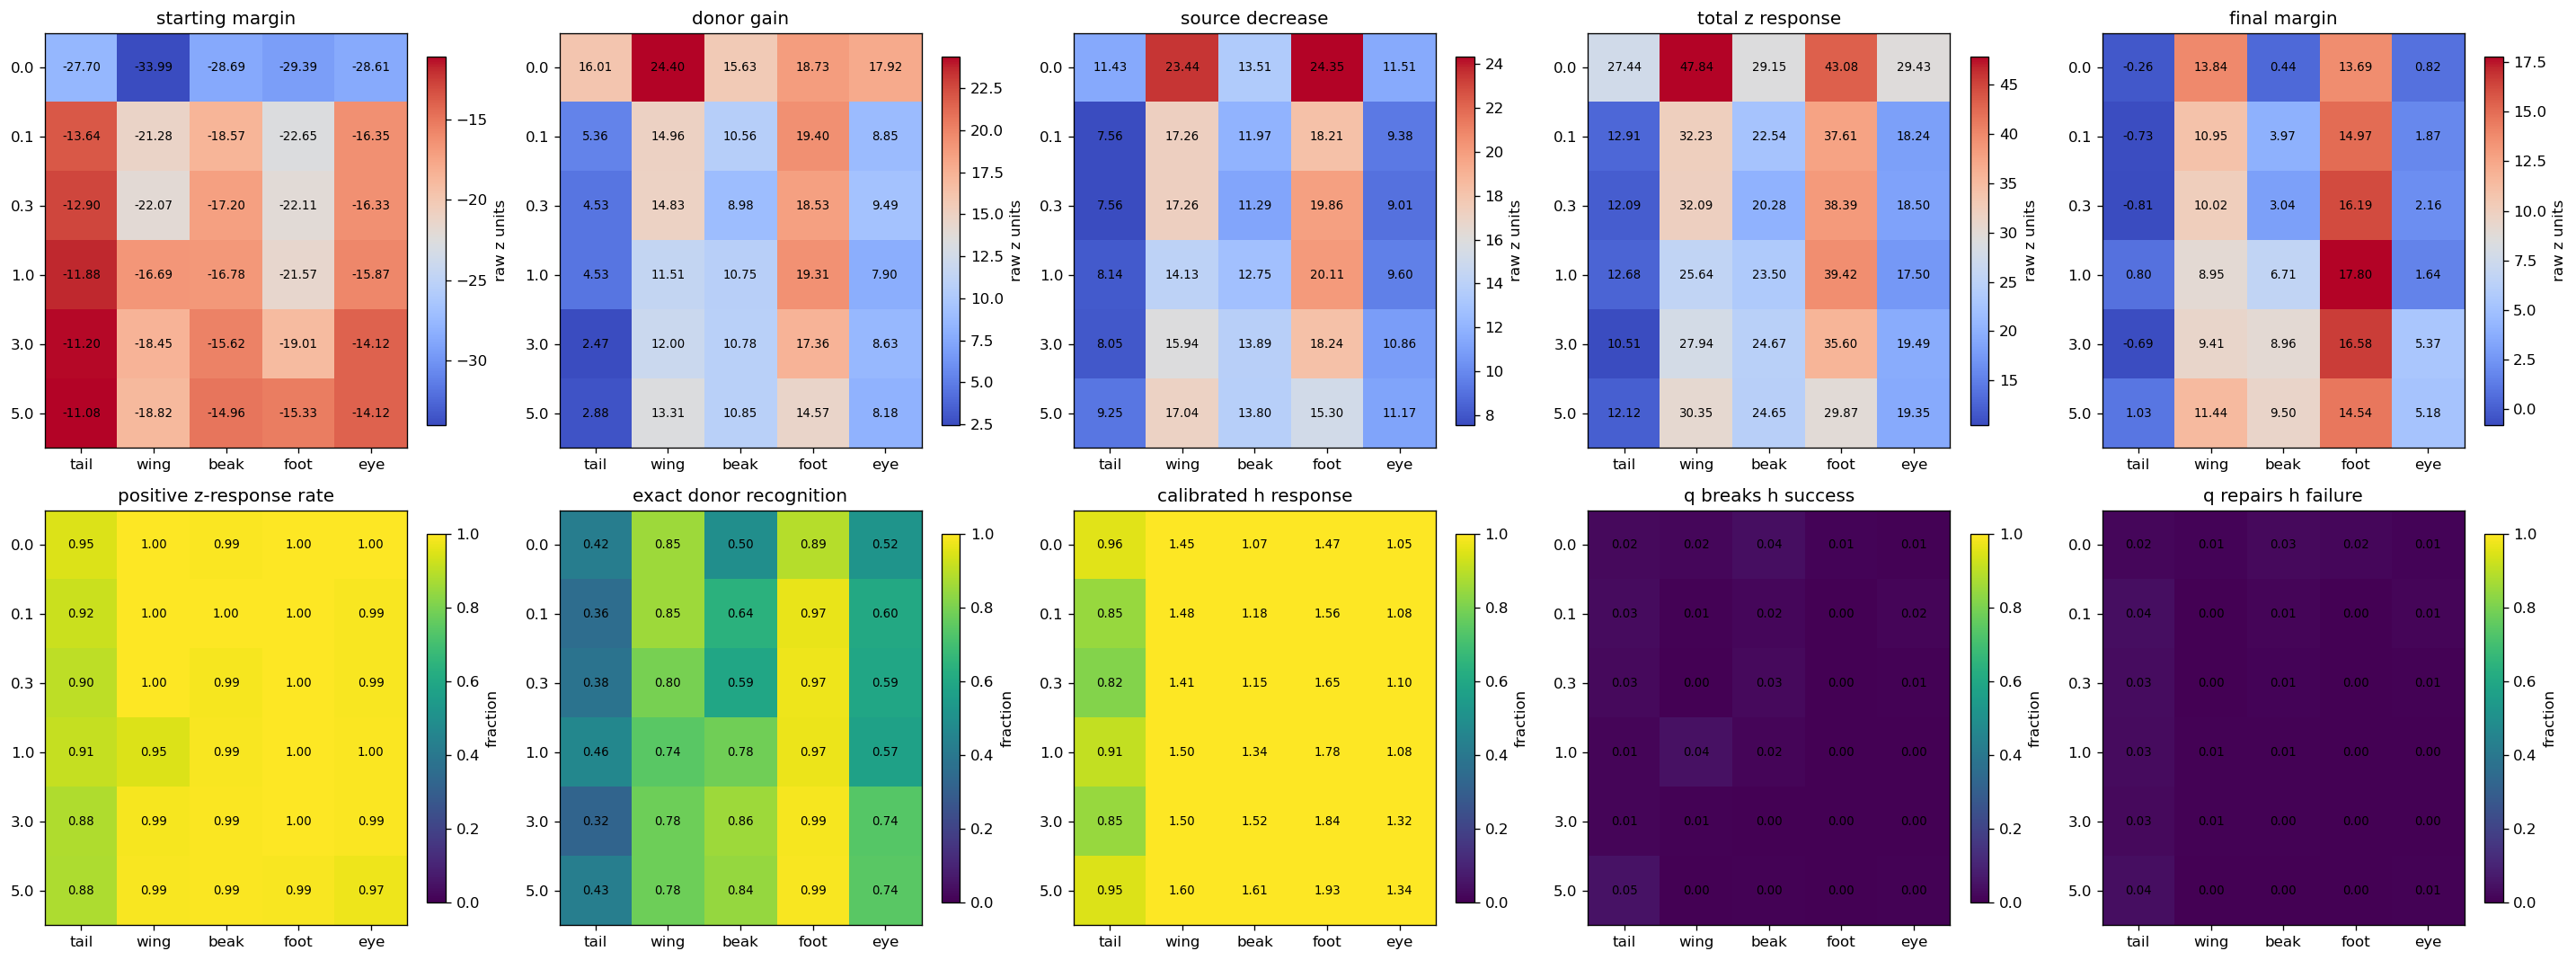

**Table — swap pathway values behind the ten panels.** `mean_z_*` columns are in final raw-logit units. `mean_calibrated_h_response` is in absent-to-present internal units: +1 means the internal donor/source contrast moved by one ordinary-label separation. The two `q_*` columns are fractions of all swaps.

,gamma,part,mean_z_original_margin,mean_z_donor_gain,mean_z_source_decrease,mean_z_response,mean_z_final_margin,z_response_positive_rate,z_exact_donor_recognition,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate
0,0.0,beak,-28.6946,15.6311,13.5147,29.1458,0.4433,0.9950,0.4955,1.0651,0.0390,0.0260
1,0.0,eye,-28.6132,17.9223,11.5110,29.4333,0.8212,0.9970,0.5160,1.0497,0.0070,0.0110
2,0.0,foot,-29.3906,18.7268,24.3545,43.0813,13.6922,0.9970,0.8900,1.4740,0.0110,0.0160
3,0.0,tail,-27.6986,16.0070,11.4319,27.4389,-0.2607,0.9470,0.4250,0.9555,0.0240,0.0190
4,0.0,wing,-33.9943,24.3969,23.4429,47.8398,13.8443,1.0000,0.8530,1.4468,0.0160,0.0100
5,0.1,beak,-18.5713,10.5625,11.9747,22.5372,3.9670,0.9990,0.6390,1.1839,0.0180,0.0120
6,0.1,eye,-16.3490,8.8543,9.3846,18.2389,1.8709,0.9910,0.6030,1.0817,0.0151,0.0131
7,0.1,foot,-22.6469,19.4011,18.2134,37.6145,14.9687,0.9970,0.9670,1.5611,0.0000,0.0000
8,0.1,tail,-13.6431,5.3566,7.5581,12.9147,-0.7275,0.9190,0.3560,0.8474,0.0290,0.0370
9,0.1,wing,-21.2801,14.9627,17.2626,32.2253,10.9460,1.0000,0.8549,1.4845,0.0070,0.0020


**Table — ordinary source-image species health for the matched replay population.** This checks that pathway comparisons are not artifacts of a different set of original images. Accuracy is a 0–1 fraction; `n_originals` is its denominator.

,gamma,n_images,species_accuracy,mean_true_species_probability
0,0.0,250,0.992,0.9910
1,0.1,250,0.988,0.9878
2,0.3,250,0.996,0.9917
3,1.0,250,0.996,0.9897
4,3.0,250,0.996,0.9904
5,5.0,250,0.980,0.9771


In [12]:
strict=P_SUM[P_SUM.population.eq('strict matched replay')].copy()
margins=[]
for g,d in MCBM.items():
    for part,q in d.groupby('part'):
        margins.append(dict(gamma=g,part=part,mean_z_original_margin=q.m_orig.mean(),mean_z_final_margin=q.m_cf.mean()))
strict=strict.merge(pd.DataFrame(margins),on=['gamma','part'],how='left',validate='one_to_one')
metrics=[('mean_z_original_margin','starting margin'),('mean_z_donor_gain','donor gain'),
  ('mean_z_source_decrease','source decrease'),('mean_z_response','total z response'),
  ('mean_z_final_margin','final margin'),('z_response_positive_rate','positive z-response rate'),
  ('z_exact_donor_recognition','exact donor recognition'),('mean_calibrated_h_response','calibrated h response'),
  ('q_breaks_h_success_rate','q breaks h success'),('q_repairs_h_failure_rate','q repairs h failure')]
fig,axes=plt.subplots(2,5,figsize=(24,9))
for ax,(col,title) in zip(axes.flat,metrics):
    table=strict.pivot(index='gamma',columns='part',values=col).reindex(index=GAMMAS,columns=ORDER)
    rate=('rate' in col or 'recognition' in col)
    heat(ax,table,title,'fraction' if rate else ('calibrated h units' if 'h_response' in col else 'raw z units'),0 if rate else None,1 if rate else None,'viridis' if rate else 'coolwarm')
plt.tight_layout(); plt.show()
show_table(
  'swap pathway values behind the ten panels',
  '`mean_z_*` columns are in final raw-logit units. '
  '`mean_calibrated_h_response` is in absent-to-present internal units: +1 means '
  'the internal donor/source contrast moved by one ordinary-label separation. '
  'The two `q_*` columns are fractions of all swaps.',
  strict[['gamma','part']+[x[0] for x in metrics]].round(4))
show_table(
  'ordinary source-image species health for the matched replay population',
  'This checks that pathway comparisons are not artifacts of a different set of '
  'original images. Accuracy is a 0–1 fraction; `n_originals` is its denominator.',
  MATCHED_HEALTH.round(4))


**How to read the executed RLv2 result.** The figure and fully
captioned source table immediately above are the result; no expected
observation was written into the notebook before execution.

**Question → test → boundary.** Compare the RLv2 output with the
executed Standard-MCBM output directly above it. A change is evidence
about visibility-aware labels only when model gamma, formula, physical
swap rows, and denominator match. It does not turn an association into
a cause, and seed 1 does not provide initialization uncertainty.

**Next question.** Continue to the next identical analysis stage, then
use the final matched-difference table to decide which part and pathway
actually changed.


## 4. Transition B — MCBM gamma 0 to positive gamma

Now architecture and stored recipe are nominally shared, and gamma controls
the added squared-error pressure toward `h=-3/+3`. Initialization was not
seeded in these historical runs, so non-monotonic differences can still be
run-to-run variation. A smooth dose trend is more persuasive than one jump.

**Question.** Does stronger compression improve inserted-pixel response, or
merely make ordinary `h` values more label-like?

**Prediction.** If the loss removes harmful within-label context while
preserving pixel response, target RMSE and within-label spread should fall
while donor gain and exact donor recognition rise. If response falls while
target RMSE improves, the loss is compressing information useful for the
controlled intervention, or consolidating a contextual shortcut.


In [13]:
show_standard_mcbm('loss-gradients')


### Executed Standard-MCBM result — loss-gradients

**Stored frozen-gradient diagnostic** — magnitudes compare terms within this implementation; they are not a Koh-versus-MCBM loss-ratio claim.

**Table — frozen loss-gradient magnitudes.** Every row is one gamma/part at the saved checkpoint. RMS columns measure the size of each weighted loss gradient with respect to `h`; cosine columns measure whether task and concept gradients point together. These are checkpoint diagnostics, not training-history averages.

,gamma,part,N,coordinates,task_gradient_RMS,concept_gradient_RMS,weighted_compression_gradient_RMS,task_concept_cosine_mean,task_concept_opposed_fraction,cosine_eligible_images
0,0.0,beak,5000,4,0.02547,0.15785,0.00000,0.08419,0.42837,2883
1,0.0,eye,5000,3,0.04857,0.20346,0.00000,0.17882,0.36447,2955
2,0.0,foot,5000,4,0.02317,0.09116,0.00000,-0.02962,0.52939,2586
3,0.0,tail,5000,9,0.02863,0.27810,0.00000,0.22719,0.30861,2764
4,0.0,wing,5000,6,0.02406,0.10421,0.00000,0.03963,0.47952,2857
5,0.1,beak,5000,4,0.04308,0.57842,0.02460,0.17719,0.37172,4837
6,0.1,eye,5000,3,0.04899,0.29755,0.02788,0.25788,0.31862,4802
7,0.1,foot,5000,4,0.04696,0.31712,0.02160,-0.00470,0.53629,4781
8,0.1,tail,5000,9,0.07082,1.31414,0.05867,0.30754,0.23893,4855
9,0.1,wing,5000,6,0.04352,0.63975,0.08278,0.11390,0.43268,4835


**Literal result.** At gamma 5, the final-checkpoint compression-to-concept gradient ratios are `tail=0.88`, `wing=0.60`, `beak=0.97`, `foot=1.02`, `eye=2.20`. Compression is therefore comparable to the concept gradient for tail, beak, foot, and eye, and smaller for wing. This is a final-checkpoint pressure audit, not a movie of the optimization path and not proof that the compression term caused any one swap outcome.

In [14]:
gradient_path=TABLES/'loss_gradients.csv'
if gradient_path.is_file():
    GRAD=pd.read_csv(gradient_path)
    display(Markdown('**Stored frozen-gradient diagnostic** — magnitudes compare terms within this implementation; they are not a Koh-versus-MCBM loss-ratio claim.'))
    show_table(
      'frozen loss-gradient magnitudes',
      'Every row is one gamma/part at the saved checkpoint. RMS columns measure '
      'the size of each weighted loss gradient with respect to `h`; cosine columns '
      'measure whether task and concept gradients point together. These are '
      'checkpoint diagnostics, not training-history averages.', GRAD.round(5))
    g5=GRAD[GRAD.gamma.eq(5)].set_index('part')
    ratio=(g5.weighted_compression_gradient_RMS/g5.concept_gradient_RMS).reindex(ORDER)
    display(Markdown('**Literal result.** At gamma 5, the final-checkpoint compression-to-concept gradient ratios are '+
      ', '.join(f'`{part}={ratio[part]:.2f}`' for part in ORDER)+
      '. Compression is therefore comparable to the concept gradient for tail, beak, foot, and eye, and smaller for wing. This is a final-checkpoint pressure audit, not a movie of the optimization path and not proof that the compression term caused any one swap outcome.'))
else:
    print('No loss_gradients.csv: gradient-magnitude appendix unavailable; outcome/pathway analyses remain valid.')


**Stored frozen-gradient diagnostic** — magnitudes compare terms within this implementation; they are not a Koh-versus-MCBM loss-ratio claim.

**Table — frozen loss-gradient magnitudes.** Every row is one gamma/part at the saved checkpoint. RMS columns measure the size of each weighted loss gradient with respect to `h`; cosine columns measure whether task and concept gradients point together. These are checkpoint diagnostics, not training-history averages.

,gamma,part,N,coordinates,task_gradient_RMS,concept_gradient_RMS,weighted_compression_gradient_RMS,task_concept_cosine_mean,task_concept_opposed_fraction,cosine_eligible_images
0,0.0,beak,5000,4,0.01500,0.15459,0.00000,0.13339,0.39793,2704
1,0.0,eye,5000,3,0.01768,0.08114,0.00000,0.17032,0.39323,2599
2,0.0,foot,5000,4,0.02048,0.04683,0.00000,0.13214,0.39951,2468
3,0.0,tail,5000,9,0.01561,0.18085,0.00000,0.09731,0.45534,2978
4,0.0,wing,5000,6,0.01465,0.11494,0.00000,0.06115,0.47118,2602
5,0.1,beak,5000,4,0.05702,0.76101,0.02067,0.22396,0.35218,4793
6,0.1,eye,5000,3,0.05338,0.32343,0.02400,0.23303,0.32869,4807
7,0.1,foot,5000,4,0.04382,0.47772,0.01731,0.05451,0.49556,4730
8,0.1,tail,5000,9,0.04786,0.73229,0.02801,0.21396,0.37521,4816
9,0.1,wing,5000,6,0.05228,0.64386,0.08121,0.10544,0.46021,4800


**Literal result.** At gamma 5, the final-checkpoint compression-to-concept gradient ratios are `tail=0.60`, `wing=0.56`, `beak=1.33`, `foot=1.24`, `eye=2.21`. Compression is therefore comparable to the concept gradient for tail, beak, foot, and eye, and smaller for wing. This is a final-checkpoint pressure audit, not a movie of the optimization path and not proof that the compression term caused any one swap outcome.

### Direction, visibility, label conflict, and exact values

These are candidate contributors, not interchangeable explanations.
Direction asks whether forward/backward swaps differ. Visibility is the
corrected total mask area of the inserted bilateral part. Conflict rate is a
data rate: among positive training labels for an exact value, the fraction
whose named region is hidden. Support is the number of 50 species naturally
carrying that exact value.

The exact Standard figures follow first. Shared label/mask and value-gallery
figures appear once because their inputs do not depend on the model.


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f9-`**

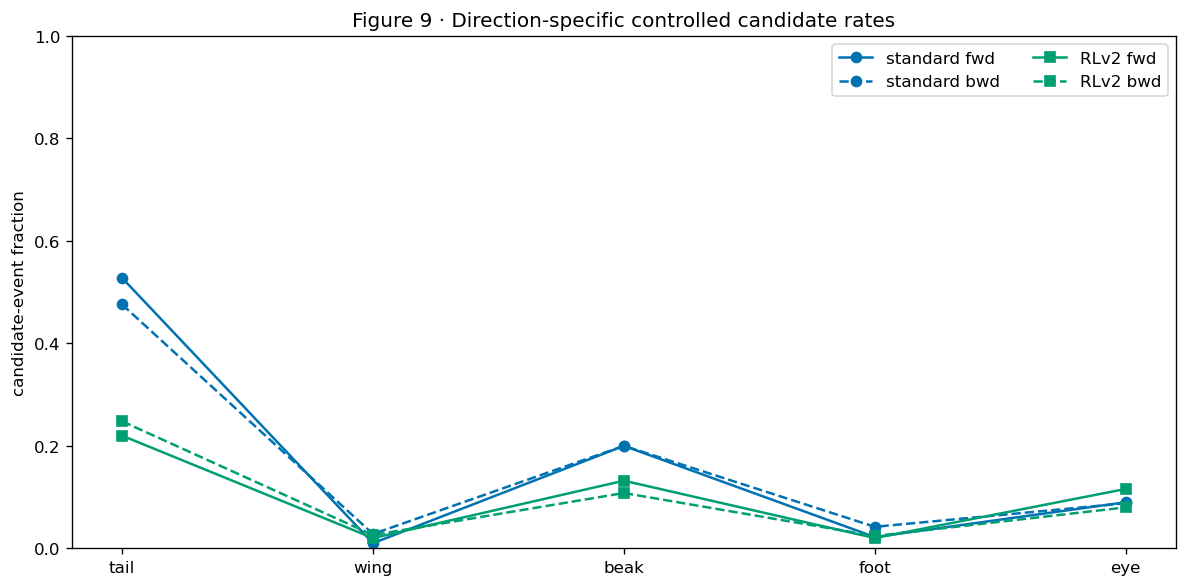

,part,direction,n,standard,RLv2
0,beak,bwd,500,0.200,0.108
1,beak,fwd,500,0.200,0.132
2,eye,bwd,500,0.088,0.080
3,eye,fwd,500,0.090,0.116
4,foot,bwd,500,0.042,0.024
5,foot,fwd,500,0.022,0.020
6,tail,bwd,500,0.476,0.248
7,tail,fwd,500,0.528,0.220
8,wing,bwd,500,0.028,0.026
9,wing,fwd,500,0.010,0.020


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f10-`**

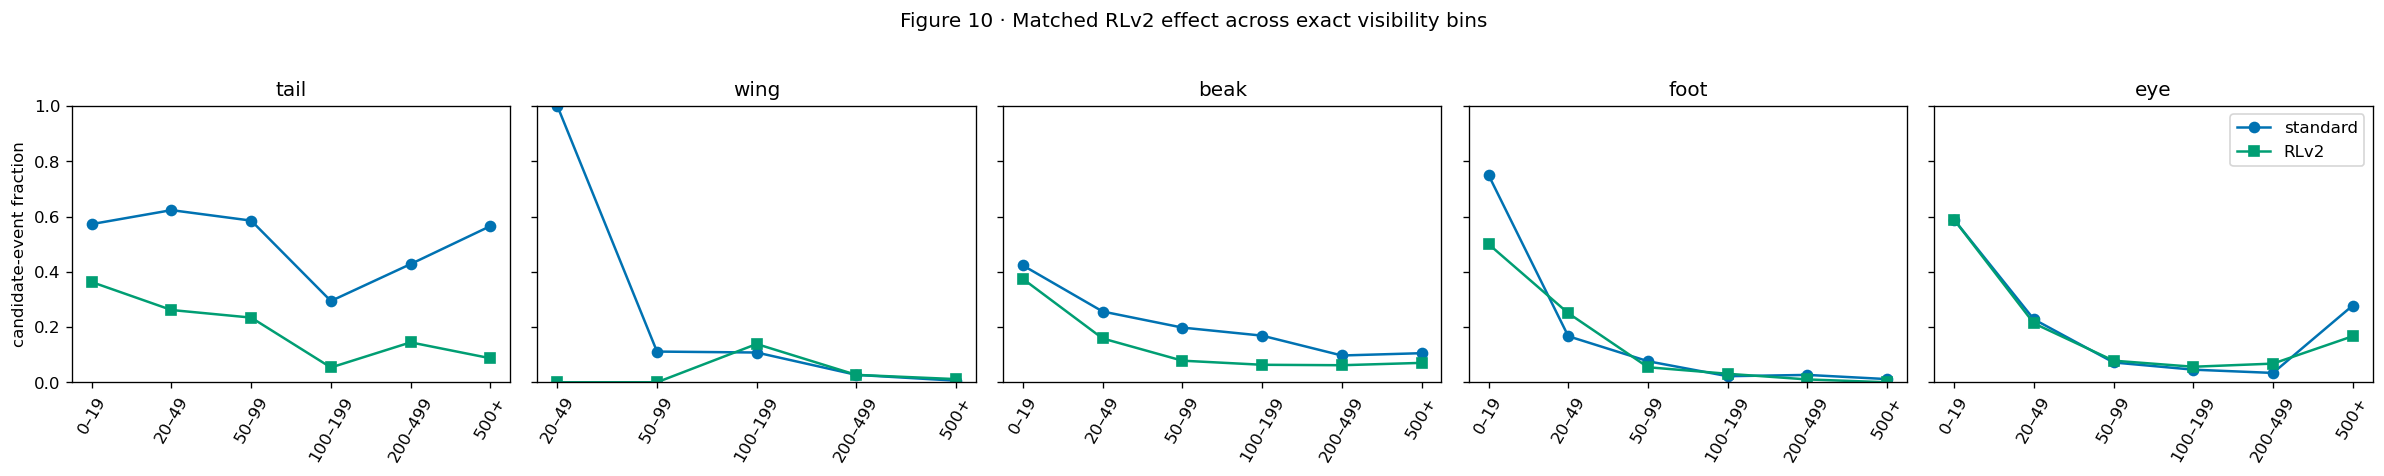

,part,visibility_bin,n,standard,RLv2
0,beak,0–19,123,0.423,0.374
1,beak,20–49,164,0.256,0.159
2,beak,50–99,192,0.198,0.078
3,beak,100–199,237,0.169,0.063
4,beak,200–499,227,0.097,0.062
5,beak,500+,57,0.105,0.070
6,eye,0–19,17,0.588,0.588
7,eye,20–49,136,0.228,0.213
8,eye,50–99,307,0.072,0.078
9,eye,100–199,285,0.046,0.056


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f13a-`**

STANDARD — same calculation


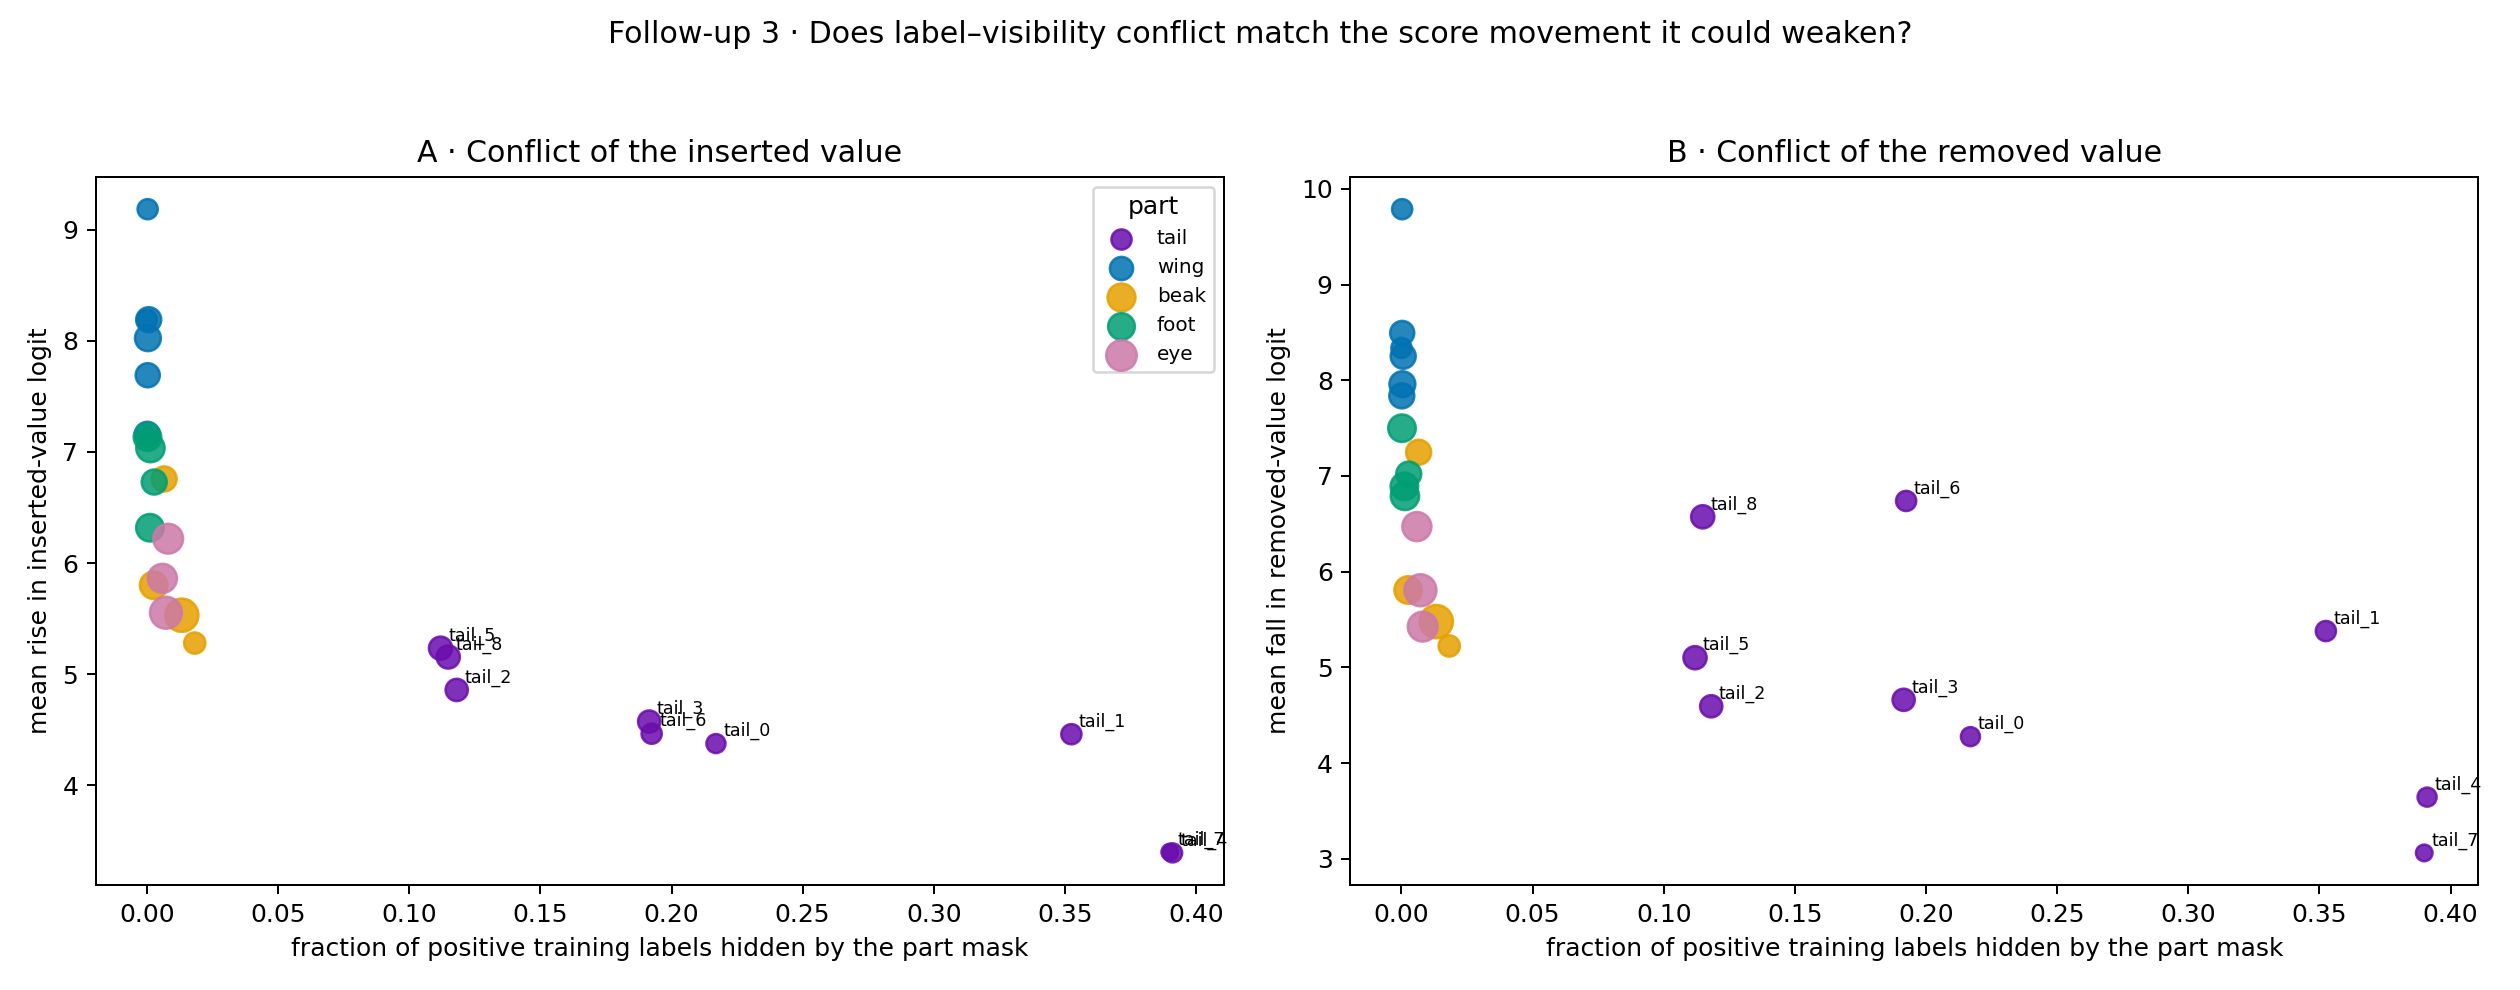

,concept_index,concept,part,value,positive_images,hidden_positive_images,conflict_rate,species_support,mean_donor_gain,mean_visible_pixels,donor_rows,mean_source_decrease,source_rows
0,0,beak_0,beak,0,15819,210,0.0133,21,5.5298,99.5449,345,5.4785,345
1,1,beak_1,beak,1,7476,49,0.0066,10,6.7573,316.1306,245,7.2481,245
2,2,beak_2,beak,2,4555,83,0.0182,6,5.2791,22.0526,190,5.2235,190
3,3,beak_3,beak,3,9767,25,0.0026,13,5.7998,207.3773,220,5.8082,220
4,4,eye_0,eye,0,11384,67,0.0059,15,5.8616,67.2067,300,6.4712,300
5,5,eye_1,eye,1,11994,97,0.0081,16,6.2189,79.2928,345,5.4257,345
6,6,eye_2,eye,2,14348,104,0.0072,19,5.5520,70.2620,355,5.8059,355
7,7,foot_0,foot,0,9829,2,0.0002,13,7.1338,192.7364,220,7.4994,220
8,8,foot_1,foot,1,7584,21,0.0028,10,6.7294,97.8042,240,7.0198,240
9,9,foot_2,foot,2,10552,14,0.0013,14,7.0352,169.1552,290,6.7916,290


RLV2 — same calculation


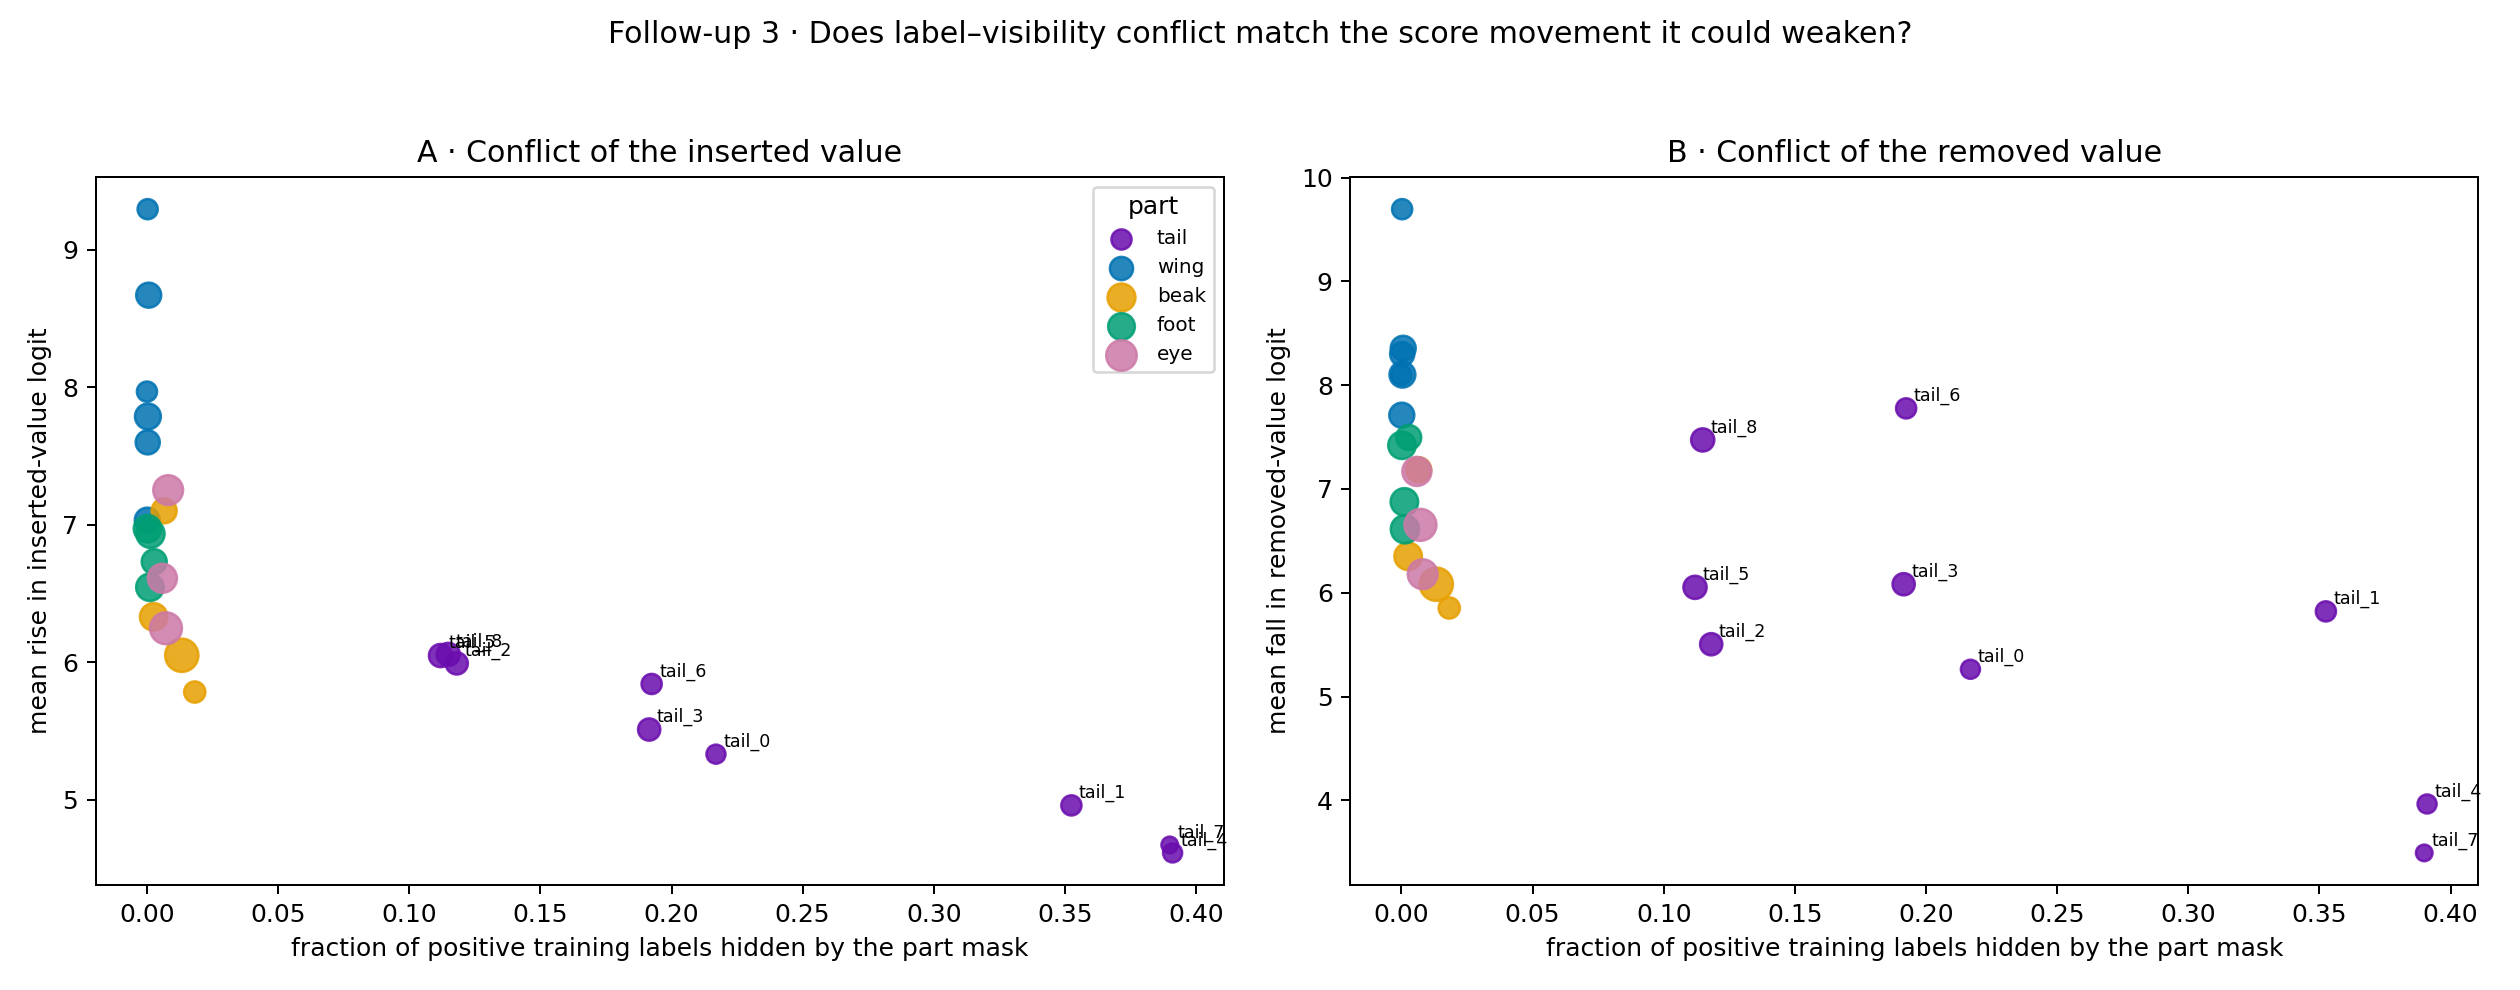

,concept_index,concept,part,value,positive_images,hidden_positive_images,conflict_rate,species_support,mean_donor_gain,mean_visible_pixels,donor_rows,mean_source_decrease,source_rows
0,0,beak_0,beak,0,15819,210,0.0133,21,6.0504,99.5449,345,6.0819,345
1,1,beak_1,beak,1,7476,49,0.0066,10,7.1006,316.1306,245,7.1848,245
2,2,beak_2,beak,2,4555,83,0.0182,6,5.7832,22.0526,190,5.8530,190
3,3,beak_3,beak,3,9767,25,0.0026,13,6.3298,207.3773,220,6.3509,220
4,4,eye_0,eye,0,11384,67,0.0059,15,6.6102,67.2067,300,7.1691,300
5,5,eye_1,eye,1,11994,97,0.0081,16,7.2513,79.2928,345,6.1787,345
6,6,eye_2,eye,2,14348,104,0.0072,19,6.2466,70.2620,355,6.6541,355
7,7,foot_0,foot,0,9829,2,0.0002,13,6.9710,192.7364,220,7.4208,220
8,8,foot_1,foot,1,7584,21,0.0028,10,6.7307,97.8042,240,7.4960,240
9,9,foot_2,foot,2,10552,14,0.0013,14,6.9339,169.1552,290,6.6120,290


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f11-`**

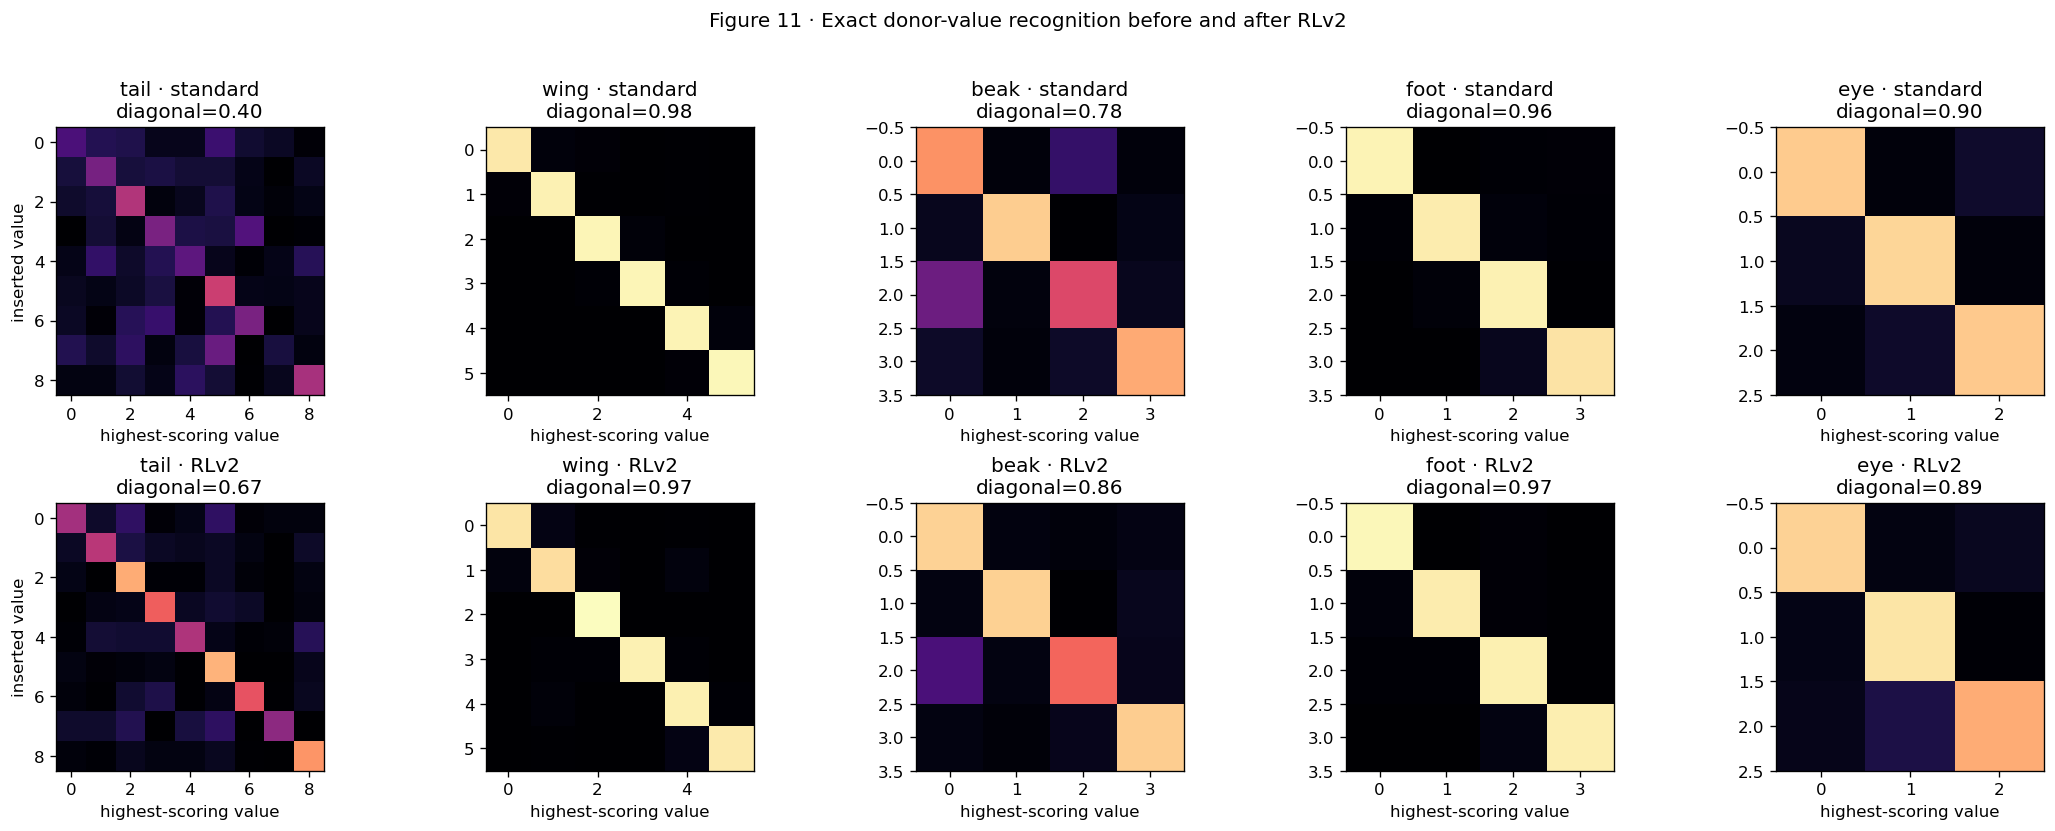

,regime,part,donor_value,n,recognition_rate,candidate_rate
0,standard,tail,0,75,0.240,0.640
1,standard,tail,1,90,0.344,0.533
2,standard,tail,2,120,0.492,0.408
3,standard,tail,3,110,0.355,0.573
4,standard,tail,4,110,0.282,0.518
5,standard,tail,5,150,0.553,0.373
6,standard,tail,6,130,0.354,0.515
7,standard,tail,7,35,0.114,0.800
8,standard,tail,8,180,0.467,0.478
9,standard,wing,0,130,0.954,0.031


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f13b-`**

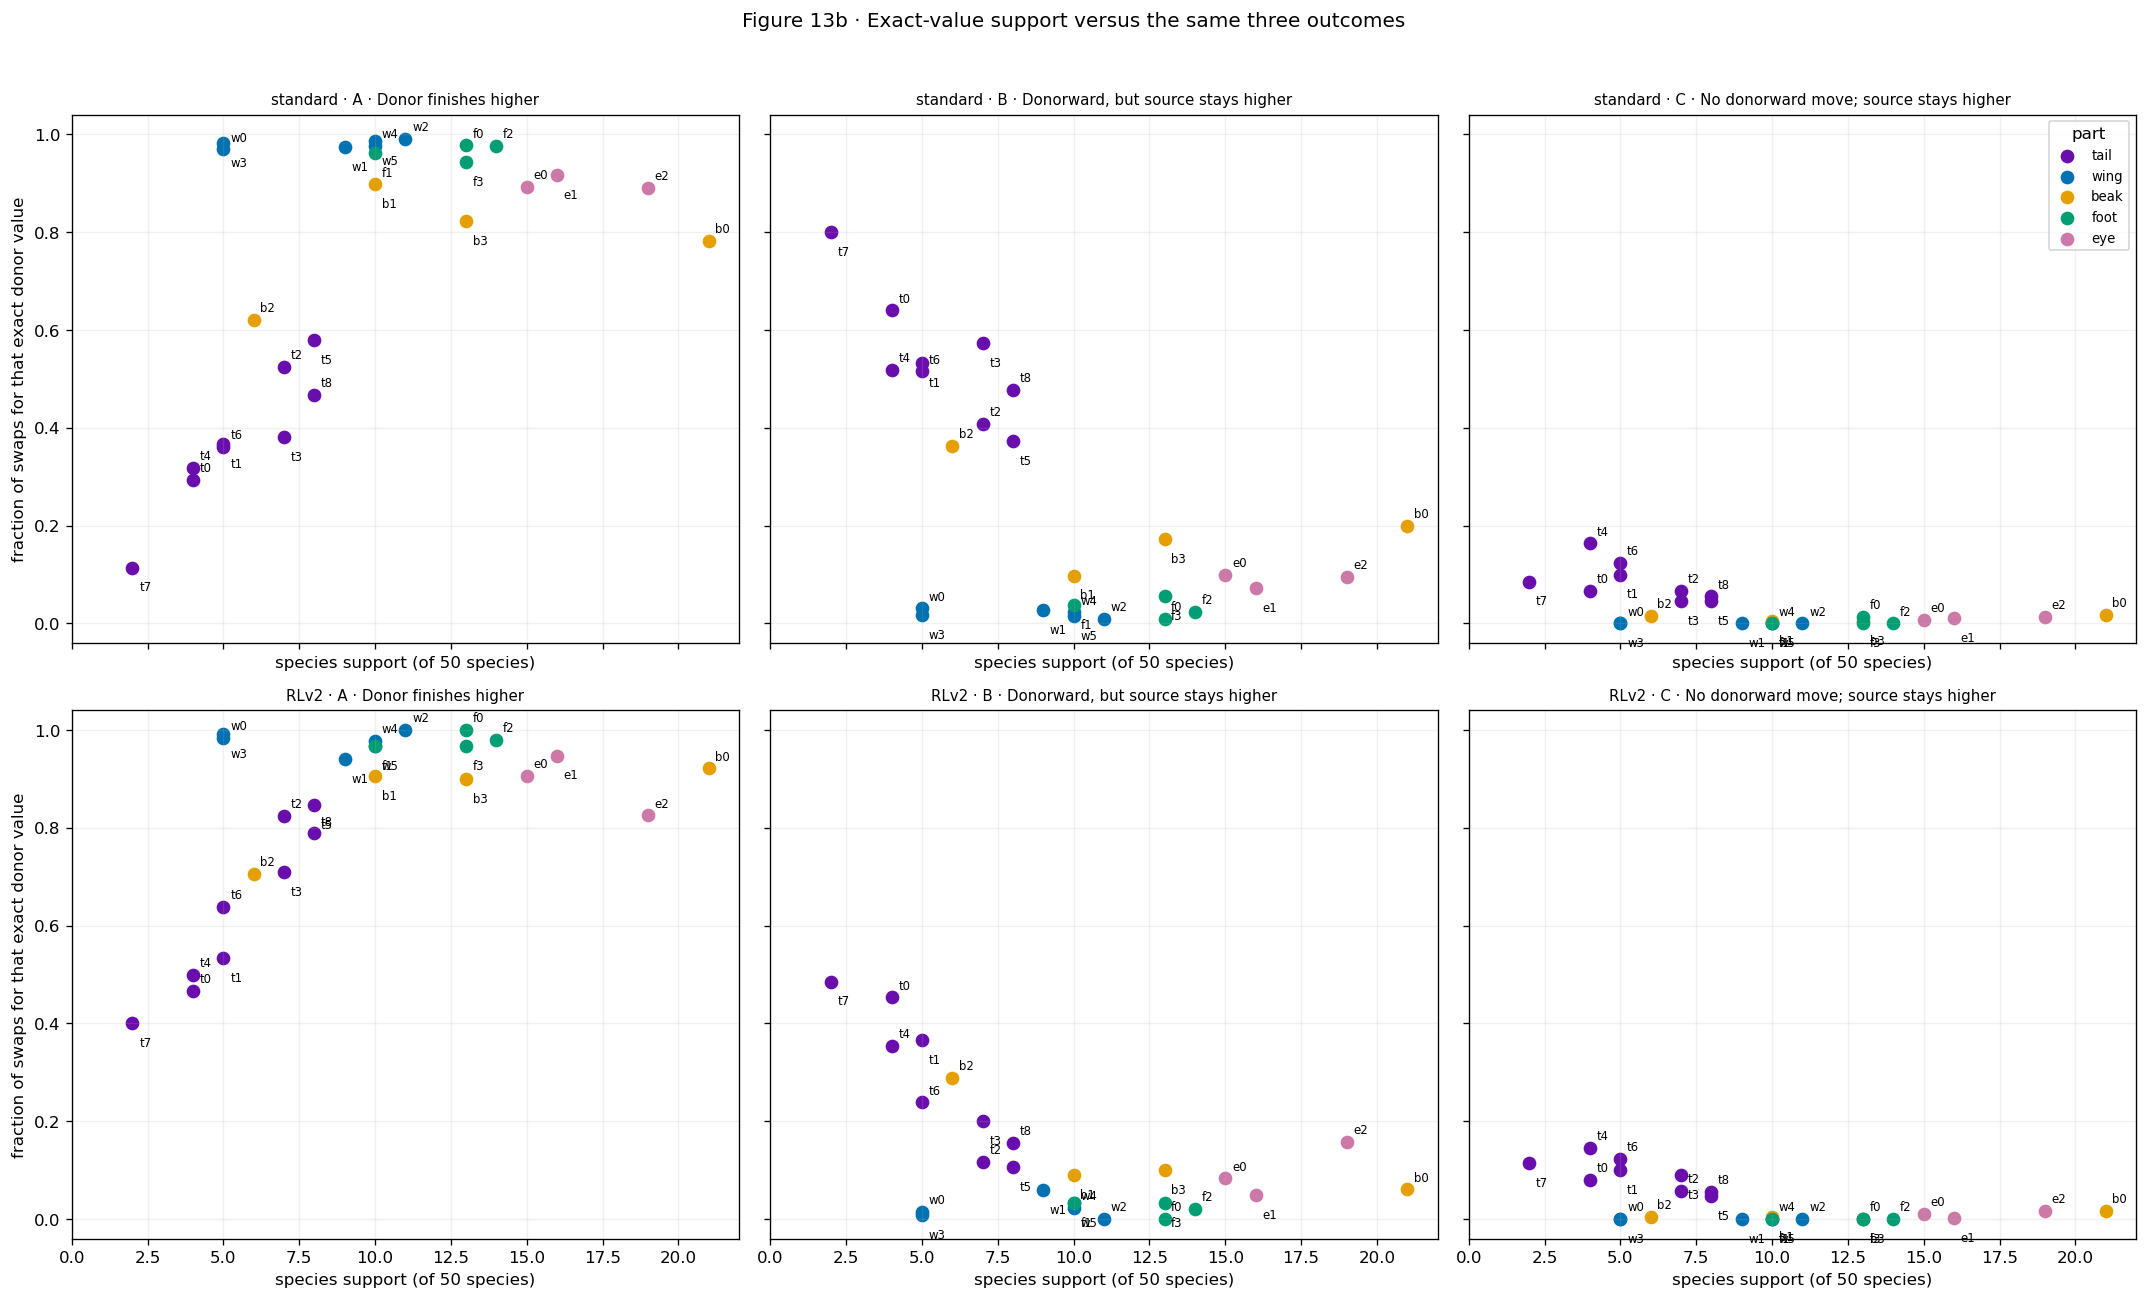

,part,var_donor,n_rows,species_support,donor_wins_rate,donorward_source_wins_rate,no_donorward_source_wins_rate,regime
0,beak,0,345,21,0.783,0.200,0.017,standard
1,beak,1,245,10,0.898,0.098,0.004,standard
2,beak,2,190,6,0.621,0.363,0.016,standard
3,beak,3,220,13,0.823,0.173,0.005,standard
4,eye,0,300,15,0.893,0.100,0.007,standard
5,eye,1,345,16,0.916,0.072,0.012,standard
6,eye,2,355,19,0.890,0.096,0.014,standard
7,foot,0,220,13,0.977,0.009,0.014,standard
8,foot,1,240,10,0.962,0.038,0.000,standard
9,foot,2,290,14,0.976,0.024,0.000,standard


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f13c-`**

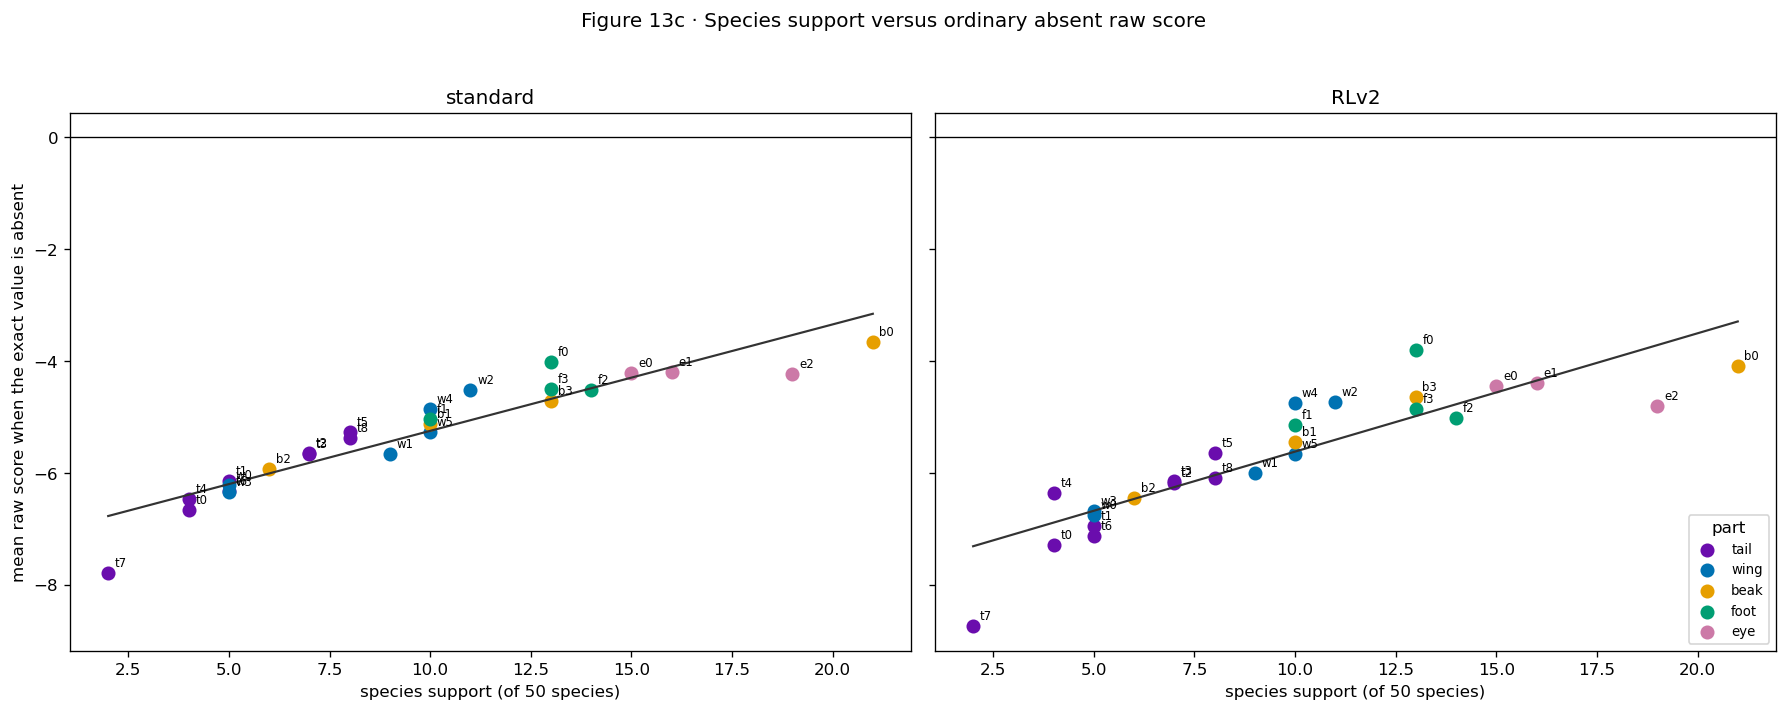

,regime,part,concept,value,species_support,N_absent,absent_mean,absent_SD
0,standard,beak,beak_0,0,21,290,-3.652,0.831
1,standard,beak,beak_1,1,10,400,-5.119,1.026
2,standard,beak,beak_2,2,6,440,-5.939,1.201
3,standard,beak,beak_3,3,13,370,-4.720,0.993
4,standard,eye,eye_0,0,15,350,-4.209,1.061
5,standard,eye,eye_1,1,16,340,-4.189,0.826
6,standard,eye,eye_2,2,19,310,-4.239,1.056
7,standard,foot,foot_0,0,13,370,-4.025,0.884
8,standard,foot,foot_1,1,10,400,-5.043,0.844
9,standard,foot,foot_2,2,14,360,-4.513,0.861


In [15]:
show_standard('f5','f6','f6b','f6c','f7','f7a','f7b','f7c')


### MCBM per-value audit

Every row below is one donor value at one gamma. It reports its row count,
original-image count, support, label/mask conflict, corrected visible pixels,
donor gain, source decrease, total response, final margin, and exact outcome.
This is the correct level for questions such as “why did foot improve while
wing worsened?”: a part average cannot reveal whether one value dominates.

The heatmaps summarize values within each part only after the full table is
printed. No causal model is fitted.


### Executed Standard-MCBM result — values

**Table — complete donor-value audit before averaging by part.** One row is one gamma, part, and inserted exact value. Counts state the denominators. Pixel area, label/mask conflict, species support, donor gain, source decrease, final margin, and exact recognition are kept separate so a part mean cannot hide a difficult value.

,gamma,part,donor_value,n_rows,n_originals,donor_species_support,donor_positive_training_records,donor_conflict_rate,mean_corrected_visible_pixels,mean_z_original_margin,mean_z_donor_gain,mean_z_source_decrease,mean_z_response,median_z_final_margin,no_donorward_movement_rate,responded_but_source_above_donor_rate,exact_donor_recognition,exact_source_winner_rate,exact_third_winner_rate,h_exact_valid_rate,h_calibrated_exact_donor_recognition
0,0.0,beak,3,220,135,13,9767,0.0026,207.3773,-25.8294,11.9193,15.0781,26.9975,-1.1313,0.0273,0.5409,0.4136,0.5091,0.0773,1.0,0.7091
1,0.0,beak,0,345,120,21,15819,0.0133,99.5449,-32.6196,18.3194,14.4421,32.7615,-0.1666,0.0000,0.5159,0.4522,0.5072,0.0406,1.0,0.5246
2,0.0,beak,2,190,125,6,4555,0.0182,22.0526,-16.2412,9.0811,10.4350,19.5160,2.0059,0.0211,0.4474,0.5105,0.4526,0.0368,1.0,0.4526
3,0.0,beak,1,245,145,10,7476,0.0066,316.1306,-25.5281,20.3876,16.4192,36.8067,9.7463,0.0041,0.1347,0.8408,0.1306,0.0286,1.0,0.5755
4,0.0,eye,2,355,150,19,14348,0.0072,137.9887,-27.8271,14.1224,12.0004,26.1228,-1.0347,0.0141,0.5577,0.4282,0.5718,0.0000,1.0,0.4845
5,0.0,eye,0,300,160,15,11384,0.0059,136.0067,-30.9679,12.9614,9.8902,22.8516,-8.0416,0.0033,0.7800,0.2033,0.7567,0.0400,1.0,0.3367
6,0.0,eye,1,345,155,16,11994,0.0081,159.9391,-24.7329,19.2999,13.9284,33.2282,9.0024,0.0029,0.1768,0.8174,0.1710,0.0116,1.0,0.6725
7,0.0,foot,0,220,145,13,9829,0.0002,389.4409,-29.0482,24.5792,21.9282,46.5074,18.4176,0.0000,0.0273,0.9727,0.0182,0.0091,1.0,0.9500
8,0.0,foot,2,290,155,14,10552,0.0013,351.6241,-35.7251,23.0633,23.9659,47.0292,14.2060,0.0000,0.0655,0.9345,0.0655,0.0000,1.0,0.9621
9,0.0,foot,1,240,160,10,7584,0.0028,208.2625,-20.4365,14.8511,18.9911,33.8422,13.1422,0.0000,0.0708,0.9292,0.0708,0.0000,1.0,0.9167


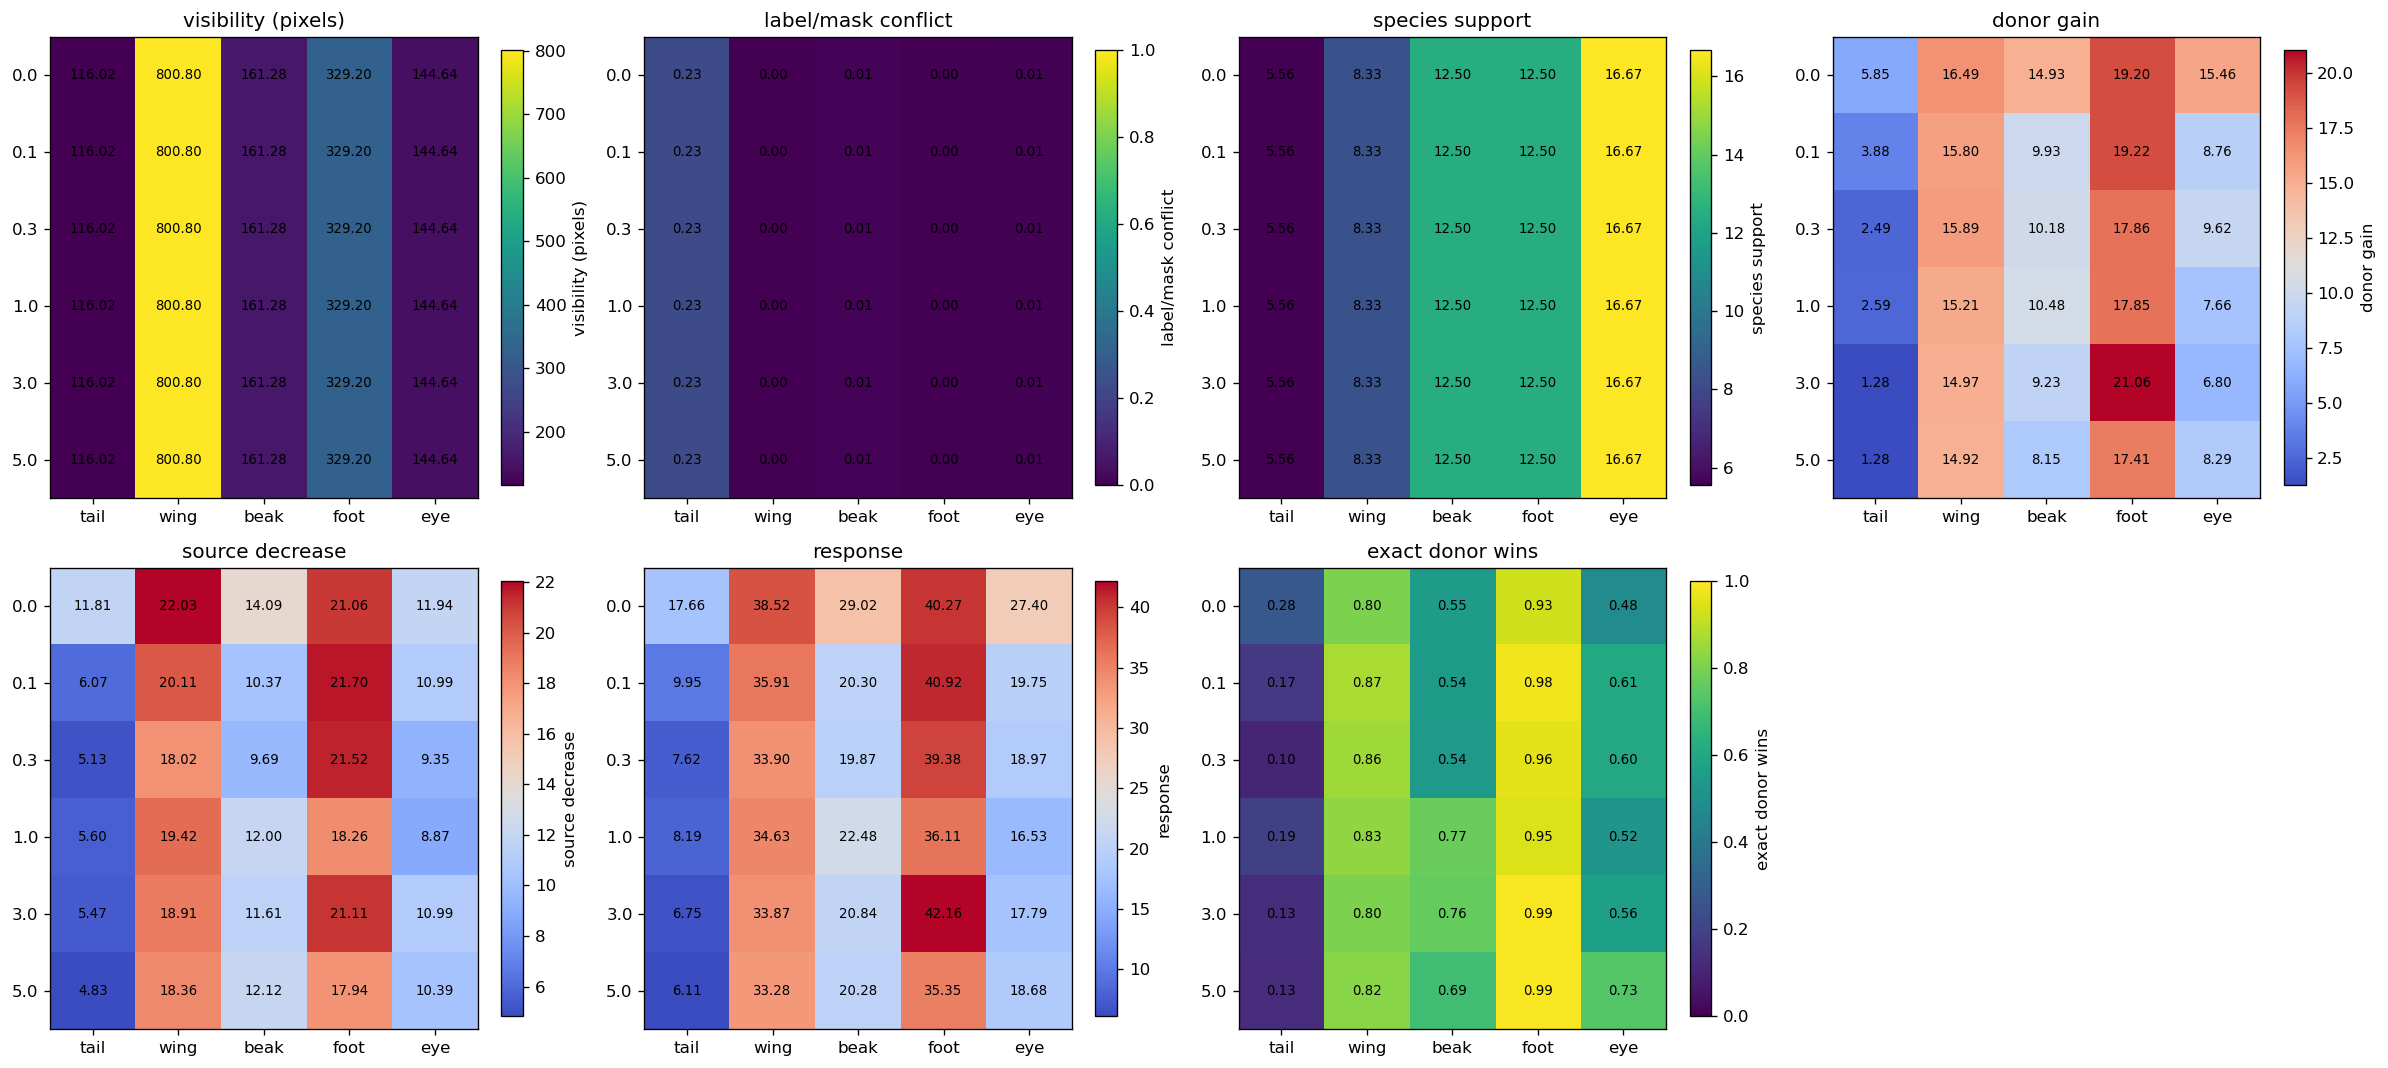

**Table — part means plotted in the seven heatmaps.** These are unweighted means over exact donor values within a part, not over all swap rows. Visibility, conflict, and support repeat across gamma because the physical data are unchanged; response columns come from each model.

,gamma,part,mean_corrected_visible_pixels,donor_conflict_rate,donor_species_support,mean_z_donor_gain,mean_z_source_decrease,mean_z_response,exact_donor_recognition
0,0.0,beak,161.2764,0.0102,12.5000,14.9268,14.0936,29.0204,0.5543
1,0.0,eye,144.6448,0.0071,16.6667,15.4612,11.9397,27.4009,0.4830
2,0.0,foot,329.2049,0.0014,12.5000,19.2048,21.0618,40.2666,0.9271
3,0.0,tail,116.0159,0.2310,5.5556,5.8542,11.8079,17.6621,0.2773
4,0.0,wing,800.8017,0.0003,8.3333,16.4857,22.0318,38.5175,0.8039
5,0.1,beak,161.2764,0.0102,12.5000,9.9321,10.3717,20.3038,0.5431
6,0.1,eye,144.6448,0.0071,16.6667,8.7618,10.9921,19.7538,0.6066
7,0.1,foot,329.2049,0.0014,12.5000,19.2181,21.7041,40.9222,0.9782
8,0.1,tail,116.0159,0.2310,5.5556,3.8786,6.0715,9.9501,0.1670
9,0.1,wing,800.8017,0.0003,8.3333,15.7961,20.1114,35.9074,0.8718


In [16]:
show_standard_mcbm('values')


**Table — complete donor-value audit before averaging by part.** One row is one gamma, part, and inserted exact value. Counts state the denominators. Pixel area, label/mask conflict, species support, donor gain, source decrease, final margin, and exact recognition are kept separate so a part mean cannot hide a difficult value.

,gamma,part,donor_value,n_rows,n_originals,donor_species_support,donor_positive_training_records,donor_conflict_rate,mean_corrected_visible_pixels,mean_z_original_margin,mean_z_donor_gain,mean_z_source_decrease,mean_z_response,median_z_final_margin,no_donorward_movement_rate,responded_but_source_above_donor_rate,exact_donor_recognition,exact_source_winner_rate,exact_third_winner_rate,h_exact_valid_rate,h_calibrated_exact_donor_recognition
0,0.0,beak,3,220,135,13,9767,0.0026,207.3773,-19.3905,8.4246,13.4527,21.8773,0.5835,0.0091,0.4773,0.4682,0.4727,0.0591,1.0,0.4091
1,0.0,beak,0,345,120,21,15819,0.0133,99.5449,-28.7482,15.8615,12.7226,28.5841,-0.2407,0.0000,0.5275,0.4696,0.5217,0.0087,1.0,0.5623
2,0.0,beak,2,190,125,6,4555,0.0182,22.0526,-37.8207,17.4795,13.0616,30.5410,-7.0579,0.0158,0.6895,0.2789,0.6684,0.0526,1.0,0.3105
3,0.0,beak,1,245,145,10,7476,0.0066,316.1306,-29.8978,20.3074,15.0394,35.3468,5.4137,0.0000,0.2776,0.7224,0.2776,0.0000,1.0,0.6735
4,0.0,eye,2,355,150,19,14348,0.0072,137.9887,-25.9977,15.3296,10.1149,25.4445,-1.3864,0.0085,0.5268,0.4648,0.5352,0.0000,1.0,0.4789
5,0.0,eye,0,300,160,15,11384,0.0059,136.0067,-32.7243,19.1292,12.4217,31.5510,-1.1422,0.0000,0.5433,0.4567,0.5367,0.0067,1.0,0.4500
6,0.0,eye,1,345,155,16,11994,0.0081,159.9391,-27.7298,19.5407,12.1557,31.6964,2.6593,0.0000,0.3710,0.6203,0.3536,0.0261,1.0,0.6000
7,0.0,foot,0,220,145,13,9829,0.0002,389.4409,-25.7061,17.7059,24.2945,42.0004,17.5063,0.0136,0.0455,0.9409,0.0591,0.0000,1.0,0.9409
8,0.0,foot,2,290,155,14,10552,0.0013,351.6241,-37.8287,21.3744,26.4563,47.8307,9.8230,0.0000,0.1517,0.8276,0.1448,0.0276,1.0,0.8517
9,0.0,foot,1,240,160,10,7584,0.0028,208.2625,-24.1635,21.5024,21.7406,43.2430,20.2143,0.0000,0.0458,0.9542,0.0458,0.0000,1.0,0.9125


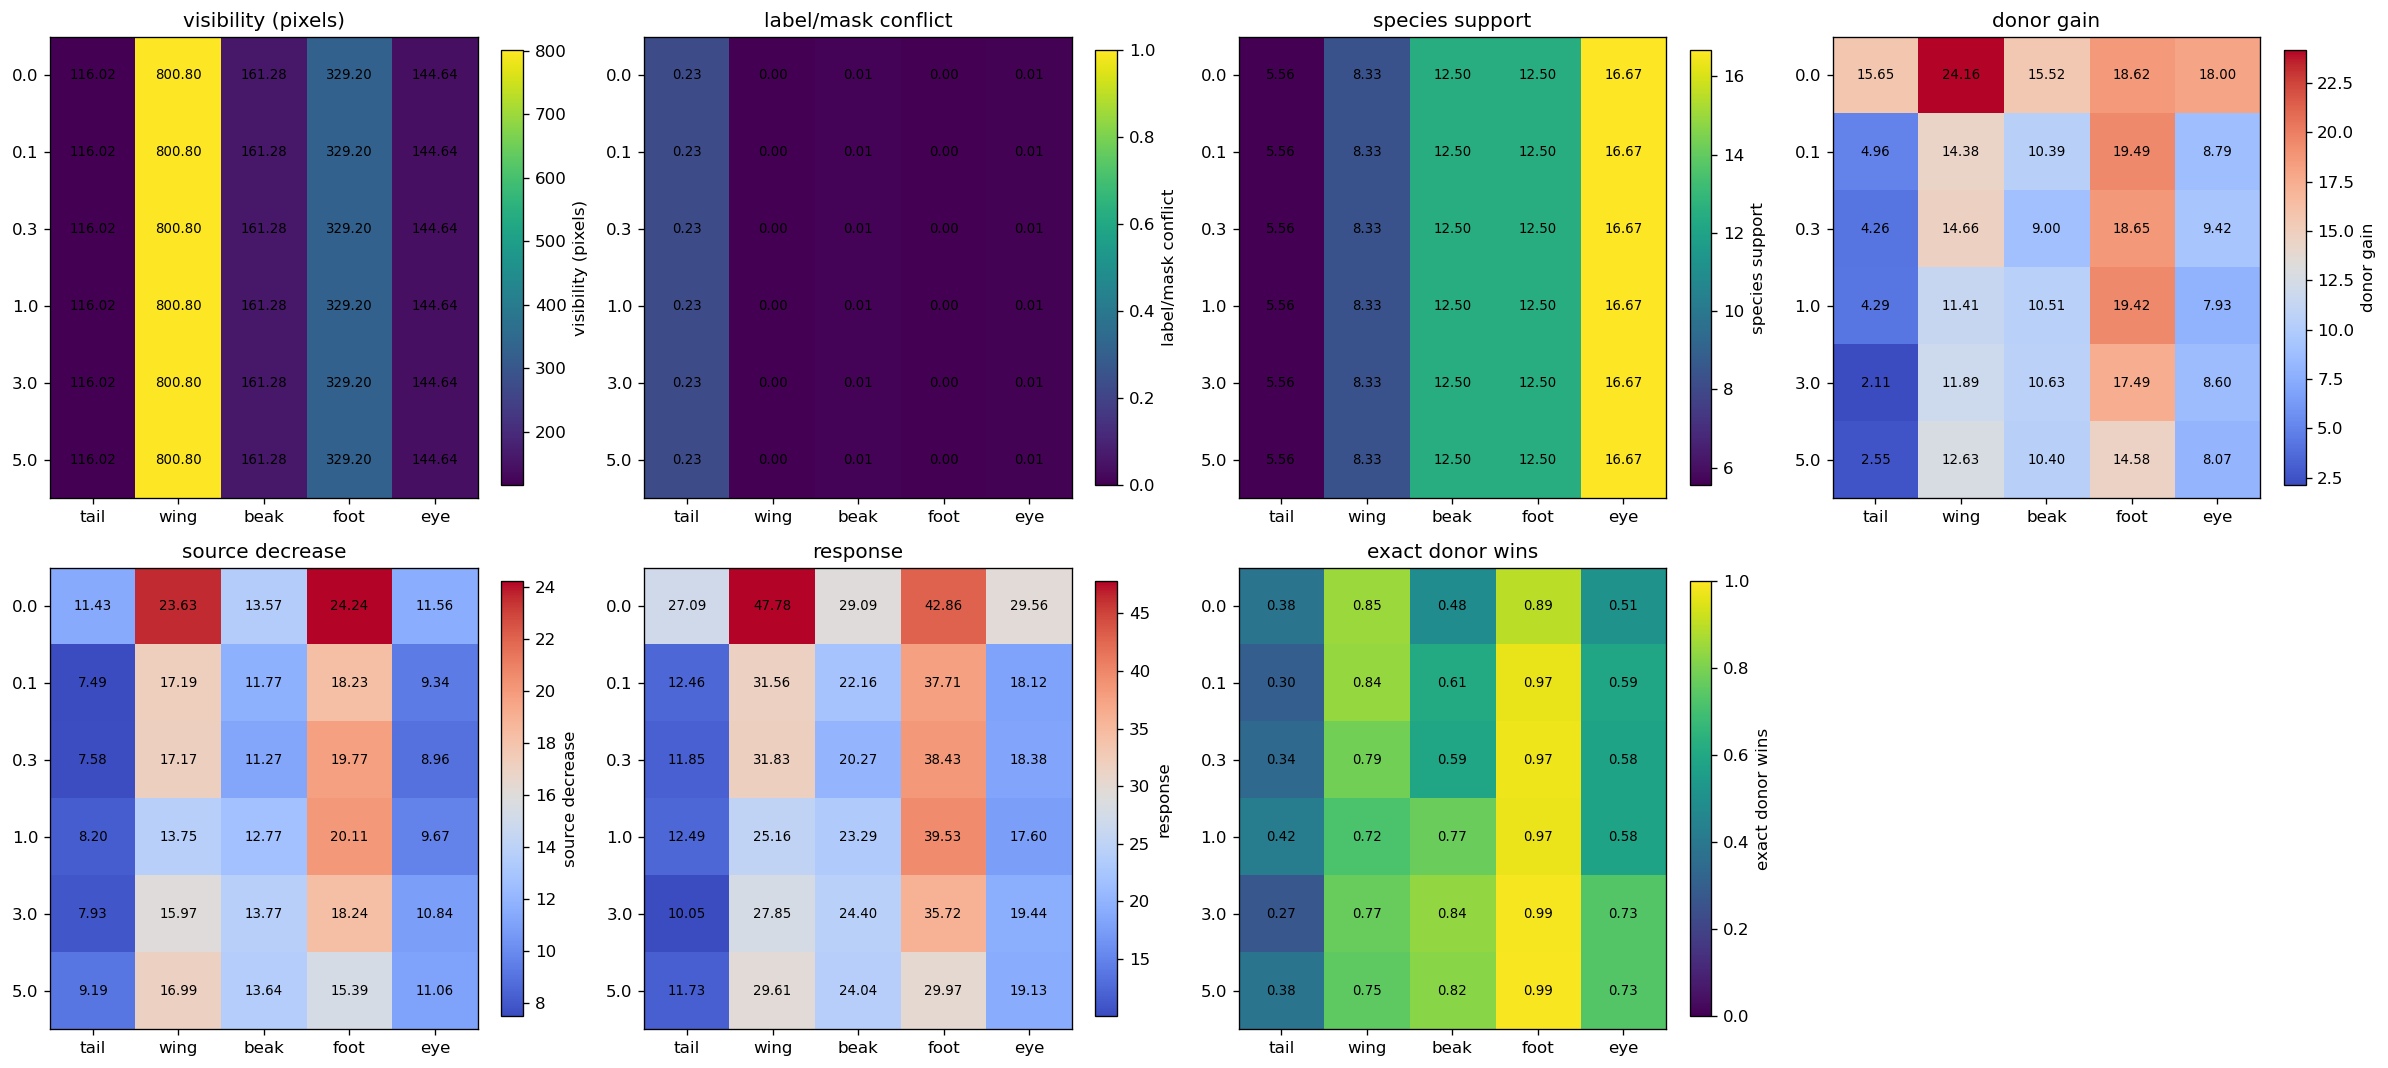

**Table — part means plotted in the seven heatmaps.** These are unweighted means over exact donor values within a part, not over all swap rows. Visibility, conflict, and support repeat across gamma because the physical data are unchanged; response columns come from each model.

,gamma,part,mean_corrected_visible_pixels,donor_conflict_rate,donor_species_support,mean_z_donor_gain,mean_z_source_decrease,mean_z_response,exact_donor_recognition
0,0.0,beak,161.2764,0.0102,12.5000,15.5183,13.5691,29.0873,0.4848
1,0.0,eye,144.6448,0.0071,16.6667,17.9998,11.5641,29.5639,0.5139
2,0.0,foot,329.2049,0.0014,12.5000,18.6180,24.2425,42.8605,0.8947
3,0.0,tail,116.0159,0.2310,5.5556,15.6549,11.4322,27.0871,0.3844
4,0.0,wing,800.8017,0.0003,8.3333,24.1553,23.6275,47.7828,0.8509
5,0.1,beak,161.2764,0.0102,12.5000,10.3910,11.7708,22.1618,0.6101
6,0.1,eye,144.6448,0.0071,16.6667,8.7873,9.3370,18.1243,0.5937
7,0.1,foot,329.2049,0.0014,12.5000,19.4851,18.2272,37.7122,0.9674
8,0.1,tail,116.0159,0.2310,5.5556,4.9621,7.4947,12.4567,0.3006
9,0.1,wing,800.8017,0.0003,8.3333,14.3760,17.1855,31.5615,0.8403


In [17]:
show_table(
  'complete donor-value audit before averaging by part',
  'One row is one gamma, part, and inserted exact value. Counts state the '
  'denominators. Pixel area, label/mask conflict, species support, donor gain, '
  'source decrease, final margin, and exact recognition are kept separate so a '
  'part mean cannot hide a difficult value.', P_VALUE.round(4))
value_metrics=[('mean_corrected_visible_pixels','visibility (pixels)'),('donor_conflict_rate','label/mask conflict'),
  ('donor_species_support','species support'),('mean_z_donor_gain','donor gain'),('mean_z_source_decrease','source decrease'),
  ('mean_z_response','response'),('exact_donor_recognition','exact donor wins')]
VALUE_PART=P_VALUE.groupby(['gamma','part'])[ [m[0] for m in value_metrics] ].mean().reset_index()
fig,axes=plt.subplots(2,4,figsize=(20,9))
for ax,(col,title) in zip(axes.flat,value_metrics):
    table=VALUE_PART.pivot(index='gamma',columns='part',values=col).reindex(index=GAMMAS,columns=ORDER)
    heat(ax,table,title,title,0 if col in {'donor_conflict_rate','exact_donor_recognition'} else None,
         1 if col in {'donor_conflict_rate','exact_donor_recognition'} else None,
         'viridis' if col not in {'mean_z_donor_gain','mean_z_source_decrease','mean_z_response'} else 'coolwarm')
axes.flat[-1].axis('off'); plt.tight_layout(); plt.show()
show_table(
  'part means plotted in the seven heatmaps',
  'These are unweighted means over exact donor values within a part, not over all '
  'swap rows. Visibility, conflict, and support repeat across gamma because the '
  'physical data are unchanged; response columns come from each model.',
  VALUE_PART.round(4))


**How to read the executed RLv2 result.** The figure and fully
captioned source table immediately above are the result; no expected
observation was written into the notebook before execution.

**Question → test → boundary.** Compare the RLv2 output with the
executed Standard-MCBM output directly above it. A change is evidence
about visibility-aware labels only when model gamma, formula, physical
swap rows, and denominator match. It does not turn an association into
a cause, and seed 1 does not provide initialization uncertainty.

**Next question.** Continue to the next identical analysis stage, then
use the final matched-difference table to decide which part and pathway
actually changed.


## 5. Species information: available, used, and causally relevant are different

**Question.** Does MCBM reduce species information in concept magnitudes, and
does its saved species head actually depend on that information?

**Three separate tests.** (1) A new held-out logistic diagnostic measures how
much species prediction improves from raw magnitudes after the 0/1 labels are
known. (2) The unchanged saved species head is rerun after within-label
magnitudes are replaced by training-fold label means. (3) On swaps, off-target
same-part `h` coordinates are restored to their exact original-image values,
while the source and donor coordinates remain fixed; the unchanged saved
species head is rerun. Test 3 is the direct intervention.

The Standard decoding, saved-head reliance, and off-target intervention are
displayed exactly first. Their linear `Wz+b` head is not substituted for
MCBM's nonlinear head.


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f13d-`**

STANDARD — identical four-panel calculation


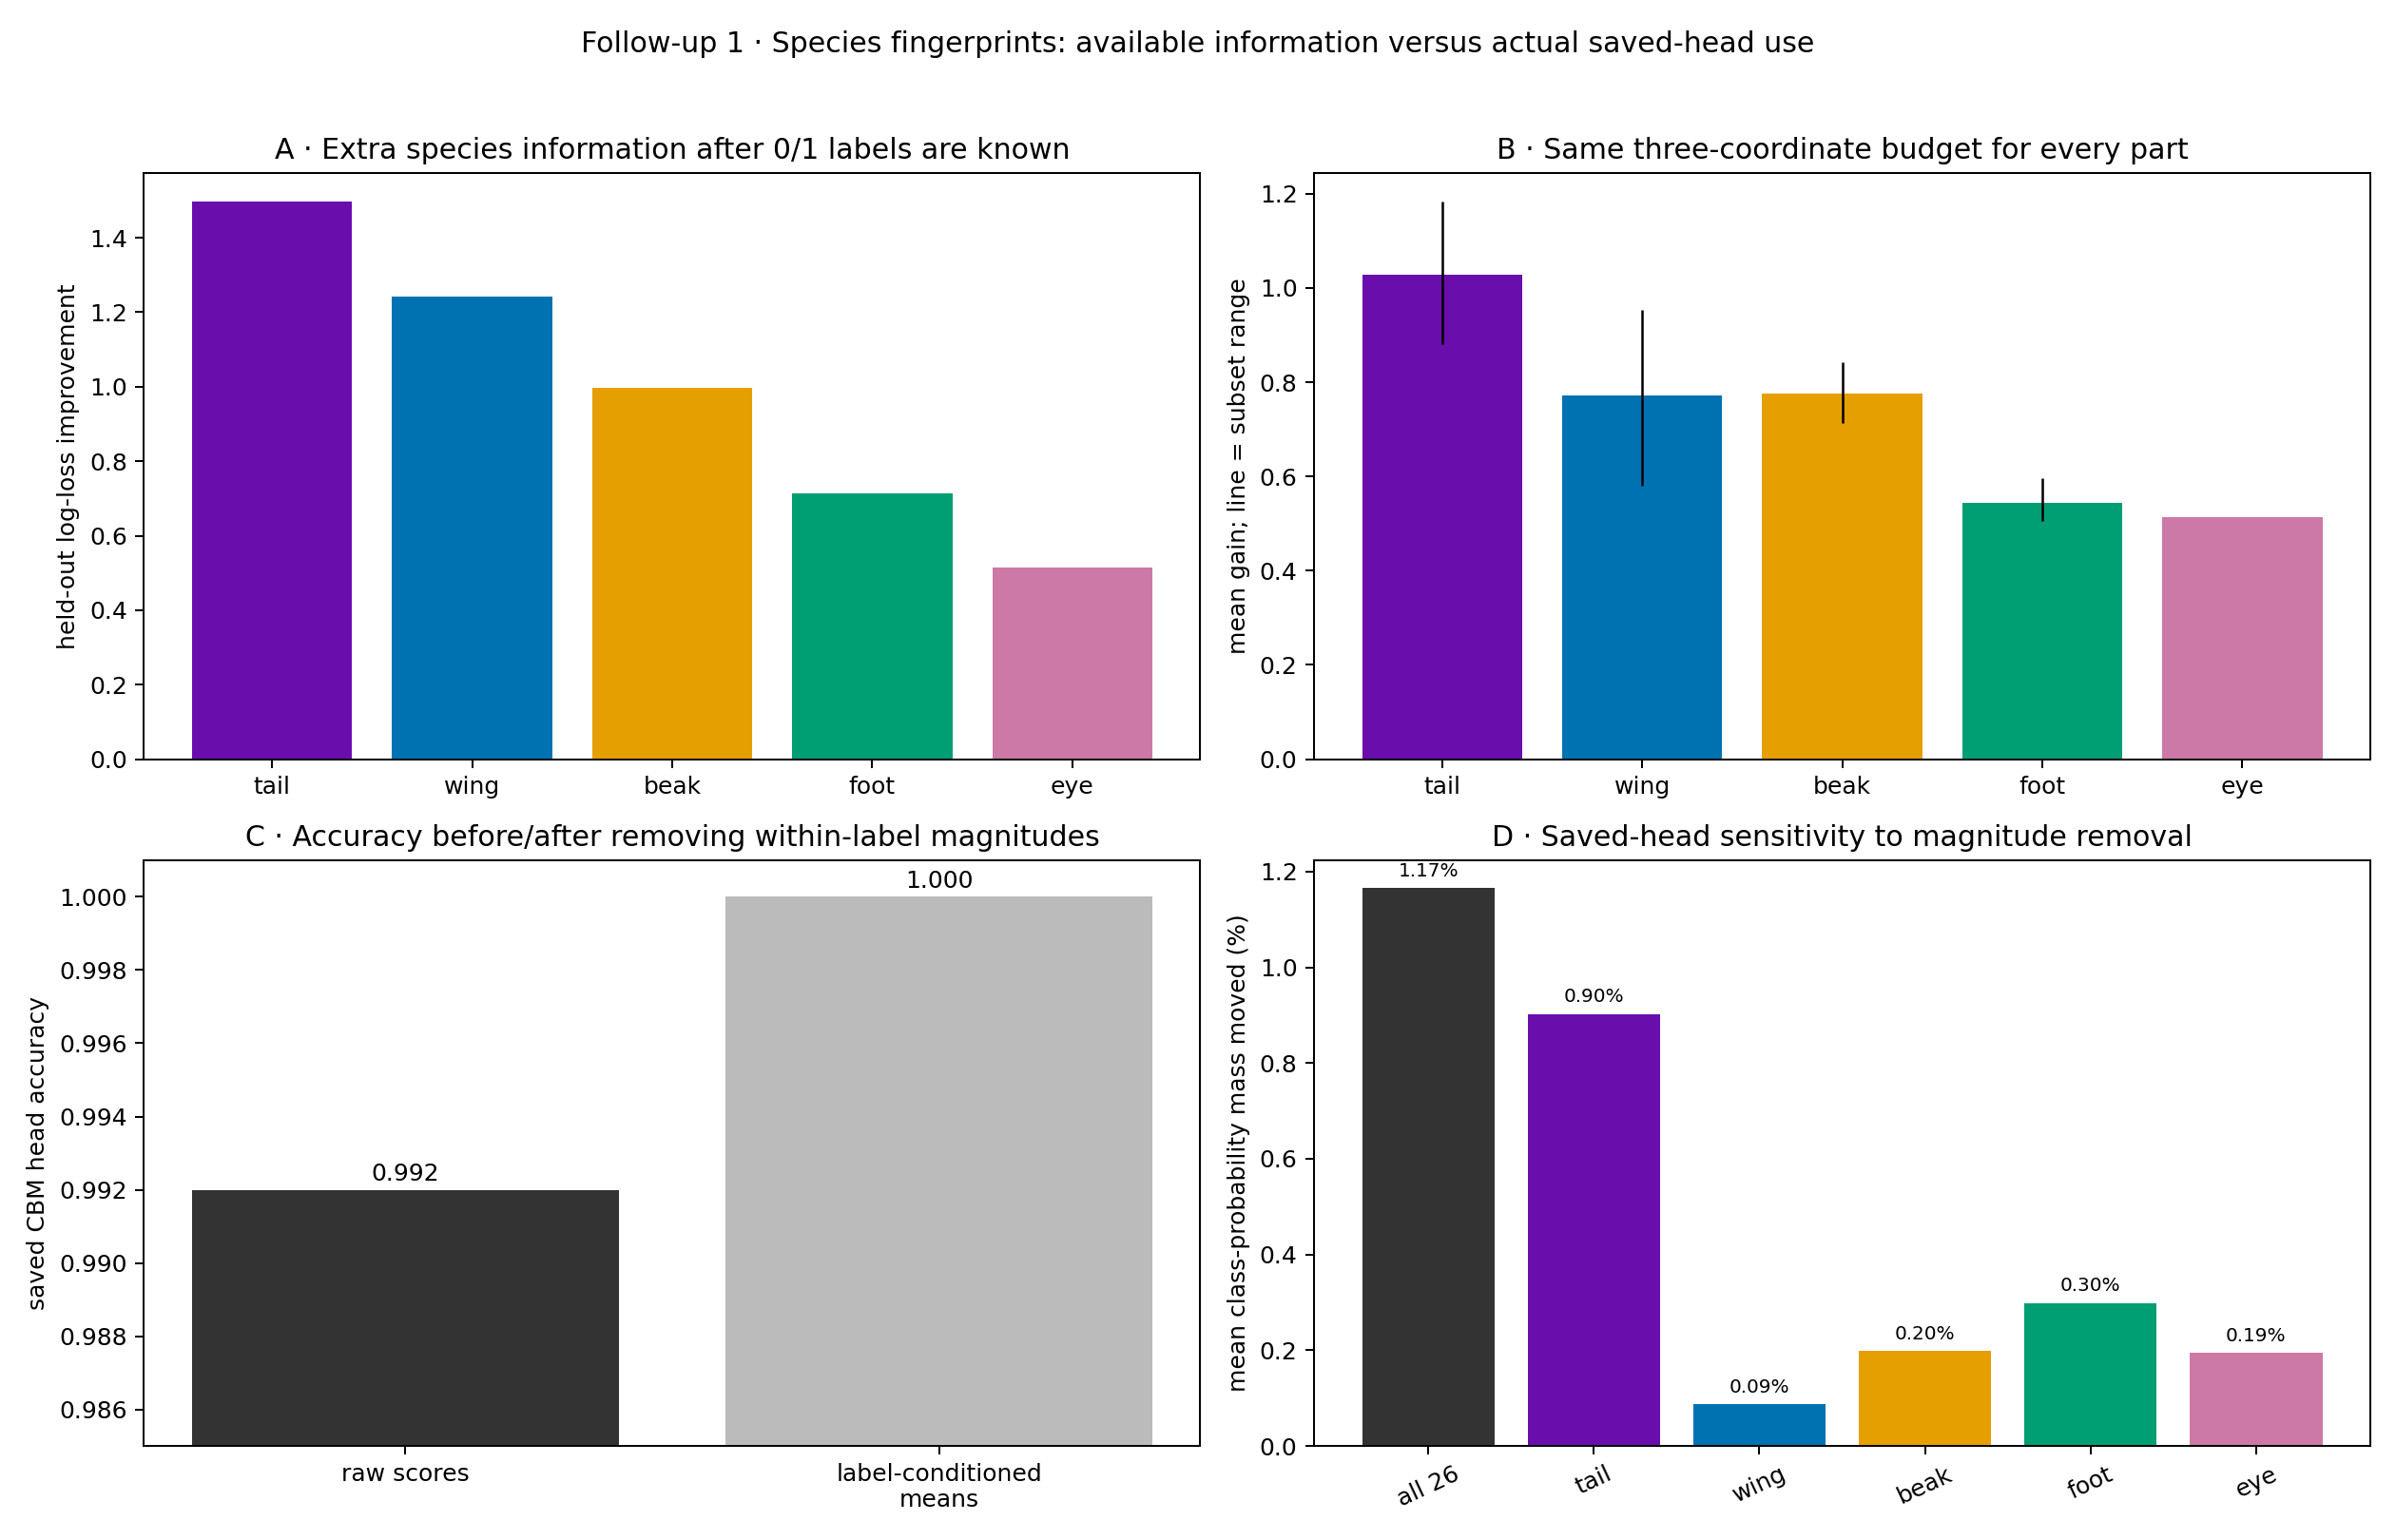

,part,coordinates,conditional_logloss_gain,gain_per_coordinate_descriptive
0,beak,4,0.9981,0.2495
1,eye,3,0.5145,0.1715
2,foot,4,0.7134,0.1784
3,tail,9,1.4977,0.1664
4,wing,6,1.2424,0.2071


,part,three_coordinate_subsets,mean_conditional_gain,min_conditional_gain,max_conditional_gain
0,beak,4,0.7751,0.7129,0.8426
1,eye,1,0.5145,0.5145,0.5145
2,foot,4,0.5448,0.5064,0.5973
3,tail,40,1.0279,0.8812,1.1840
4,wing,20,0.7710,0.5812,0.9544


,replaced_block,coordinates_replaced,raw_accuracy,accuracy_after_replacement,top1_change_rate,mean_probability_mass_moved
0,all 26,26,0.992,1.000,0.008,0.0117
1,beak,4,0.992,0.992,0.000,0.0020
2,eye,3,0.992,0.992,0.000,0.0019
3,foot,4,0.992,0.994,0.002,0.0030
4,tail,9,0.992,0.998,0.006,0.0090
5,wing,6,0.992,0.992,0.000,0.0009


RLV2 — identical four-panel calculation


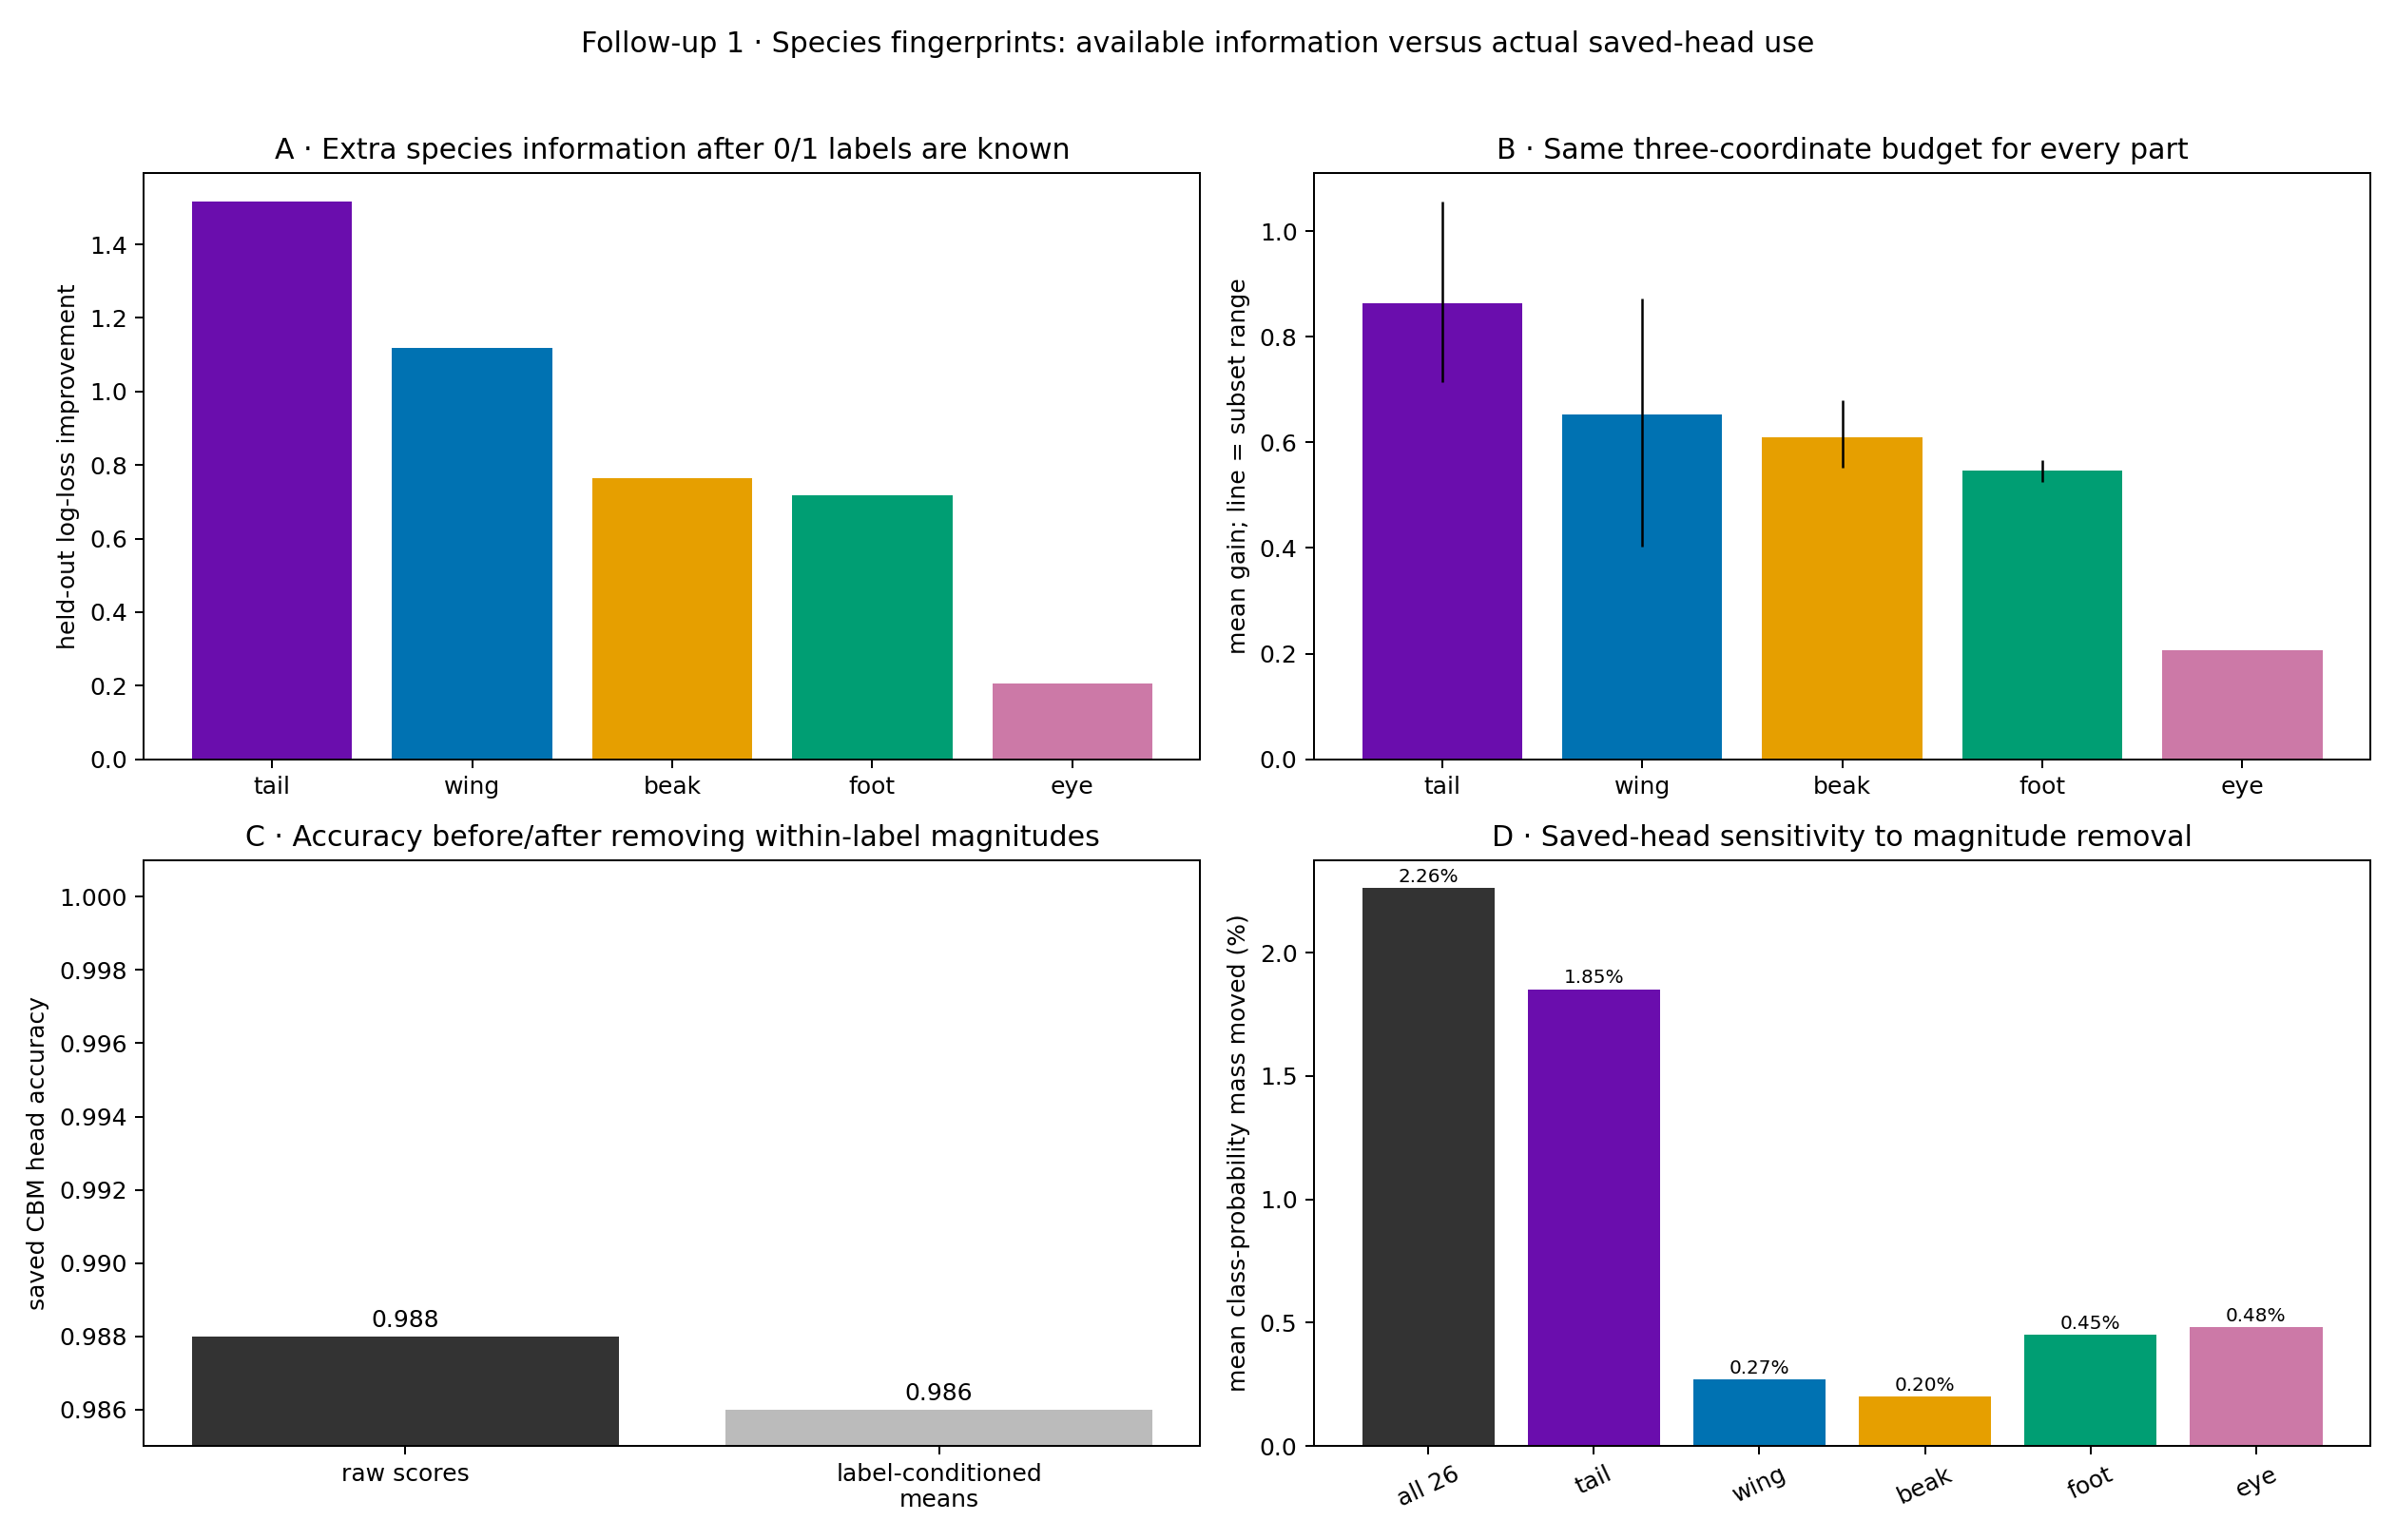

,part,coordinates,conditional_logloss_gain,gain_per_coordinate_descriptive
0,beak,4,0.7652,0.1913
1,eye,3,0.2069,0.0690
2,foot,4,0.7187,0.1797
3,tail,9,1.5174,0.1686
4,wing,6,1.1184,0.1864


,part,three_coordinate_subsets,mean_conditional_gain,min_conditional_gain,max_conditional_gain
0,beak,4,0.6096,0.5514,0.6805
1,eye,1,0.2069,0.2069,0.2069
2,foot,4,0.5461,0.5248,0.5670
3,tail,40,0.8641,0.7142,1.0564
4,wing,20,0.6524,0.4034,0.8721


,replaced_block,coordinates_replaced,raw_accuracy,accuracy_after_replacement,top1_change_rate,mean_probability_mass_moved
0,all 26,26,0.988,0.986,0.024,0.0226
1,beak,4,0.988,0.986,0.004,0.0020
2,eye,3,0.988,0.990,0.004,0.0048
3,foot,4,0.988,0.990,0.002,0.0045
4,tail,9,0.988,0.982,0.020,0.0185
5,wing,6,0.988,0.990,0.002,0.0027


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f13e-`**

STANDARD — identical off-target erasure


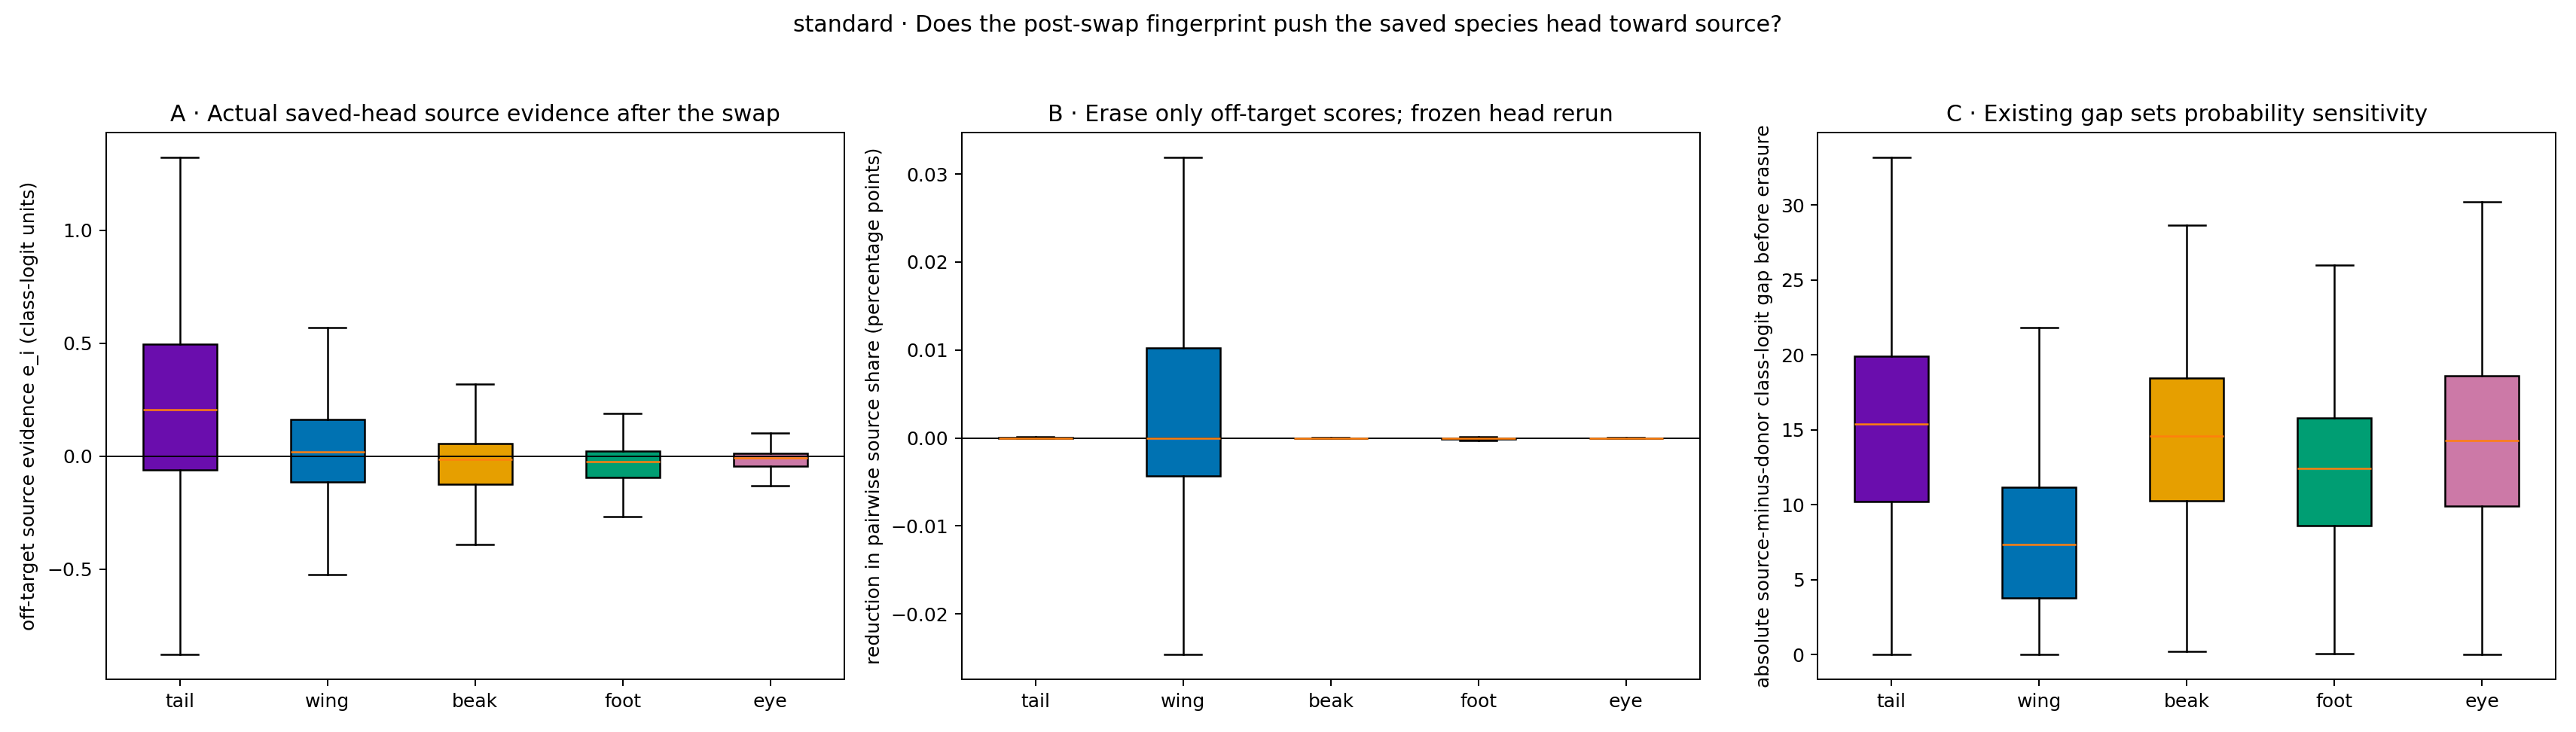

,part,n_swaps,n_original_images,off_target_coordinates,mean_e,median_e,fraction_e_positive,median_absolute_e,median_absolute_source_minus_donor_gap,mean_pairwise_source_share_reduction,top1_change_rate,source_to_donor_pair_flip_rate
0,tail,1000,250,7,0.2261,0.2042,0.699,0.3180,15.3748,0.0003,0.099,0.002
1,wing,1000,250,4,0.0212,0.0187,0.534,0.1428,7.3557,0.0002,0.034,0.004
2,beak,1000,250,2,-0.0325,-0.0143,0.438,0.0854,14.5976,-0.0007,0.027,0.000
3,foot,1000,250,2,-0.0406,-0.0259,0.369,0.0566,12.4407,-0.0002,0.021,0.001
4,eye,1000,250,1,-0.0198,-0.0067,0.411,0.0306,14.2733,-0.0002,0.007,0.000


RLV2 — identical off-target erasure


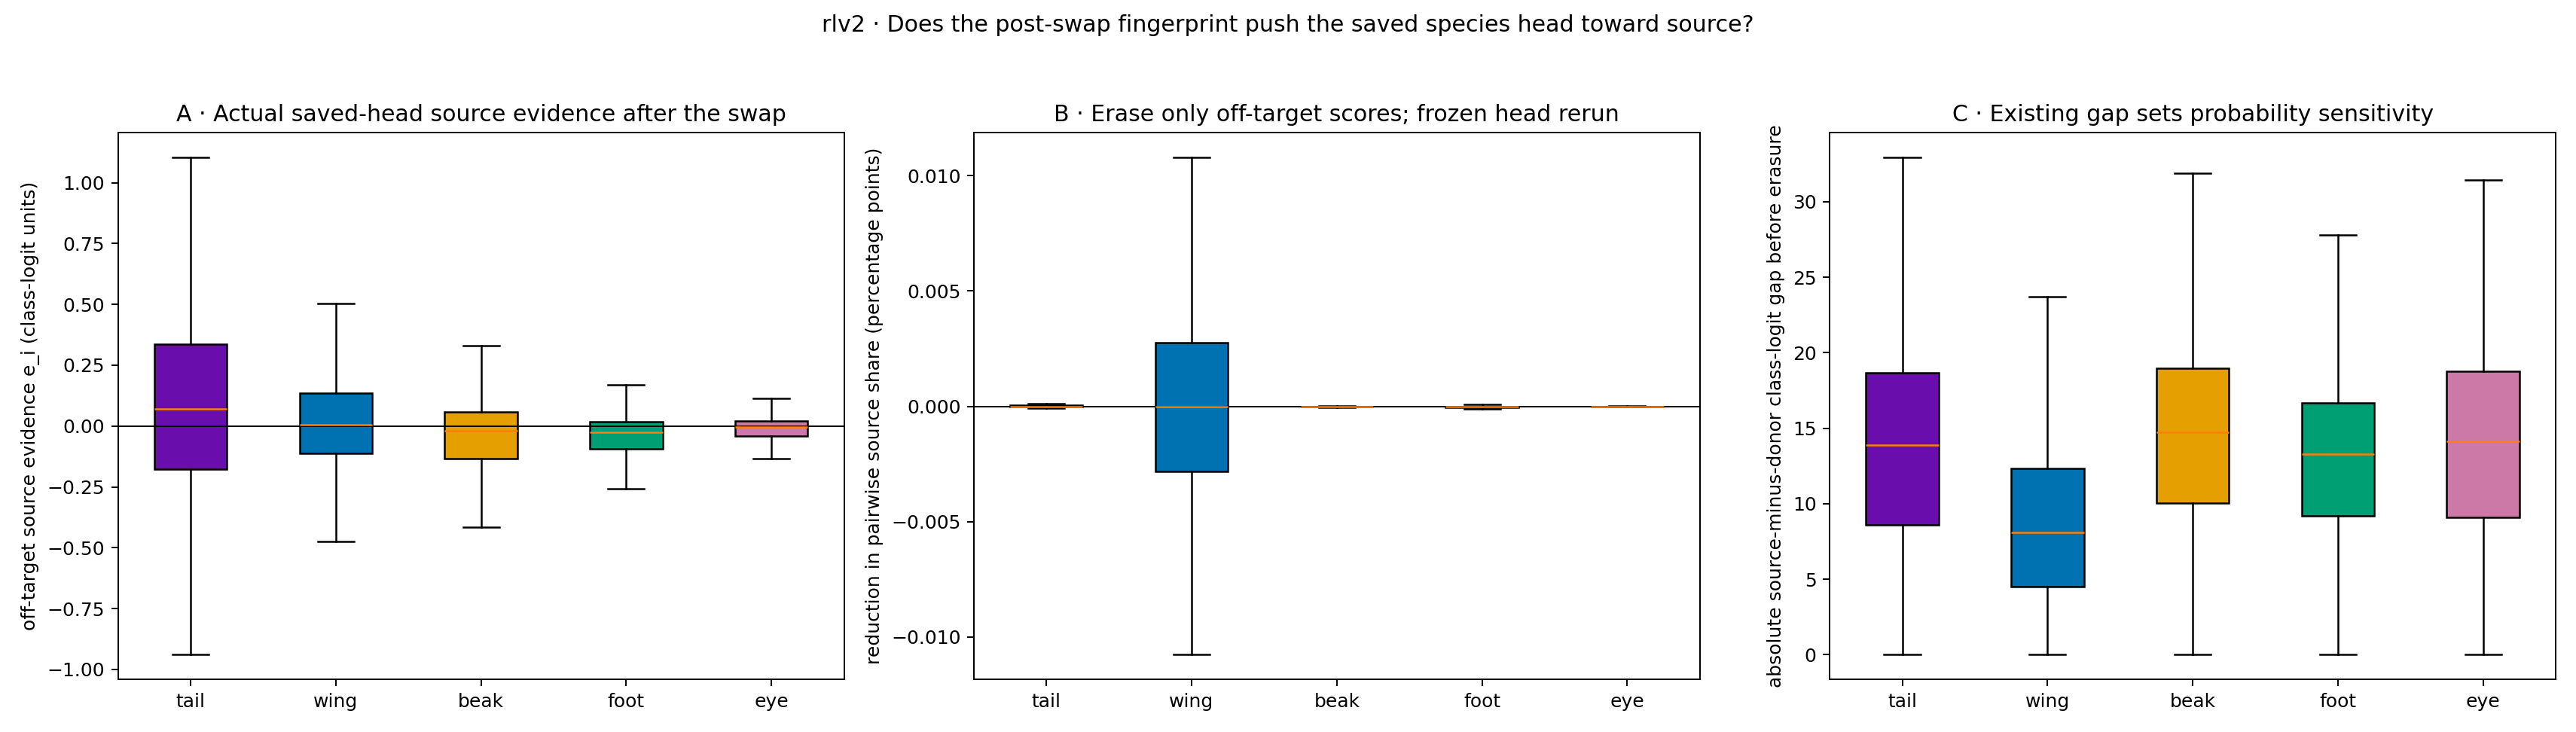

,part,n_swaps,n_original_images,off_target_coordinates,mean_e,median_e,fraction_e_positive,median_absolute_e,median_absolute_source_minus_donor_gap,mean_pairwise_source_share_reduction,top1_change_rate,source_to_donor_pair_flip_rate
0,tail,1000,250,7,0.0982,0.0692,0.570,0.2531,13.8831,0.0005,0.065,0.004
1,wing,1000,250,4,0.0111,0.0050,0.513,0.1239,8.0957,0.0005,0.032,0.001
2,beak,1000,250,2,-0.0343,-0.0188,0.429,0.0889,14.7241,-0.0003,0.025,0.000
3,foot,1000,250,2,-0.0383,-0.0241,0.375,0.0578,13.2839,-0.0002,0.021,0.000
4,eye,1000,250,1,-0.0151,-0.0049,0.434,0.0311,14.1149,-0.0001,0.004,0.000


In [18]:
show_standard('f8b','r8b-compare','f8c-source','f8d-source')


### Executed Standard-MCBM result — mcbm-info

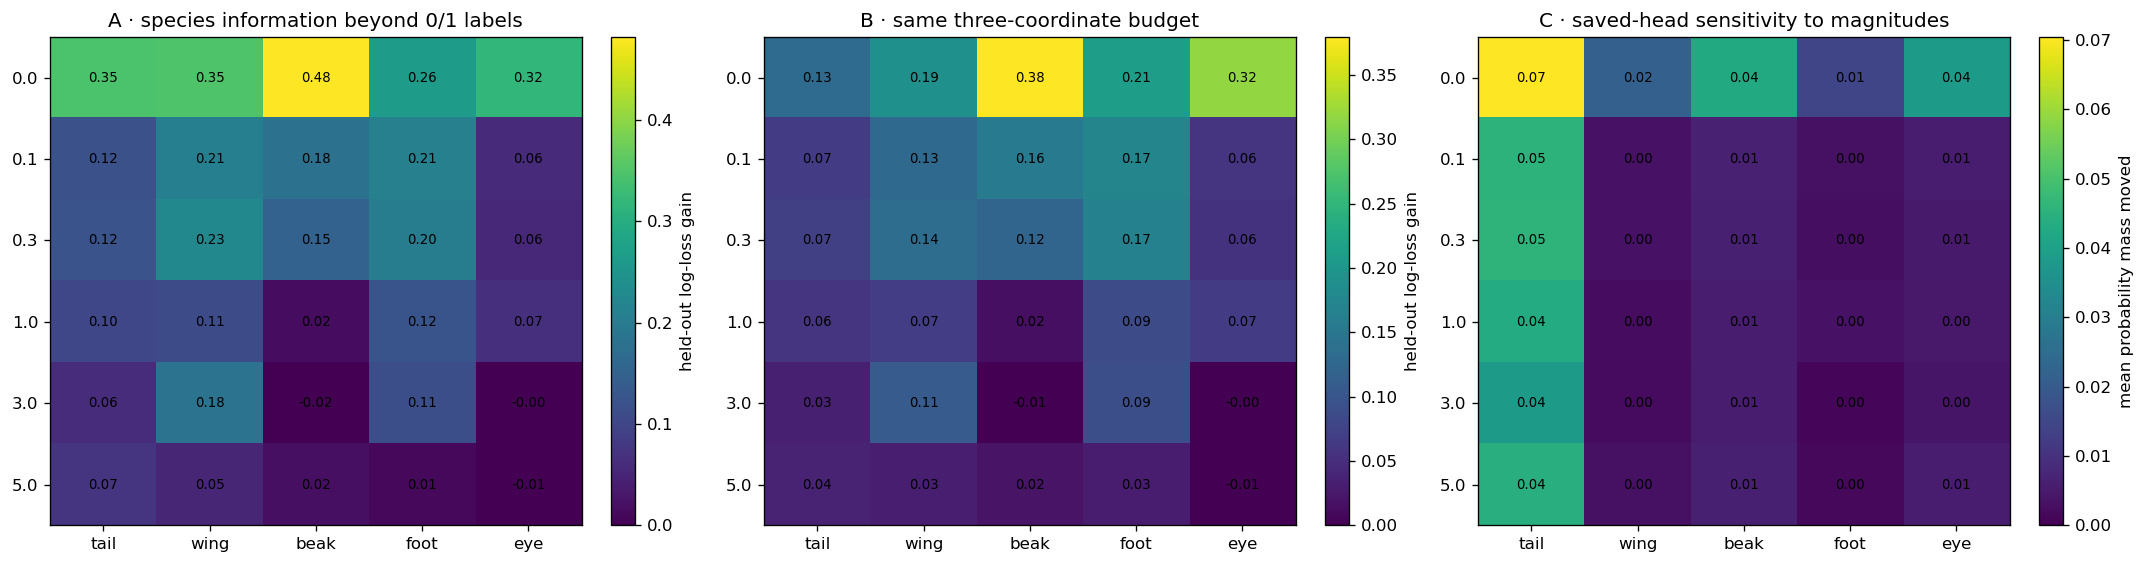

**Table — species information after the yes/no labels are already known.** `conditional_logloss_gain` is the held-out species log-loss improvement when raw magnitudes are added to the matching 0/1 labels. Larger is more extra species information; a small negative value means this fitted diagnostic generalized slightly worse, not “negative information.”

,part,coordinates,conditional_logloss_gain,gain_per_coordinate_descriptive,gamma
0,beak,4,0.4817,0.1204,0.0
1,eye,3,0.3182,0.1061,0.0
2,foot,4,0.2644,0.0661,0.0
3,tail,9,0.3455,0.0384,0.0
4,wing,6,0.3491,0.0582,0.0
5,beak,4,0.1810,0.0453,0.1
6,eye,3,0.0565,0.0188,0.1
7,foot,4,0.2106,0.0527,0.1
8,tail,9,0.1194,0.0133,0.1
9,wing,6,0.2083,0.0347,0.1


**Table — same three-coordinate information budget for every part.** Each subset contains exactly three coordinates. `mean_conditional_gain` averages all such subsets; min/max are the subset range, not uncertainty bars.

,part,three_coordinate_subsets,mean_conditional_gain,min_conditional_gain,max_conditional_gain,gamma
0,beak,4,0.3796,0.2579,0.4995,0.0
1,eye,1,0.3182,0.3182,0.3182,0.0
2,foot,4,0.2108,0.1373,0.2699,0.0
3,tail,40,0.1331,0.0446,0.3621,0.0
4,wing,20,0.1909,0.0237,0.3737,0.0
5,beak,4,0.1552,0.1248,0.1776,0.1
6,eye,1,0.0565,0.0565,0.0565,0.1
7,foot,4,0.1724,0.1448,0.1962,0.1
8,tail,40,0.0674,0.0484,0.0953,0.1
9,wing,20,0.1301,0.0762,0.1875,0.1


**Table — actual sensitivity of the unchanged saved MCBM species head.** Within each held-out fold, selected `h` magnitudes are replaced by the training-fold mean for the same 0/1 label. `mean_probability_mass_moved` is half the total absolute change across all 50 species probabilities; `top1_change_rate` is the fraction whose most likely species changes.

,replaced_block,coordinates_replaced,raw_accuracy,accuracy_after_replacement,top1_change_rate,mean_probability_mass_moved,gamma
0,all 26,26,0.7342,0.7670,0.1564,0.1080,0.0
1,beak,4,0.7342,0.7358,0.0844,0.0429,0.0
2,eye,3,0.7342,0.7500,0.0614,0.0383,0.0
3,foot,4,0.7342,0.7354,0.0336,0.0147,0.0
4,tail,9,0.7342,0.7552,0.0916,0.0704,0.0
5,wing,6,0.7342,0.7324,0.0450,0.0215,0.0
6,all 26,26,0.7544,0.7790,0.0938,0.0515,0.1
7,beak,4,0.7544,0.7544,0.0172,0.0065,0.1
8,eye,3,0.7544,0.7554,0.0142,0.0057,0.1
9,foot,4,0.7544,0.7542,0.0082,0.0032,0.1


In [19]:
show_standard_mcbm('mcbm-info')


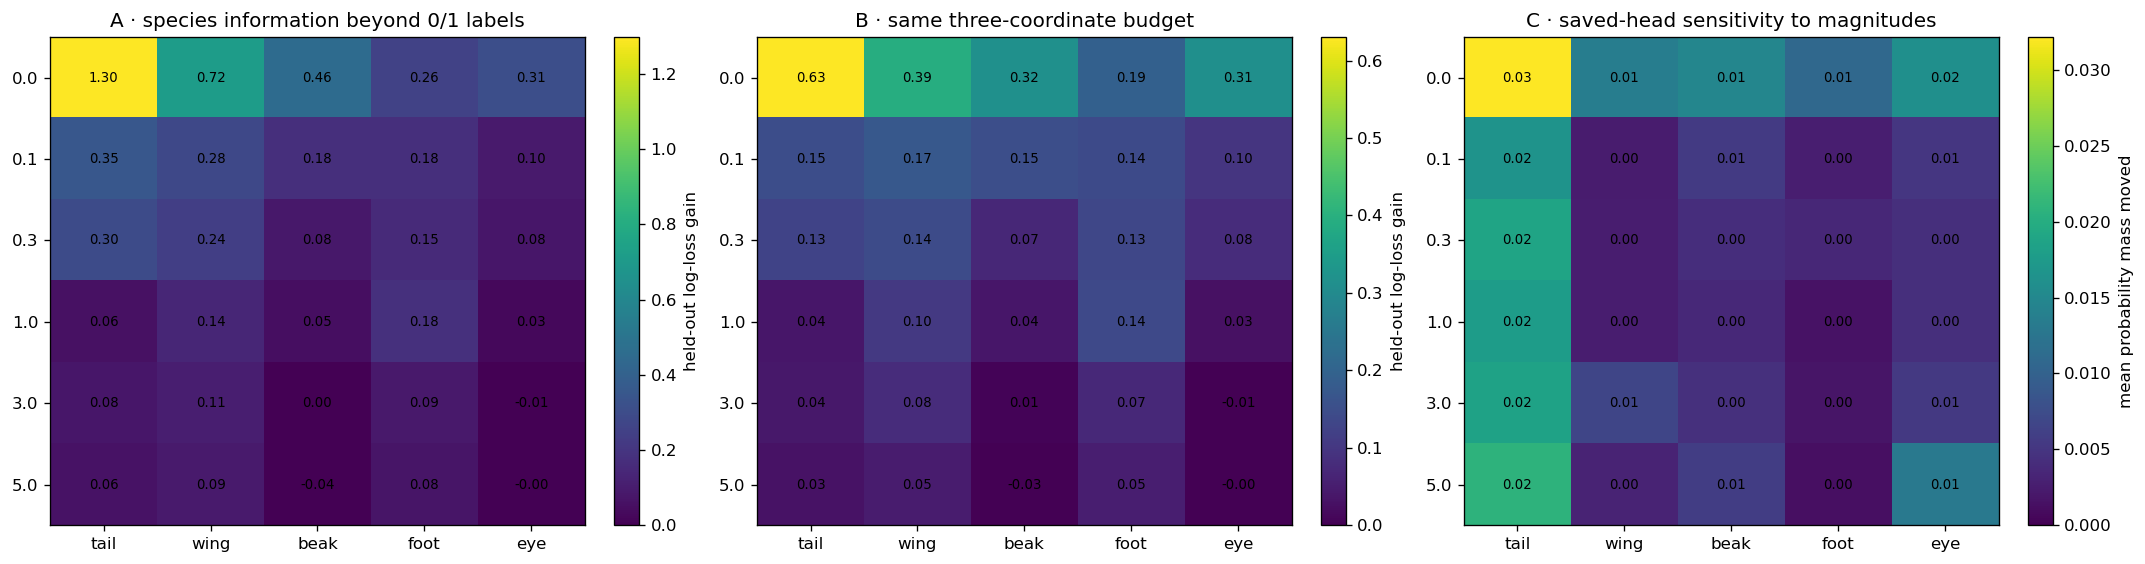

**Table — species information after the yes/no labels are already known.** `conditional_logloss_gain` is the held-out species log-loss improvement when raw magnitudes are added to the matching 0/1 labels. Larger is more extra species information; a small negative value means this fitted diagnostic generalized slightly worse, not “negative information.”

,part,coordinates,conditional_logloss_gain,gain_per_coordinate_descriptive,gamma
0,beak,4,0.4550,0.1138,0.0
1,eye,3,0.3137,0.1046,0.0
2,foot,4,0.2565,0.0641,0.0
3,tail,9,1.2975,0.1442,0.0
4,wing,6,0.7182,0.1197,0.0
5,beak,4,0.1767,0.0442,0.1
6,eye,3,0.0963,0.0321,0.1
7,foot,4,0.1764,0.0441,0.1
8,tail,9,0.3512,0.0390,0.1
9,wing,6,0.2822,0.0470,0.1


**Table — same three-coordinate information budget for every part.** Each subset contains exactly three coordinates. `mean_conditional_gain` averages all such subsets; min/max are the subset range, not uncertainty bars.

,part,three_coordinate_subsets,mean_conditional_gain,min_conditional_gain,max_conditional_gain,gamma
0,beak,4,0.3162,0.2543,0.4431,0.0
1,eye,1,0.3137,0.3137,0.3137,0.0
2,foot,4,0.1927,0.0724,0.2403,0.0
3,tail,40,0.6304,0.5437,0.7103,0.0
4,wing,20,0.3917,0.2540,0.5621,0.0
5,beak,4,0.1507,0.1372,0.1601,0.1
6,eye,1,0.0963,0.0963,0.0963,0.1
7,foot,4,0.1422,0.1380,0.1469,0.1
8,tail,40,0.1499,0.0816,0.2125,0.1
9,wing,20,0.1743,0.0886,0.2600,0.1


**Table — actual sensitivity of the unchanged saved MCBM species head.** Within each held-out fold, selected `h` magnitudes are replaced by the training-fold mean for the same 0/1 label. `mean_probability_mass_moved` is half the total absolute change across all 50 species probabilities; `top1_change_rate` is the fraction whose most likely species changes.

,replaced_block,coordinates_replaced,raw_accuracy,accuracy_after_replacement,top1_change_rate,mean_probability_mass_moved,gamma
0,all 26,26,0.7496,0.7500,0.0716,0.0416,0.0
1,beak,4,0.7496,0.7484,0.0312,0.0147,0.0
2,eye,3,0.7496,0.7496,0.0340,0.0161,0.0
3,foot,4,0.7496,0.7494,0.0238,0.0108,0.0
4,tail,9,0.7496,0.7446,0.0600,0.0322,0.0
5,wing,6,0.7496,0.7472,0.0246,0.0136,0.0
6,all 26,26,0.7474,0.7538,0.0422,0.0250,0.1
7,beak,4,0.7474,0.7480,0.0082,0.0054,0.1
8,eye,3,0.7474,0.7478,0.0124,0.0051,0.1
9,foot,4,0.7474,0.7472,0.0070,0.0027,0.1


In [20]:
info=[]; equal=[]; head=[]
for g in GAMMAS:
    paths={'info':TABLES/f'g{TAG[g][1:]}_FULL_WIDTH_INFORMATION.csv',
            'equal':TABLES/f'g{TAG[g][1:]}_EQUAL_WIDTH_INFORMATION.csv',
            'head':TABLES/f'g{TAG[g][1:]}_HEAD_USE.csv'}
    # Older table names use the literal tag, including g0p1.
    paths={k:(TABLES/f'{TAG[g]}_{suffix}.csv') for k,suffix in
           [('info','FULL_WIDTH_INFORMATION'),('equal','EQUAL_WIDTH_INFORMATION'),('head','HEAD_USE')]}
    for path in paths.values():
        if not path.is_file(): raise FileNotFoundError(path)
    a=pd.read_csv(paths['info']); a['gamma']=g; info.append(a)
    b=pd.read_csv(paths['equal']); b['gamma']=g; equal.append(b)
    c=pd.read_csv(paths['head']); c['gamma']=g; head.append(c)
INFO=pd.concat(info,ignore_index=True); EQUAL=pd.concat(equal,ignore_index=True); HEAD=pd.concat(head,ignore_index=True)
fig,axes=plt.subplots(1,3,figsize=(18,4.8))
for ax,data,col,title in [
  (axes[0],INFO,'conditional_logloss_gain','A · species information beyond 0/1 labels'),
  (axes[1],EQUAL,'mean_conditional_gain','B · same three-coordinate budget'),
  (axes[2],HEAD[HEAD.replaced_block.isin(ORDER)],'mean_probability_mass_moved','C · saved-head sensitivity to magnitudes')]:
    idx='part' if 'part' in data else 'replaced_block'
    table=data.pivot(index='gamma',columns=idx,values=col).reindex(index=GAMMAS,columns=ORDER)
    heat(ax,table,title,'held-out log-loss gain' if 'gain' in col else 'mean probability mass moved',0,None,'viridis')
plt.tight_layout(); plt.show()
show_table(
  'species information after the yes/no labels are already known',
  '`conditional_logloss_gain` is the held-out species log-loss improvement when '
  'raw magnitudes are added to the matching 0/1 labels. Larger is more extra '
  'species information; a small negative value means this fitted diagnostic '
  'generalized slightly worse, not “negative information.”', INFO.round(4))
show_table(
  'same three-coordinate information budget for every part',
  'Each subset contains exactly three coordinates. `mean_conditional_gain` averages '
  'all such subsets; min/max are the subset range, not uncertainty bars.',
  EQUAL.round(4))
show_table(
  'actual sensitivity of the unchanged saved MCBM species head',
  'Within each held-out fold, selected `h` magnitudes are replaced by the training-'
  'fold mean for the same 0/1 label. `mean_probability_mass_moved` is half the '
  'total absolute change across all 50 species probabilities; `top1_change_rate` '
  'is the fraction whose most likely species changes.', HEAD.round(4))


**How to read the executed RLv2 result.** The figure and fully
captioned source table immediately above are the result; no expected
observation was written into the notebook before execution.

**Question → test → boundary.** Compare the RLv2 output with the
executed Standard-MCBM output directly above it. A change is evidence
about visibility-aware labels only when model gamma, formula, physical
swap rows, and denominator match. It does not turn an association into
a cause, and seed 1 does not provide initialization uncertainty.

**Next question.** Continue to the next identical analysis stage, then
use the final matched-difference table to decide which part and pathway
actually changed.


### Direct frozen-head intervention on swapped images

Example for `tail_2 → tail_7`: MCBM always has nine tail coordinates. Keep
the counterfactual `tail_2` and `tail_7` values exactly unchanged. Replace
the other seven tail coordinates with their values from the matching
original image. Rerun the same saved species head.

`source evidence = (source logit - donor logit)_before -
(source logit - donor logit)_after`.

Positive means the swap-induced off-target changes had been helping the old
source species; negative means they had been helping the donor. Panel C's
pairwise flip rate asks the narrow decision-relevant question. Panel D's
probability-mass movement can include unrelated species and must not be
called a source-to-donor flip.


### Executed Standard-MCBM result — hybrid

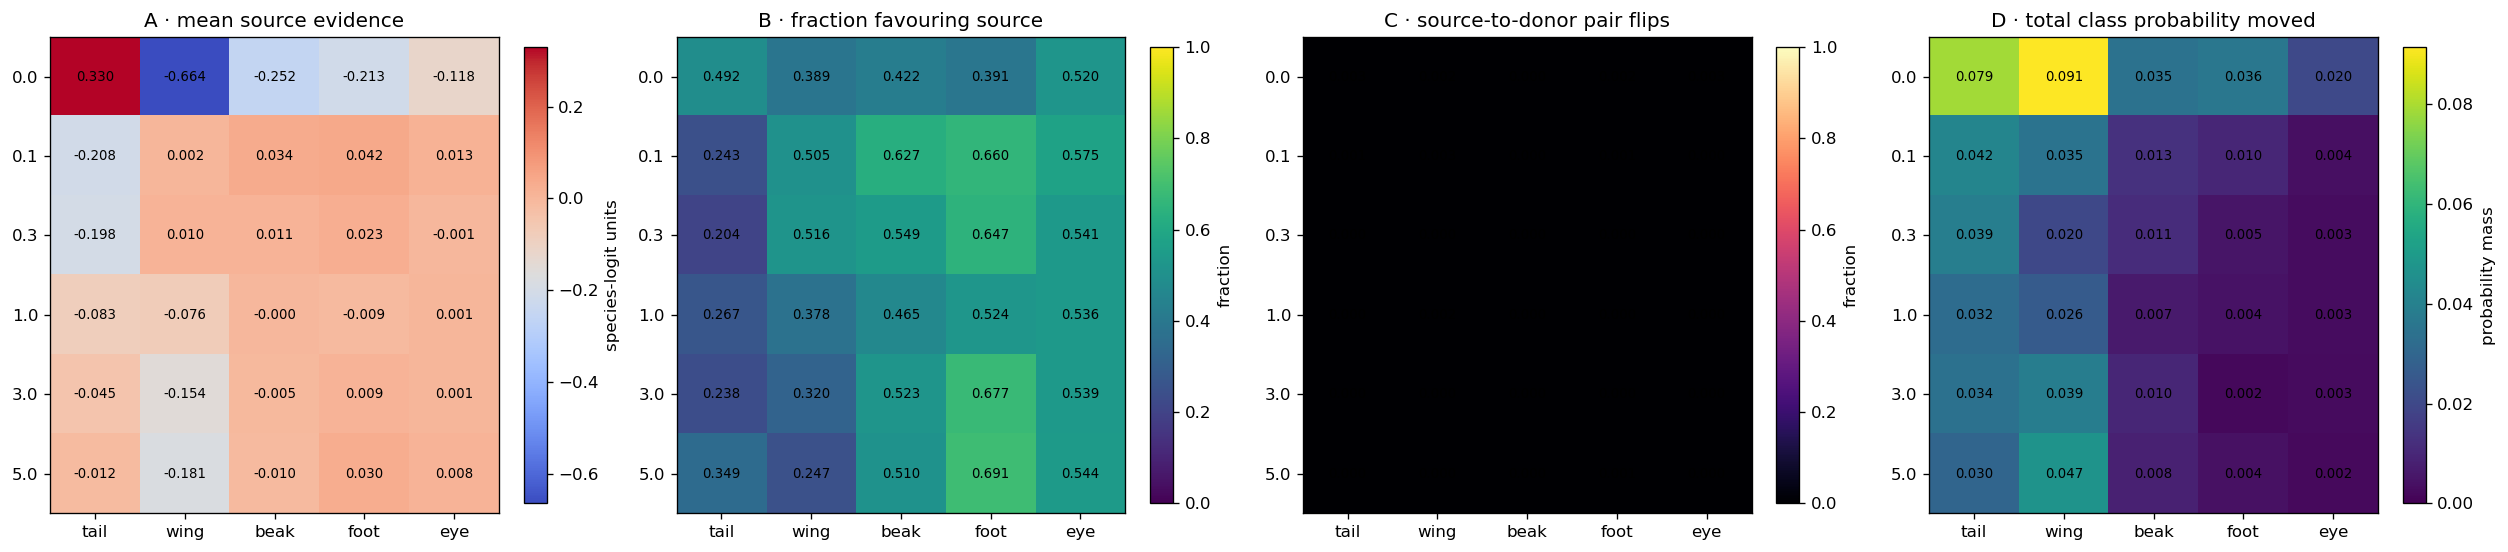

**Table — direct off-target intervention behind Panels A–D.** For each swap, old and donor coordinates stay fixed while every other coordinate of that part is restored to the matching original image. Positive source evidence means those swap-induced off-target changes had favored the source species. The pair-flip rate and all-species probability movement are different outcomes.

,gamma,part,n_rows,n_originals,mean_swap_induced_offtarget_source_evidence,median_swap_induced_offtarget_source_evidence,fraction_source_evidence_positive,pairwise_source_to_donor_flip_rate,top1_change_rate,mean_probability_mass_moved
0,0.0,beak,1000,250,-0.25242,-0.13346,0.422,0.000,0.033,0.03459
1,0.0,eye,1000,250,-0.11838,0.00913,0.520,0.003,0.020,0.02012
2,0.0,foot,1000,250,-0.21270,-0.10614,0.391,0.002,0.042,0.03614
3,0.0,tail,1000,250,0.32987,0.00000,0.492,0.003,0.082,0.07865
4,0.0,wing,1000,250,-0.66357,-0.35713,0.389,0.002,0.103,0.09141
5,0.1,beak,1000,250,0.03360,0.02398,0.627,0.000,0.026,0.01317
6,0.1,eye,1000,250,0.01268,0.00494,0.575,0.000,0.011,0.00375
7,0.1,foot,1000,250,0.04242,0.02367,0.660,0.001,0.007,0.00992
8,0.1,tail,1000,250,-0.20777,-0.12334,0.243,0.001,0.086,0.04159
9,0.1,wing,1000,250,0.00156,0.00666,0.505,0.003,0.046,0.03472


In [21]:
show_standard_mcbm('hybrid')


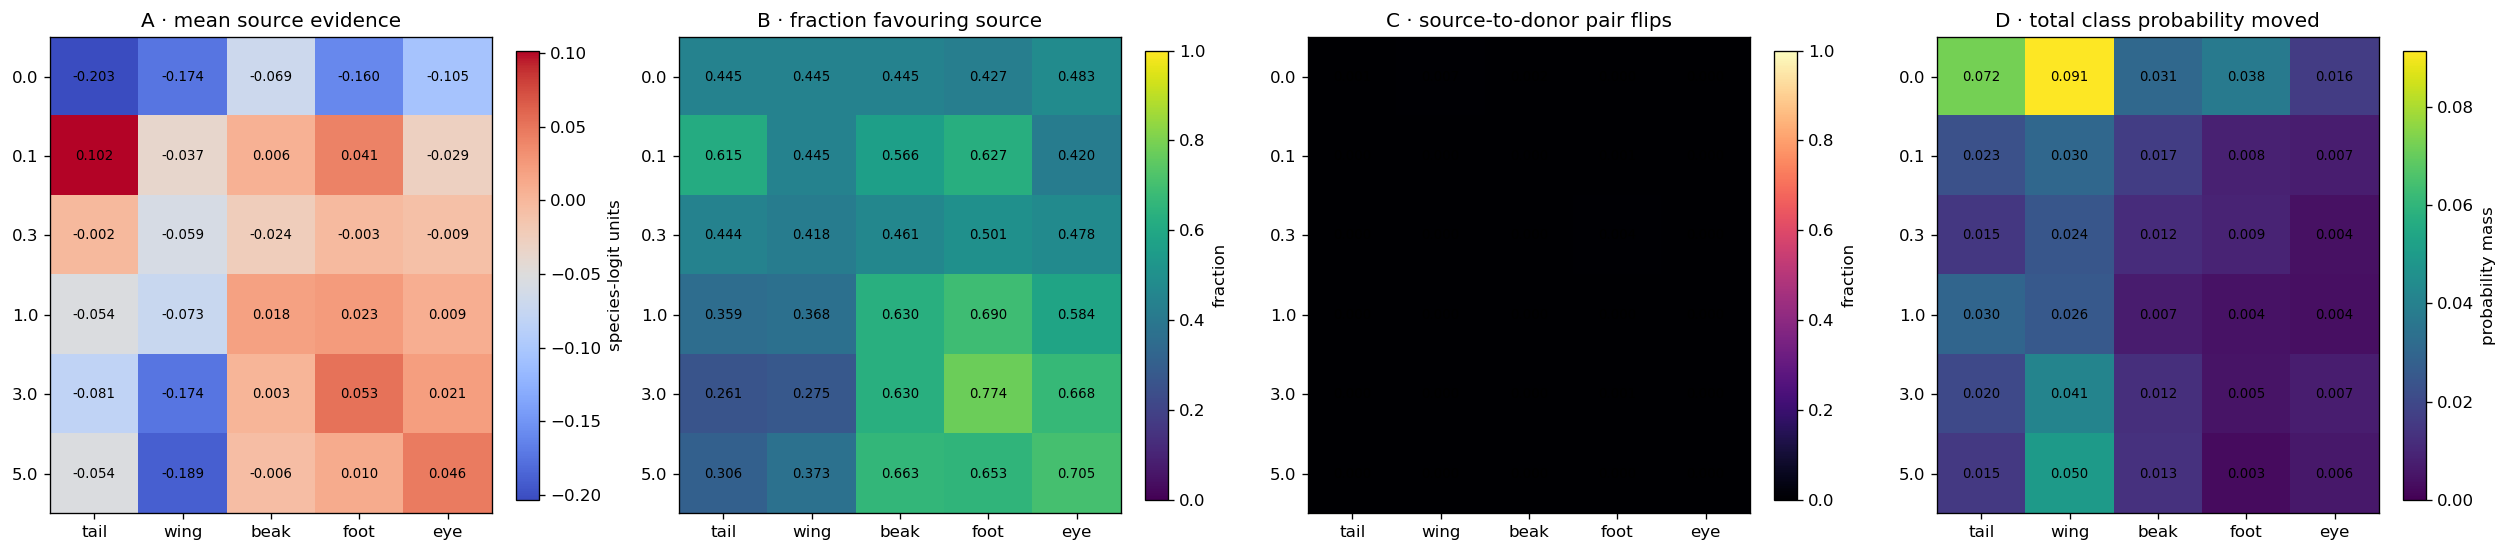

**Table — direct off-target intervention behind Panels A–D.** For each swap, old and donor coordinates stay fixed while every other coordinate of that part is restored to the matching original image. Positive source evidence means those swap-induced off-target changes had favored the source species. The pair-flip rate and all-species probability movement are different outcomes.

,gamma,part,n_rows,n_originals,mean_swap_induced_offtarget_source_evidence,median_swap_induced_offtarget_source_evidence,fraction_source_evidence_positive,pairwise_source_to_donor_flip_rate,top1_change_rate,mean_probability_mass_moved
0,0.0,beak,1000,250,-0.06897,-0.07892,0.445,0.002,0.040,0.03082
1,0.0,eye,1000,250,-0.10482,-0.00459,0.483,0.000,0.006,0.01615
2,0.0,foot,1000,250,-0.15959,-0.08264,0.427,0.000,0.054,0.03759
3,0.0,tail,1000,250,-0.20332,-0.03520,0.445,0.001,0.083,0.07228
4,0.0,wing,1000,250,-0.17358,-0.15610,0.445,0.007,0.110,0.09148
5,0.1,beak,1000,250,0.00622,0.01416,0.566,0.000,0.033,0.01651
6,0.1,eye,1000,250,-0.02919,-0.00574,0.420,0.000,0.007,0.00722
7,0.1,foot,1000,250,0.04112,0.02653,0.627,0.001,0.016,0.00823
8,0.1,tail,1000,250,0.10179,0.04118,0.615,0.000,0.032,0.02284
9,0.1,wing,1000,250,-0.03679,-0.01900,0.445,0.000,0.039,0.03045


In [22]:
metrics=[('mean_swap_induced_offtarget_source_evidence','A · mean source evidence','species-logit units',None,None,'coolwarm'),
  ('fraction_source_evidence_positive','B · fraction favouring source','fraction',0,1,'viridis'),
  ('pairwise_source_to_donor_flip_rate','C · source-to-donor pair flips','fraction',0,1,'magma'),
  ('mean_probability_mass_moved','D · total class probability moved','probability mass',0,None,'viridis')]
fig,axes=plt.subplots(1,4,figsize=(21,4.7))
for ax,(col,title,label,lo,hi,cmap) in zip(axes,metrics):
    table=HYBRID.pivot(index='gamma',columns='part',values=col).reindex(index=GAMMAS,columns=ORDER)
    heat(ax,table,title,label,lo,hi,cmap,fmt='.3f')
plt.tight_layout(); plt.show()
show_table(
  'direct off-target intervention behind Panels A–D',
  'For each swap, old and donor coordinates stay fixed while every other coordinate '
  'of that part is restored to the matching original image. Positive source evidence '
  'means those swap-induced off-target changes had favored the source species. The '
  'pair-flip rate and all-species probability movement are different outcomes.',
  HYBRID.round(5))


**How to read the executed RLv2 result.** The figure and fully
captioned source table immediately above are the result; no expected
observation was written into the notebook before execution.

**Question → test → boundary.** Compare the RLv2 output with the
executed Standard-MCBM output directly above it. A change is evidence
about visibility-aware labels only when model gamma, formula, physical
swap rows, and denominator match. It does not turn an association into
a cause, and seed 1 does not provide initialization uncertainty.

**Next question.** Continue to the next identical analysis stage, then
use the final matched-difference table to decide which part and pathway
actually changed.


## 6. What remains unexplained

The exact Standard source-species residual and grouped predictive audit are
shown first. The residual subtracts the training-fold mean for the identical
`(part, old value, donor value)` transition; it does not subtract a species
mean. Therefore transition residuals average to zero overall, while one
source species can remain systematically positive or negative.

Example: if the pooled margins for one exact transition are
`[-5,-3,+1,+3]`, their mean is `-1` and residuals are `[-4,-2,+2,+4]`.
They sum to zero, but two species can occupy opposite sides.

A predictive model may show that measured pre-outcome variables are useful;
it cannot divide backwash into additive causal percentages.


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f12-`**

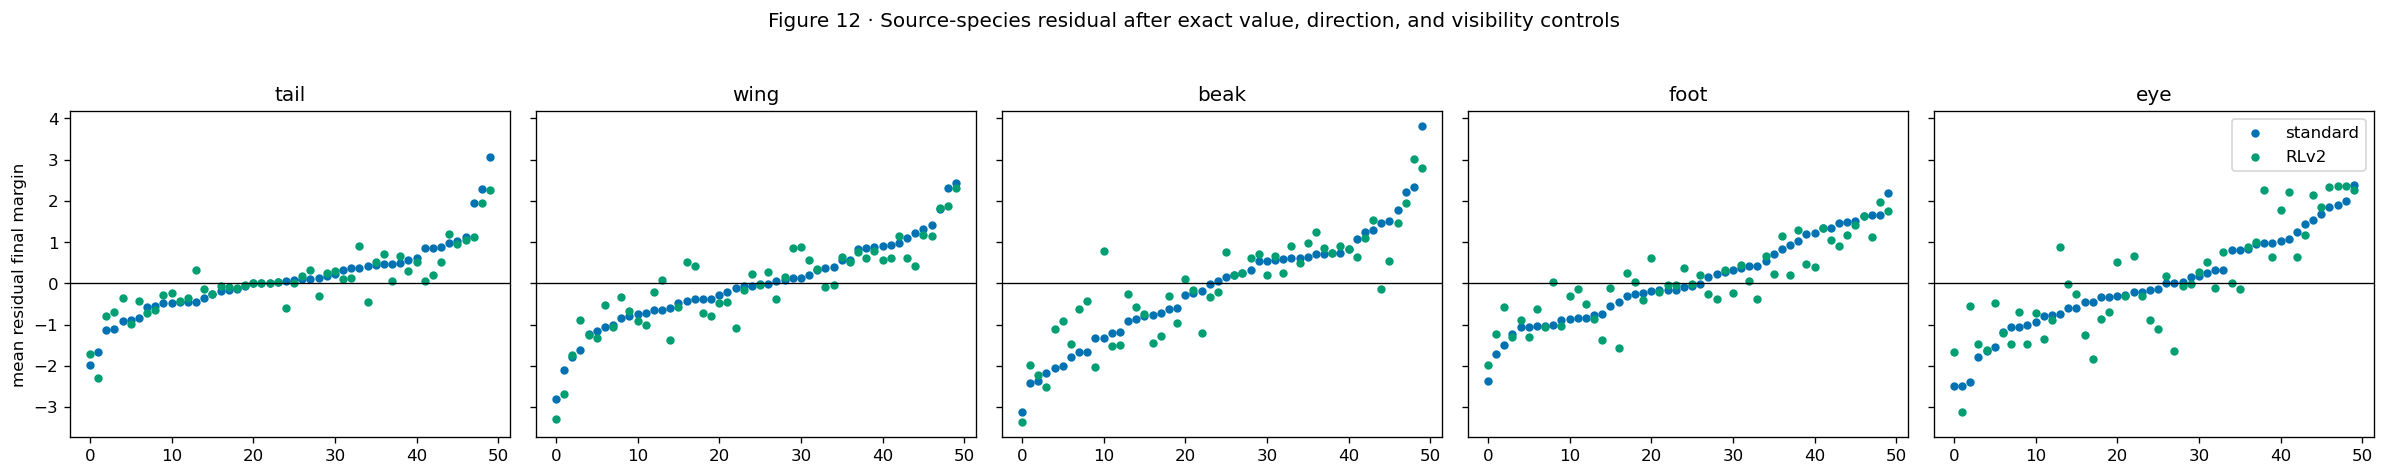

regime,RLv2,standard
part,,
tail,0.777,0.894
wing,1.071,1.054
beak,1.306,1.394
foot,0.919,1.037
eye,1.338,1.181


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f14-`**

STANDARD — identical grouped omission audit


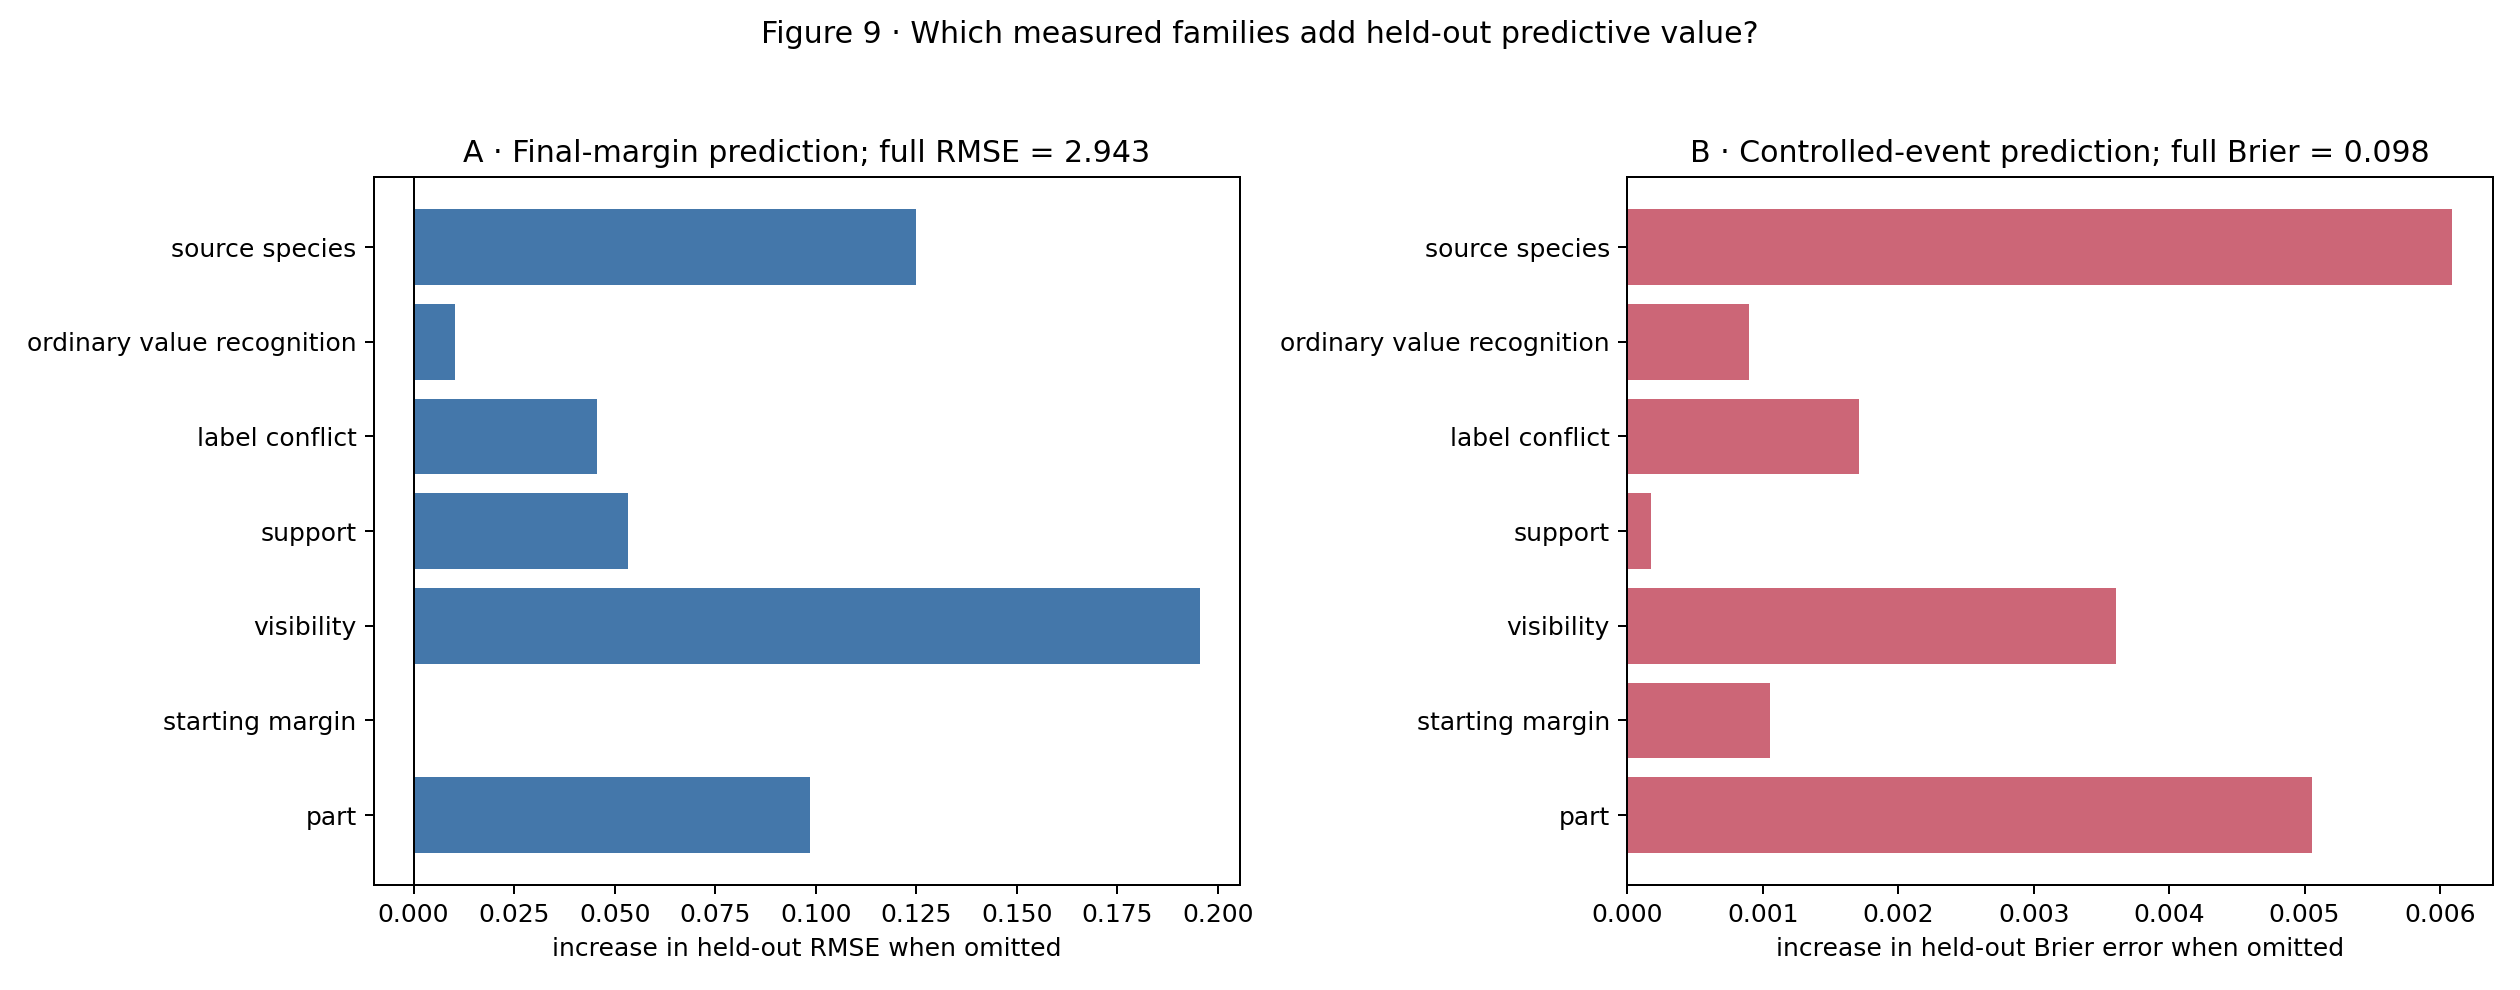

,model,numeric_features,categorical_features,margin_RMSE,margin_MAE,event_Brier
0,overall mean only,none,none,4.1629,3.2014,0.1402
1,part only,none,part,3.3273,2.5514,0.1087
2,full measured set,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",2.9432,2.2861,0.0979
3,full minus part,"m_orig, log_visible_pixels, donor_support, sou...",sid_src,3.0417,2.3698,0.1030
4,full minus starting margin,"log_visible_pixels, donor_support, source_supp...","part, sid_src",2.9432,2.2863,0.0990
5,full minus visibility,"m_orig, donor_support, source_support, donor_c...","part, sid_src",3.1389,2.4166,0.1015
6,full minus support,"m_orig, log_visible_pixels, donor_conflict, so...","part, sid_src",2.9966,2.3177,0.0981
7,full minus label conflict,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",2.9888,2.3140,0.0996
8,full minus ordinary value recognition,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",2.9535,2.2884,0.0988
9,full minus source species,"m_orig, log_visible_pixels, donor_support, sou...",part,3.0682,2.3888,0.1040


Exact-value holdout stress test


,held_out_part,held_out_donor_value,n_rows,n_originals,RMSE,MAE
0,beak,0,345,120,3.2856,2.7133
1,beak,1,245,145,2.9799,2.3228
2,beak,2,190,125,3.0489,2.2933
3,beak,3,220,135,2.5517,1.9469
4,eye,0,300,160,3.0136,2.3578
5,eye,1,345,155,2.6665,2.0149
6,eye,2,355,150,3.0236,2.4922
7,foot,0,220,145,2.6750,2.1305
8,foot,1,240,160,2.2861,1.7187
9,foot,2,290,155,2.6261,2.0692


RLV2 — identical grouped omission audit


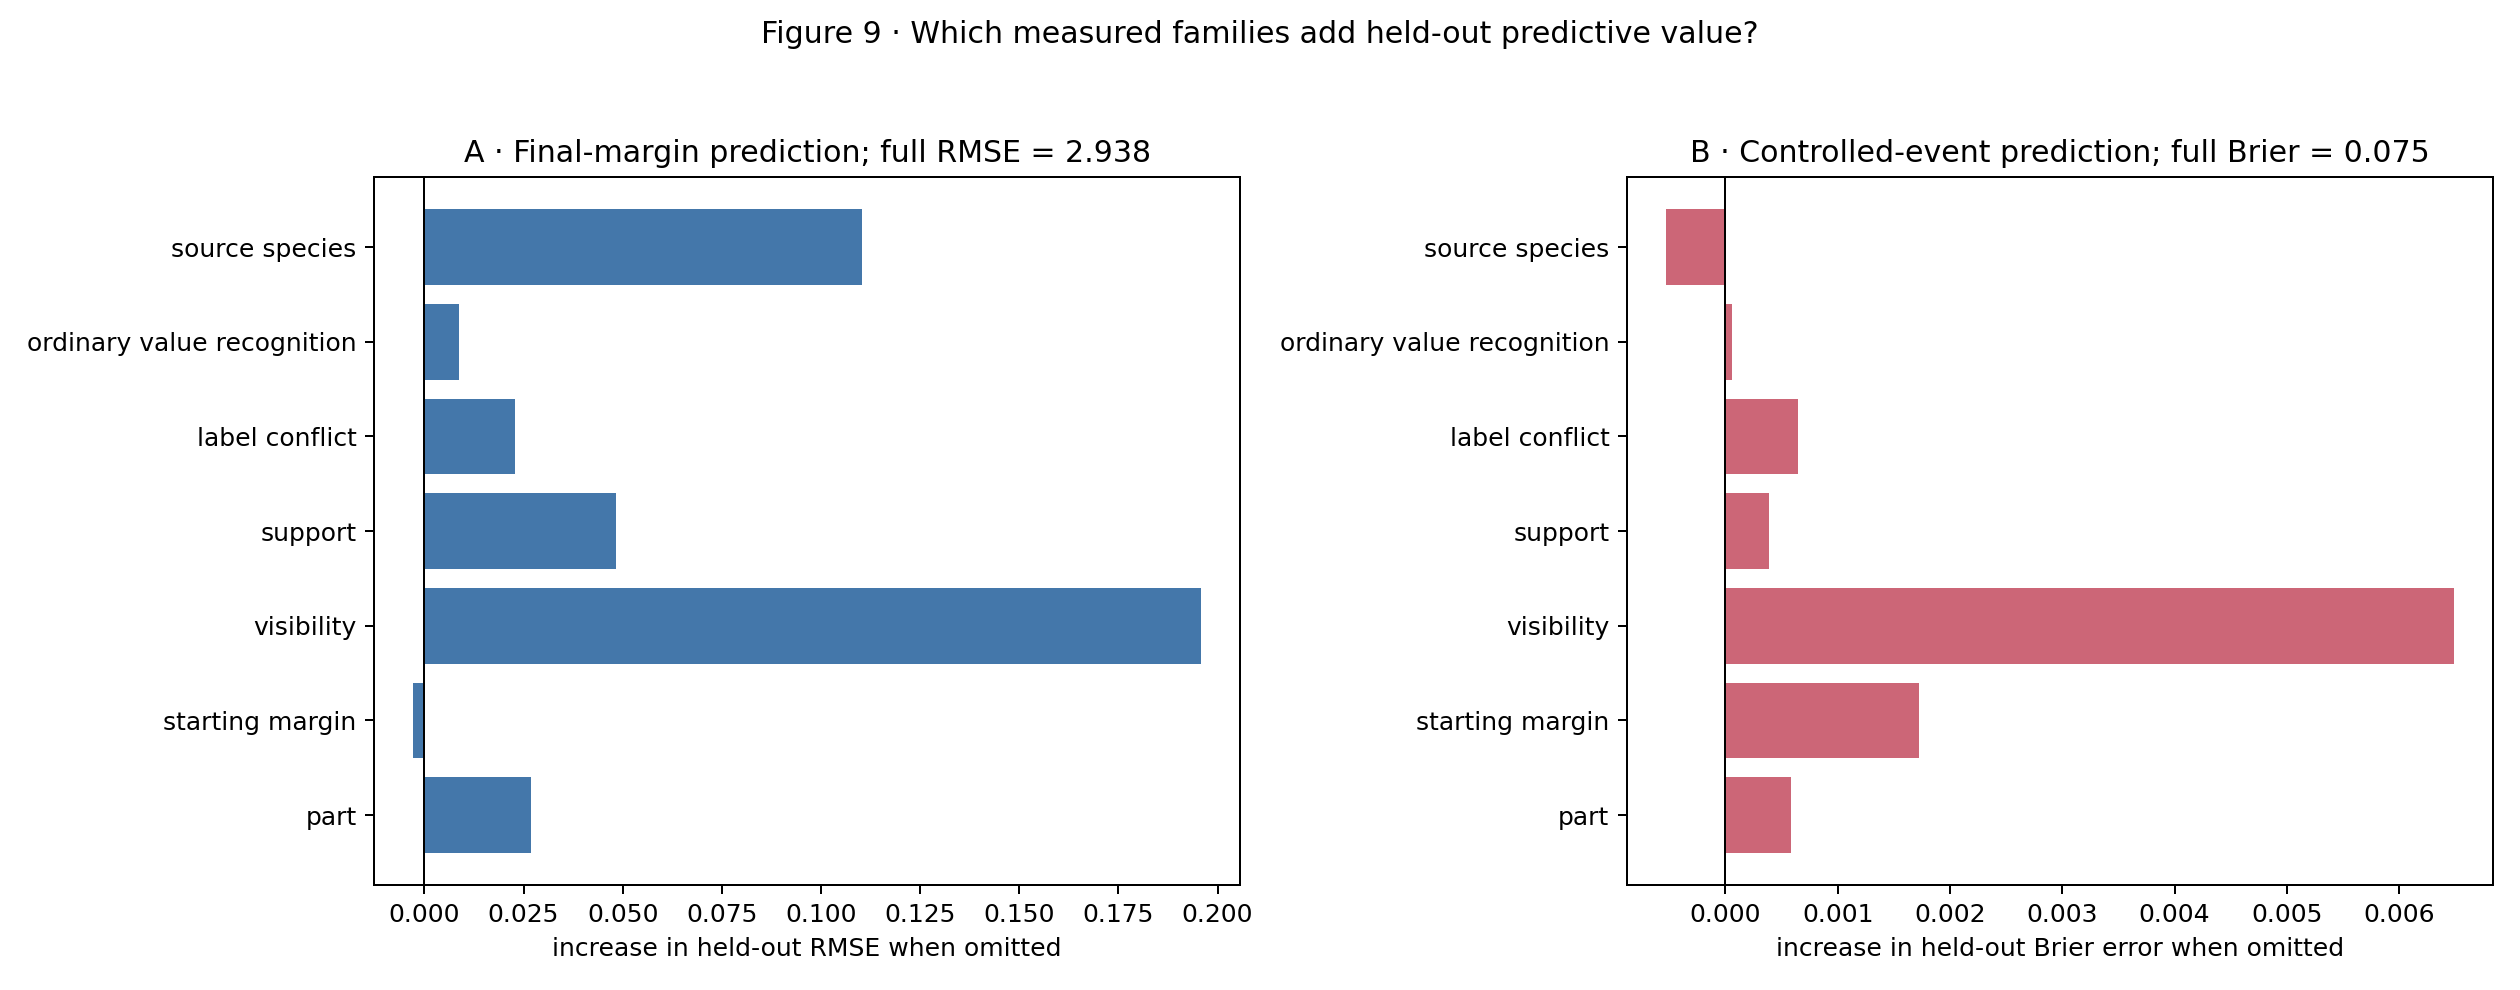

,model,numeric_features,categorical_features,margin_RMSE,margin_MAE,event_Brier
0,overall mean only,none,none,3.6395,2.7886,0.0896
1,part only,none,part,3.3002,2.5426,0.0838
2,full measured set,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",2.9375,2.2575,0.0752
3,full minus part,"m_orig, log_visible_pixels, donor_support, sou...",sid_src,2.9643,2.2845,0.0758
4,full minus starting margin,"log_visible_pixels, donor_support, source_supp...","part, sid_src",2.9348,2.2546,0.0769
5,full minus visibility,"m_orig, donor_support, source_support, donor_c...","part, sid_src",3.1333,2.3976,0.0817
6,full minus support,"m_orig, log_visible_pixels, donor_conflict, so...","part, sid_src",2.9859,2.2939,0.0756
7,full minus label conflict,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",2.9603,2.2815,0.0759
8,full minus ordinary value recognition,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",2.9462,2.2644,0.0753
9,full minus source species,"m_orig, log_visible_pixels, donor_support, sou...",part,3.0478,2.3509,0.0747


Exact-value holdout stress test


,held_out_part,held_out_donor_value,n_rows,n_originals,RMSE,MAE
0,beak,0,345,120,3.0940,2.4690
1,beak,1,245,145,2.9771,2.2186
2,beak,2,190,125,3.3818,2.5886
3,beak,3,220,135,2.5957,1.8833
4,eye,0,300,160,2.7532,2.0904
5,eye,1,345,155,3.2022,2.5067
6,eye,2,355,150,3.4651,2.7811
7,foot,0,220,145,3.2202,2.6919
8,foot,1,240,160,2.3666,1.8452
9,foot,2,290,155,2.8195,2.2408


In [23]:
show_standard('f8','f9-new')


### Executed Standard-MCBM result — mcbm-residual

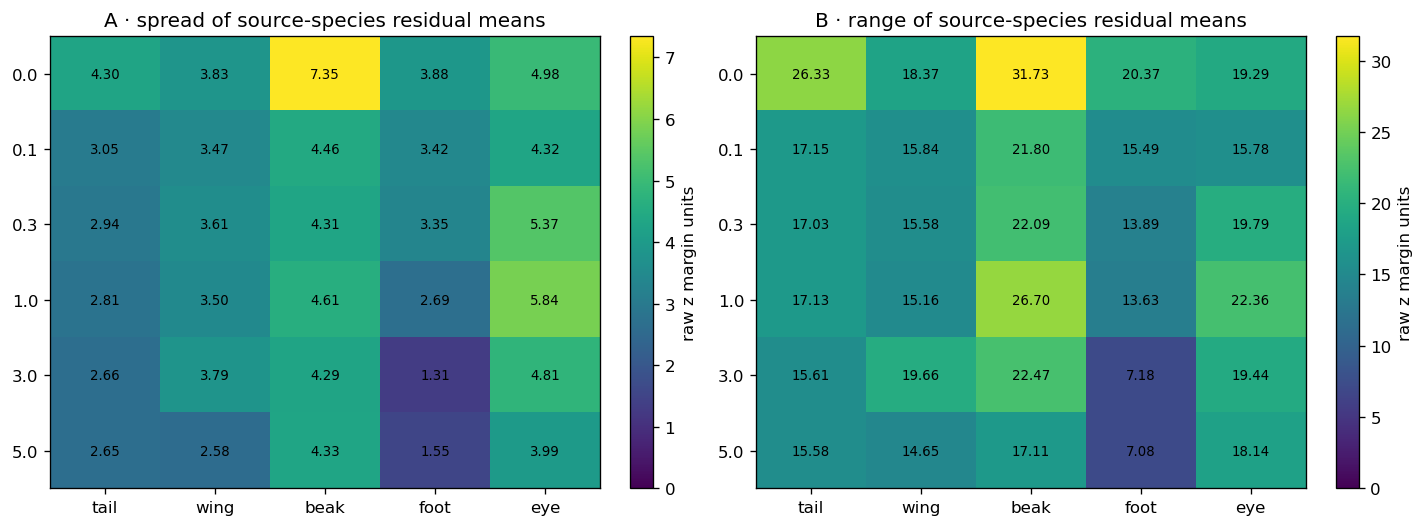

**Table — source-species residual spread behind Panels A–B.** First subtract the mean final margin for the same part, old value, and donor value. Then average the remaining residual by source species. SD and range are in raw donor-minus-source concept-logit units.

,gamma,part,n_rows,n_species,species_residual_SD,species_residual_range
0,0.0,beak,1000,50,7.3472,31.7267
1,0.0,eye,1000,50,4.9793,19.2857
2,0.0,foot,1000,50,3.8839,20.3724
3,0.0,tail,1000,50,4.2974,26.3278
4,0.0,wing,1000,50,3.8349,18.3698
5,0.1,beak,1000,50,4.4564,21.8042
6,0.1,eye,1000,50,4.3171,15.7831
7,0.1,foot,1000,50,3.4167,15.4855
8,0.1,tail,1000,50,3.0542,17.1472
9,0.1,wing,1000,50,3.4681,15.8363


**Grouped held-out measured-contributor models**

**Table — grouped held-out measured-contributor models.** RMSE and MAE are prediction errors for the final raw concept margin; lower is better. Event Brier is squared probability error for the controlled backwash predicate; lower is better. Original images remain together across folds.

,model,numeric_features,categorical_features,margin_RMSE,margin_MAE,event_Brier,gamma
0,overall mean only,none,none,12.5775,10.4255,0.2196,0.0
1,part only,none,part,10.9135,8.6328,0.1868,0.0
2,full measured set,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",9.6602,7.6140,0.1643,0.0
3,full minus part,"m_orig, log_visible_pixels, donor_support, sou...",sid_src,9.8949,7.8676,0.1729,0.0
4,full minus starting margin,"log_visible_pixels, donor_support, source_supp...","part, sid_src",9.8029,7.6655,0.1665,0.0
5,full minus visibility,"m_orig, donor_support, source_support, donor_c...","part, sid_src",10.1720,8.0267,0.1664,0.0
6,full minus support,"m_orig, log_visible_pixels, donor_conflict, so...","part, sid_src",9.6970,7.6264,0.1654,0.0
7,full minus label conflict,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",9.7051,7.6483,0.1649,0.0
8,full minus ordinary value recognition,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",9.8263,7.7495,0.1704,0.0
9,full minus source species,"m_orig, log_visible_pixels, donor_support, sou...",part,10.0076,7.9221,0.1740,0.0


**Leave-one-donor-value-out stress test**

**Table — leave-one-inserted-value-out stress test.** The model is fitted without one donor value and tested only on that unseen value. RMSE and MAE are final-margin errors in raw-logit units. This tests transfer, not fit to familiar values.

,held_out_part,held_out_donor_value,n_rows,n_originals,RMSE,MAE,gamma
0,beak,0,345,120,11.5352,9.0825,0.0
1,beak,1,245,145,12.0474,9.4549,0.0
2,beak,2,190,125,12.2067,10.3593,0.0
3,beak,3,220,135,11.9332,10.4869,0.0
4,eye,0,300,160,13.7928,11.4516,0.0
5,eye,1,345,155,12.9808,10.7033,0.0
6,eye,2,355,150,11.4845,9.4389,0.0
7,foot,0,220,145,9.2700,7.9003,0.0
8,foot,1,240,160,9.1197,7.4490,0.0
9,foot,2,290,155,5.9908,4.7399,0.0


In [24]:
show_standard_mcbm('mcbm-residual')


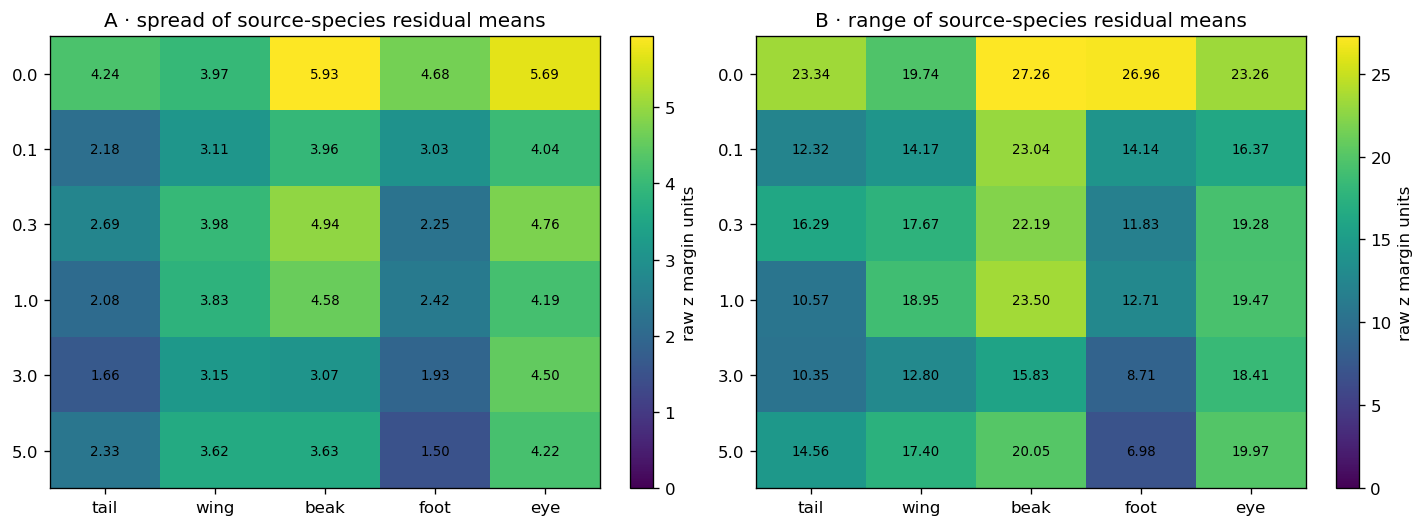

**Table — source-species residual spread behind Panels A–B.** First subtract the mean final margin for the same part, old value, and donor value. Then average the remaining residual by source species. SD and range are in raw donor-minus-source concept-logit units.

,gamma,part,n_rows,n_species,species_residual_SD,species_residual_range
0,0.0,beak,1000,50,5.9332,27.2627
1,0.0,eye,1000,50,5.6921,23.2591
2,0.0,foot,1000,50,4.6848,26.9646
3,0.0,tail,1000,50,4.2427,23.3394
4,0.0,wing,1000,50,3.9743,19.7373
5,0.1,beak,1000,50,3.9604,23.0356
6,0.1,eye,1000,50,4.0412,16.3744
7,0.1,foot,1000,50,3.0301,14.1418
8,0.1,tail,1000,50,2.1753,12.3206
9,0.1,wing,1000,50,3.1141,14.1737


**Grouped held-out measured-contributor models**

**Table — grouped held-out measured-contributor models.** RMSE and MAE are prediction errors for the final raw concept margin; lower is better. Event Brier is squared probability error for the controlled backwash predicate; lower is better. Original images remain together across folds.

,model,numeric_features,categorical_features,margin_RMSE,margin_MAE,event_Brier,gamma
0,overall mean only,none,none,12.8561,10.5348,0.2173,0.0
1,part only,none,part,11.0499,8.6877,0.1870,0.0
2,full measured set,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",9.9900,7.8180,0.1705,0.0
3,full minus part,"m_orig, log_visible_pixels, donor_support, sou...",sid_src,10.5350,8.3329,0.1831,0.0
4,full minus starting margin,"log_visible_pixels, donor_support, source_supp...","part, sid_src",10.2767,8.0268,0.1783,0.0
5,full minus visibility,"m_orig, donor_support, source_support, donor_c...","part, sid_src",10.4457,8.2204,0.1771,0.0
6,full minus support,"m_orig, log_visible_pixels, donor_conflict, so...","part, sid_src",10.0183,7.8404,0.1705,0.0
7,full minus label conflict,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",10.0854,7.8994,0.1715,0.0
8,full minus ordinary value recognition,"m_orig, log_visible_pixels, donor_support, sou...","part, sid_src",9.9868,7.8087,0.1704,0.0
9,full minus source species,"m_orig, log_visible_pixels, donor_support, sou...",part,10.2432,8.0523,0.1735,0.0


**Leave-one-donor-value-out stress test**

**Table — leave-one-inserted-value-out stress test.** The model is fitted without one donor value and tested only on that unseen value. RMSE and MAE are final-margin errors in raw-logit units. This tests transfer, not fit to familiar values.

,held_out_part,held_out_donor_value,n_rows,n_originals,RMSE,MAE,gamma
0,beak,0,345,120,11.5311,9.4184,0.0
1,beak,1,245,145,11.2248,8.9998,0.0
2,beak,2,190,125,13.3123,10.8362,0.0
3,beak,3,220,135,10.3701,8.8917,0.0
4,eye,0,300,160,9.1649,7.2660,0.0
5,eye,1,345,155,9.7705,7.7802,0.0
6,eye,2,355,150,10.2114,8.3193,0.0
7,foot,0,220,145,8.3290,6.4753,0.0
8,foot,1,240,160,12.7293,10.1745,0.0
9,foot,2,290,155,8.9378,7.3122,0.0


In [25]:
residual_rows=[]
for g,d in MCBM.items():
    q=d.copy()
    keys=['part','var_src','var_donor']
    q['pair_mean']=q.groupby(keys).m_cf.transform('mean')
    q['pair_residual']=q.m_cf-q.pair_mean
    for part,p in q.groupby('part'):
        species=p.groupby('sid_src').pair_residual.mean()
        residual_rows.append(dict(gamma=g,part=part,n_rows=len(p),n_species=len(species),
          species_residual_SD=species.std(ddof=0),species_residual_range=species.max()-species.min()))
RESIDUAL=pd.DataFrame(residual_rows)
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
for ax,col,title in [(axes[0],'species_residual_SD','A · spread of source-species residual means'),
                     (axes[1],'species_residual_range','B · range of source-species residual means')]:
    table=RESIDUAL.pivot(index='gamma',columns='part',values=col).reindex(index=GAMMAS,columns=ORDER)
    heat(ax,table,title,'raw z margin units',0,None,'viridis')
plt.tight_layout(); plt.show()
show_table(
  'source-species residual spread behind Panels A–B',
  'First subtract the mean final margin for the same part, old value, and donor '
  'value. Then average the remaining residual by source species. SD and range are '
  'in raw donor-minus-source concept-logit units.', RESIDUAL.round(4))

predictive=[]
holdout=[]
for g in GAMMAS:
    path=TABLES/f'{TAG[g]}_PREDICTIVE.csv'
    value_path=TABLES/f'{TAG[g]}_VALUE_HOLDOUT.csv'
    q=pd.read_csv(path); q['gamma']=g; predictive.append(q)
    q=pd.read_csv(value_path); q['gamma']=g; holdout.append(q)
PREDICTIVE=pd.concat(predictive,ignore_index=True)
VALUE_HOLDOUT=pd.concat(holdout,ignore_index=True)
display(Markdown('**Grouped held-out measured-contributor models**'))
show_table(
  'grouped held-out measured-contributor models',
  'RMSE and MAE are prediction errors for the final raw concept margin; lower is '
  'better. Event Brier is squared probability error for the controlled backwash '
  'predicate; lower is better. Original images remain together across folds.',
  PREDICTIVE.round(4))
display(Markdown('**Leave-one-donor-value-out stress test**'))
show_table(
  'leave-one-inserted-value-out stress test',
  'The model is fitted without one donor value and tested only on that unseen value. '
  'RMSE and MAE are final-margin errors in raw-logit units. This tests transfer, not '
  'fit to familiar values.', VALUE_HOLDOUT.round(4))


**How to read the executed RLv2 result.** The figure and fully
captioned source table immediately above are the result; no expected
observation was written into the notebook before execution.

**Question → test → boundary.** Compare the RLv2 output with the
executed Standard-MCBM output directly above it. A change is evidence
about visibility-aware labels only when model gamma, formula, physical
swap rows, and denominator match. It does not turn an association into
a cause, and seed 1 does not provide initialization uncertainty.

**Next question.** Continue to the next identical analysis stage, then
use the final matched-difference table to decide which part and pathway
actually changed.


## 7. Downstream species consequence

**Question.** When the inserted concept value becomes more favored, does the
frozen classifier assign more probability to the donor species?

**Quantity.** Swaps are divided into ten approximately equal-count bins by
final raw concept margin `m_cf`. For each bin, x is mean `m_cf`; y is mean
saved donor-species probability. This reuses each model's original saved
classifier. No new classifier is trained.

The Standard Figure 10 appears first. MCBM is then plotted with the same
construction. This is an association downstream of concept scores; it cannot
establish that the species head caused backwash.


**Exact executed Koh Standard/RLv2 comparison — Notebook 02rl `02rl-f15-`**

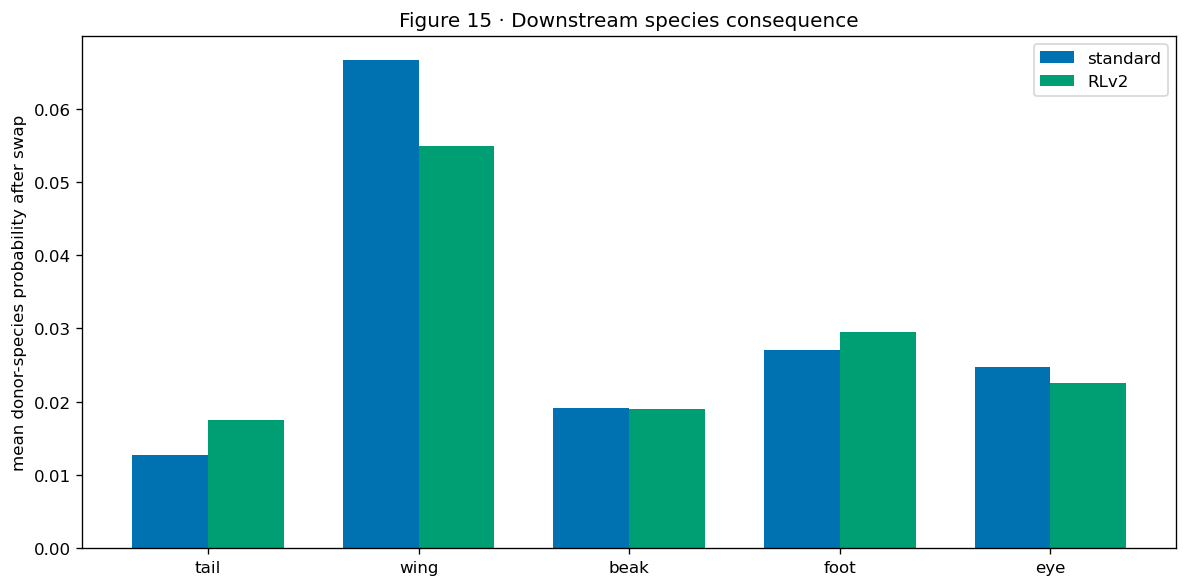

,standard,RLv2,paired_change
part,,,
tail,0.0127,0.0175,0.0047
wing,0.0666,0.0550,-0.0116
beak,0.0192,0.0190,-0.0002
foot,0.0270,0.0295,0.0025
eye,0.0247,0.0225,-0.0022


In [26]:
show_standard('f10')


### Executed Standard-MCBM result — mcbm-downstream

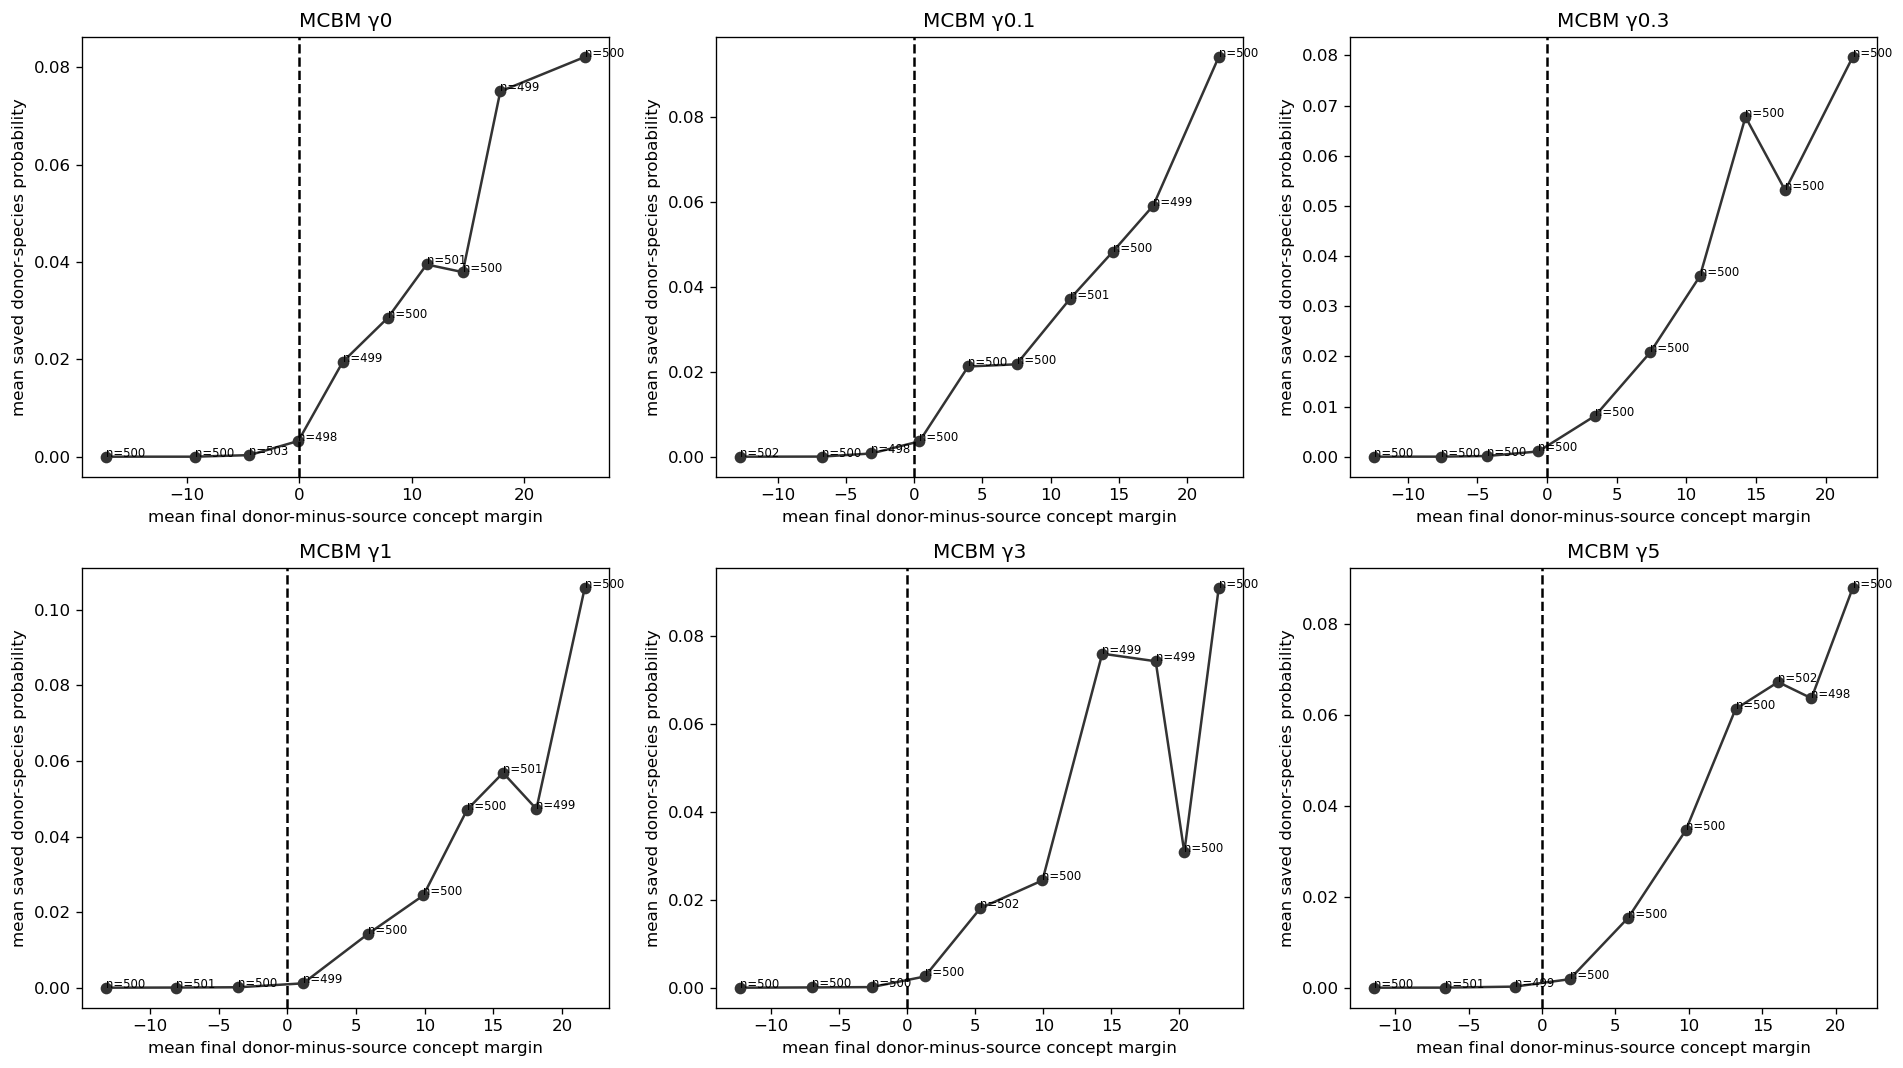

**Table — ten-bin downstream values behind the six panels.** Rows are approximately equal-count final-margin bins. `mean_margin` is the mean inserted-minus-old concept logit; `mean_donor_probability` is the unchanged saved species head’s probability for the exact donor species.

,n,mean_margin,mean_donor_probability,gamma
0,500,-17.15323,0.00000,0.0
1,500,-9.30134,0.00000,0.0
2,503,-4.43607,0.00032,0.0
3,498,-0.09306,0.00323,0.0
4,499,3.86243,0.01951,0.0
5,500,7.85834,0.02853,0.0
6,501,11.31595,0.03950,0.0
7,500,14.51981,0.03793,0.0
8,499,17.85564,0.07505,0.0
9,500,25.35996,0.08214,0.0


In [27]:
show_standard_mcbm('mcbm-downstream')


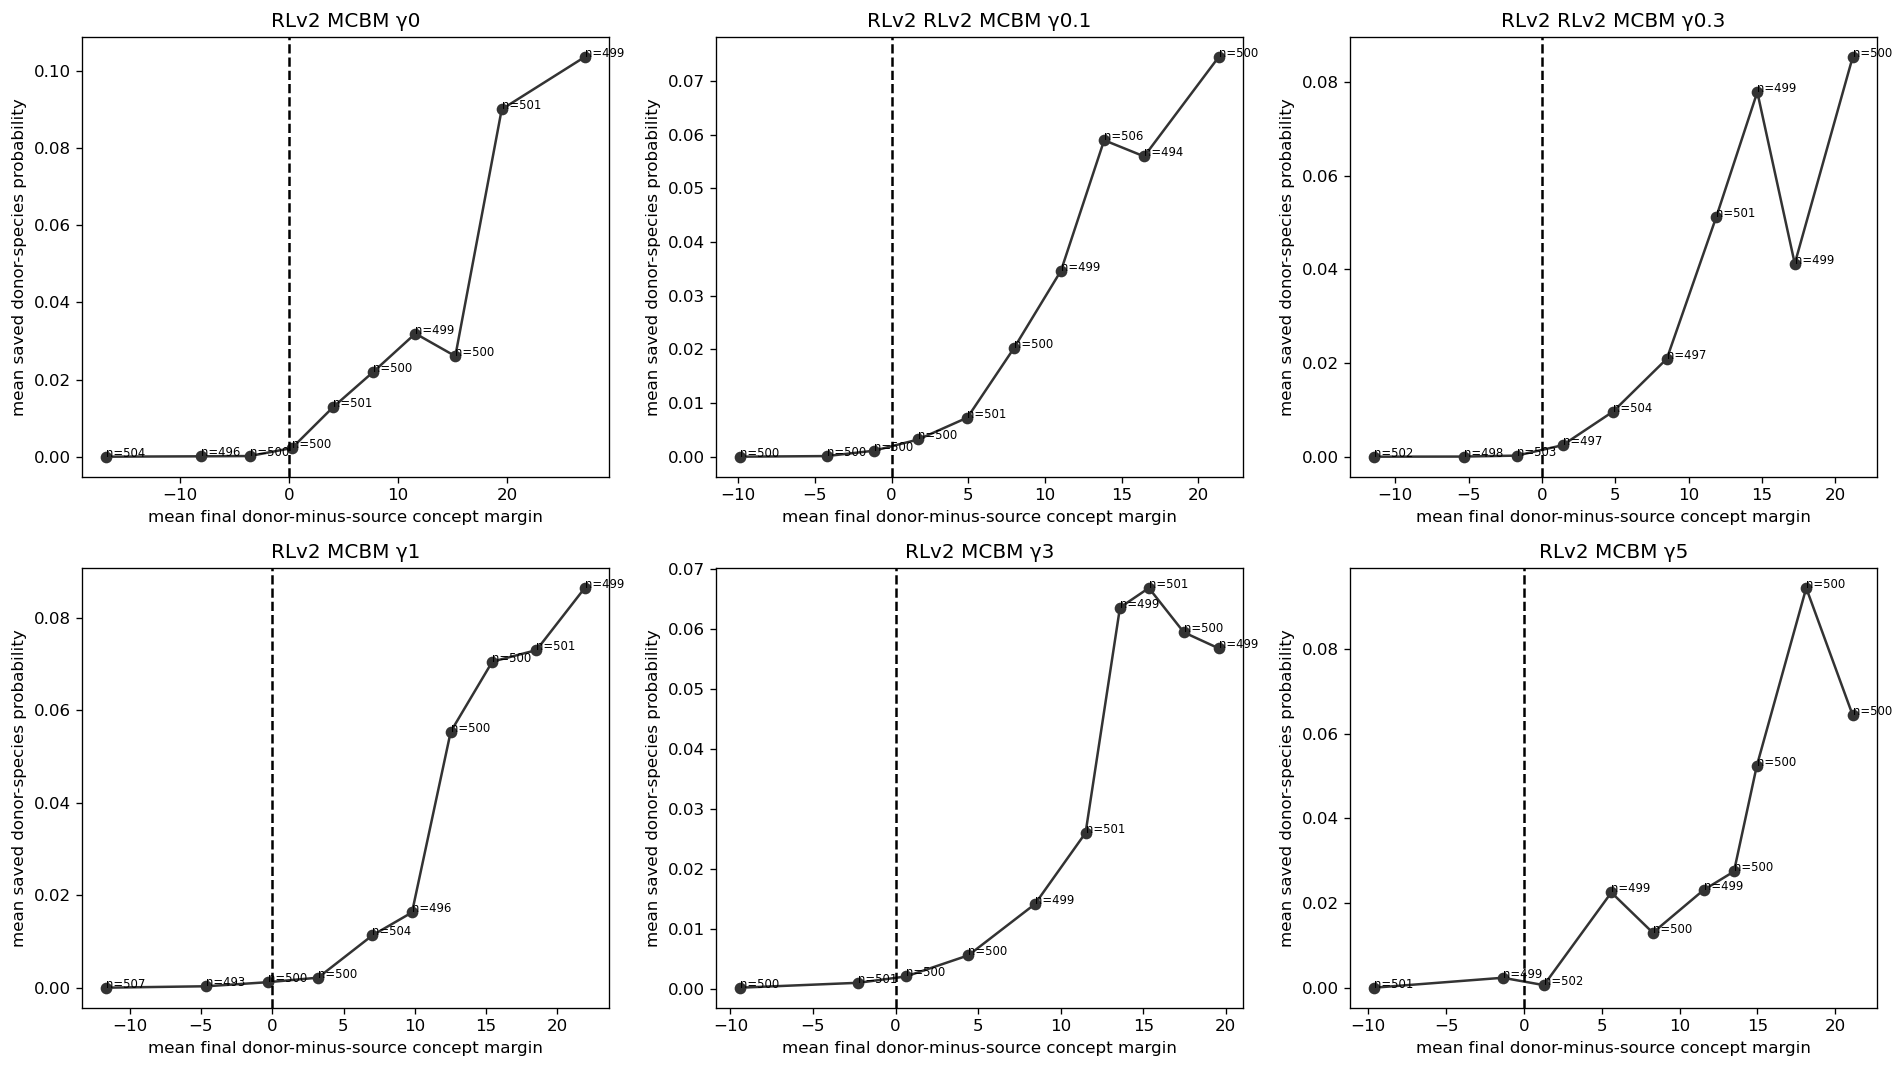

**Table — ten-bin downstream values behind the six panels.** Rows are approximately equal-count final-margin bins. `mean_margin` is the mean inserted-minus-old concept logit; `mean_donor_probability` is the unchanged saved species head’s probability for the exact donor species.

,n,mean_margin,mean_donor_probability,gamma
0,504,-16.71339,0.00000,0.0
1,496,-8.08435,0.00010,0.0
2,500,-3.59135,0.00017,0.0
3,500,0.28963,0.00223,0.0
4,501,4.04470,0.01280,0.0
5,500,7.74565,0.02199,0.0
6,499,11.60032,0.03192,0.0
7,500,15.25929,0.02605,0.0
8,501,19.51198,0.09004,0.0
9,499,27.11749,0.10361,0.0


In [28]:
fig,axes=plt.subplots(2,3,figsize=(16,9)); downstream=[]
for ax,g in zip(axes.flat,GAMMAS):
    d=MCBM[g]; prob=next((c for c in ['p_cf_donor','p_donor_cf','donor_species_prob'] if c in d),None)
    if prob is None:
        ax.text(.5,.5,'donor-species probability absent',ha='center'); ax.axis('off'); continue
    bins=pd.qcut(d.m_cf,10,duplicates='drop')
    q=d.groupby(bins,observed=True).agg(n=('m_cf','size'),mean_margin=('m_cf','mean'),mean_donor_probability=(prob,'mean')).reset_index(drop=True)
    q['gamma']=g; downstream.append(q)
    ax.plot(q.mean_margin,q.mean_donor_probability,'o-',color='#333333'); ax.axvline(0,color='black',ls='--')
    ax.set_title(LABELS[g]); ax.set_xlabel('mean final donor-minus-source concept margin'); ax.set_ylabel('mean saved donor-species probability')
    for row in q.itertuples(): ax.annotate(f'n={row.n}',(row.mean_margin,row.mean_donor_probability),fontsize=7)
plt.tight_layout(); plt.show()
if downstream:
    show_table(
      'ten-bin downstream values behind the six panels',
      'Rows are approximately equal-count final-margin bins. `mean_margin` is the '
      'mean inserted-minus-old concept logit; `mean_donor_probability` is the '
      'unchanged saved species head’s probability for the exact donor species.',
      pd.concat(downstream,ignore_index=True).round(5))


**How to read the executed RLv2 result.** The figure and fully
captioned source table immediately above are the result; no expected
observation was written into the notebook before execution.

**Question → test → boundary.** Compare the RLv2 output with the
executed Standard-MCBM output directly above it. A change is evidence
about visibility-aware labels only when model gamma, formula, physical
swap rows, and denominator match. It does not turn an association into
a cause, and seed 1 does not provide initialization uncertainty.

**Next question.** Continue to the next identical analysis stage, then
use the final matched-difference table to decide which part and pathway
actually changed.


## 8. All-fronts synthesis and loss recommendation

This table is deliberately complete rather than tail-centered. For every
model and part it prints the starting margin, donor rise, source fall, total
response, final margin, exact donor/source/third winner rates, no-movement
rate, and controlled-backwash rate. MCBM rows then join calibrated `h`
response, `q` break/repair, ordinary health, and the direct off-target
intervention.

Read it in this order for each part:

1. Did Koh→gamma 0 change the behavior before any minimality pressure?
2. Is gamma's dose trend smooth, non-monotonic, or flat?
3. Is the changed outcome explained by starting deficit, donor rise, source
   fall, or a third exact value?
4. Is the loss already present in calibrated `h`, or introduced by `q`?
5. Do visibility/conflict/support track the matching component?
6. Does the saved-head intervention causally move the source/donor species
   decision enough to explain it?


In [29]:
show_standard_mcbm('final-table')


### Executed Standard-MCBM result — final-table

**Table — Complete result rows — tail.** `m_orig` is the starting donor-minus-old margin; donor gain plus source decrease equals response; adding response to `m_orig` gives `m_cf`. Rates use all 1,000 matched swaps per model/part. The later columns localize movement in calibrated `h`, reader break/repair, health, and the frozen-head off-target intervention.

,model,part,n,m_orig,donor_gain,source_decrease,response,m_cf,exact_donor,exact_source,exact_third,no_move,backwash,gamma,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate,balanced_accuracy,h_target_RMSE,mean_swap_induced_offtarget_source_evidence,pairwise_source_to_donor_flip_rate
3,Koh Standard,tail,1000,-10.7561,4.5992,5.2012,9.8004,-0.9557,0.395,0.538,0.067,0.075,0.508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,MCBM γ0,tail,1000,-21.2911,6.5584,11.6452,18.2036,-3.0875,0.278,0.470,0.252,0.106,0.522,0.0,0.7978,0.054,0.113,0.9592,24.3984,0.3299,0.003
13,MCBM γ0.1,tail,1000,-15.4800,4.3278,6.0593,10.3871,-5.0928,0.195,0.716,0.089,0.097,0.672,0.1,0.7175,0.011,0.009,0.9813,1.4667,-0.2078,0.001
18,MCBM γ0.3,tail,1000,-14.0996,2.6939,5.0158,7.7097,-6.3899,0.109,0.804,0.087,0.073,0.790,0.3,0.6026,0.003,0.008,0.9804,0.7191,-0.1984,0.000
23,MCBM γ1,tail,1000,-12.7580,2.8447,5.5165,8.3612,-4.3968,0.202,0.702,0.096,0.077,0.682,1.0,0.7297,0.003,0.003,0.9771,0.5964,-0.0831,0.000
28,MCBM γ3,tail,1000,-11.7821,1.4226,5.3830,6.8056,-4.9765,0.142,0.753,0.105,0.125,0.689,3.0,0.6282,0.001,0.004,0.9793,0.5215,-0.0446,0.000
33,MCBM γ5,tail,1000,-11.7315,1.4495,4.8222,6.2717,-5.4599,0.135,0.779,0.086,0.097,0.739,5.0,0.6005,0.003,0.015,0.9763,0.5400,-0.0125,0.000


**Table — Complete result rows — wing.** `m_orig` is the starting donor-minus-old margin; donor gain plus source decrease equals response; adding response to `m_orig` gives `m_cf`. Rates use all 1,000 matched swaps per model/part. The later columns localize movement in calibrated `h`, reader break/repair, health, and the frozen-head off-target intervention.

,model,part,n,m_orig,donor_gain,source_decrease,response,m_cf,exact_donor,exact_source,exact_third,no_move,backwash,gamma,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate,balanced_accuracy,h_target_RMSE,mean_swap_induced_offtarget_source_evidence,pairwise_source_to_donor_flip_rate
4,Koh Standard,wing,1000,-9.9140,8.0287,8.3609,16.3897,6.4757,0.977,0.016,0.007,0.000,0.019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,MCBM γ0,wing,1000,-27.7178,16.7892,22.1925,38.9817,11.2639,0.811,0.116,0.073,0.000,0.143,0.0,1.4721,0.013,0.007,0.9991,14.9701,-0.6636,0.002
14,MCBM γ0.1,wing,1000,-23.5205,15.9988,20.0924,36.0912,12.5707,0.881,0.082,0.037,0.001,0.092,0.1,1.4894,0.013,0.006,0.9993,2.0694,0.0016,0.003
19,MCBM γ0.3,wing,1000,-22.9600,16.4823,18.0984,34.5807,11.6207,0.870,0.099,0.031,0.000,0.108,0.3,1.4508,0.000,0.003,0.9988,0.3377,0.0102,0.000
24,MCBM γ1,wing,1000,-22.5123,15.8419,19.4856,35.3274,12.8152,0.846,0.097,0.057,0.006,0.100,1.0,1.5519,0.000,0.003,0.9994,0.2644,-0.0758,0.002
29,MCBM γ3,wing,1000,-21.5626,15.4134,18.9733,34.3867,12.8241,0.819,0.093,0.088,0.003,0.101,3.0,1.5785,0.002,0.005,0.9992,0.1809,-0.1542,0.000
34,MCBM γ5,wing,1000,-20.3061,15.2728,18.3901,33.6629,13.3567,0.832,0.095,0.073,0.002,0.097,5.0,1.6384,0.002,0.000,0.9982,0.1915,-0.1815,0.000


...

,model,part,n,m_orig,donor_gain,source_decrease,response,m_cf,exact_donor,exact_source,exact_third,no_move,backwash,gamma,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate,balanced_accuracy,h_target_RMSE,mean_swap_induced_offtarget_source_evidence,pairwise_source_to_donor_flip_rate
0,Koh Standard,beak,1000,-9.1671,5.8423,5.9361,11.7784,2.6114,0.780,0.203,0.017,0.011,0.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,MCBM γ0,beak,1000,-26.2761,15.6625,14.3049,29.9675,3.6913,0.550,0.405,0.045,0.010,0.416,0.0,1.6694,0.157,0.143,0.9946,19.4420,-0.2524,0.0
10,MCBM γ0.1,beak,1000,-19.0454,10.0847,10.5177,20.6024,1.5570,0.562,0.418,0.020,0.002,0.418,0.1,1.0731,0.018,0.007,0.9960,0.6150,0.0336,0.0
15,MCBM γ0.3,beak,1000,-18.4562,10.5246,9.8027,20.3273,1.8712,0.550,0.418,0.032,0.002,0.421,0.3,1.0988,0.014,0.009,0.9961,0.4089,0.0105,0.0
20,MCBM γ1,beak,1000,-16.3939,10.2733,11.6800,21.9533,5.5594,0.750,0.232,0.018,0.015,0.220,1.0,1.2956,0.014,0.004,0.9966,0.3485,-0.0004,0.0
25,MCBM γ3,beak,1000,-15.4492,9.2762,11.7540,21.0301,5.5809,0.756,0.229,0.015,0.005,0.228,3.0,1.2951,0.003,0.008,0.9958,0.3207,-0.0054,0.0
30,MCBM γ5,beak,1000,-16.1050,8.4892,12.2307,20.7199,4.6148,0.694,0.262,0.044,0.004,0.270,5.0,1.2615,0.012,0.004,0.9955,0.3294,-0.0099,0.0


**Table — Complete result rows — foot.** `m_orig` is the starting donor-minus-old margin; donor gain plus source decrease equals response; adding response to `m_orig` gives `m_cf`. Rates use all 1,000 matched swaps per model/part. The later columns localize movement in calibrated `h`, reader break/repair, health, and the frozen-head off-target intervention.

,model,part,n,m_orig,donor_gain,source_decrease,response,m_cf,exact_donor,exact_source,exact_third,no_move,backwash,gamma,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate,balanced_accuracy,h_target_RMSE,mean_swap_induced_offtarget_source_evidence,pairwise_source_to_donor_flip_rate
2,Koh Standard,foot,1000,-8.8470,6.8042,7.0272,13.8314,4.9843,0.965,0.033,0.002,0.003,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,MCBM γ0,foot,1000,-27.3011,19.2409,21.1721,40.4130,13.1119,0.926,0.069,0.005,0.001,0.070,0.0,1.5296,0.010,0.008,0.9985,12.3800,-0.2127,0.002
12,MCBM γ0.1,foot,1000,-24.8221,19.2119,21.7348,40.9467,16.1246,0.978,0.021,0.001,0.003,0.019,0.1,1.5739,0.000,0.000,0.9991,0.5399,0.0424,0.001
17,MCBM γ0.3,foot,1000,-23.7720,17.7256,21.5504,39.2760,15.5040,0.958,0.041,0.001,0.000,0.041,0.3,1.5795,0.000,0.000,0.9990,0.3524,0.0235,0.000
22,MCBM γ1,foot,1000,-20.3204,17.6330,18.1752,35.8082,15.4878,0.942,0.047,0.011,0.004,0.045,1.0,1.7087,0.003,0.000,0.9979,0.2597,-0.0095,0.000
27,MCBM γ3,foot,1000,-21.7110,21.0363,21.1197,42.1560,20.4450,0.990,0.009,0.001,0.004,0.006,3.0,1.9263,0.000,0.000,0.9994,0.1522,0.0086,0.000
32,MCBM γ5,foot,1000,-18.5898,17.3191,17.9815,35.3006,16.7108,0.991,0.008,0.001,0.003,0.005,5.0,1.8446,0.000,0.000,0.9987,0.1935,0.0305,0.001


**Table — Complete result rows — eye.** `m_orig` is the starting donor-minus-old margin; donor gain plus source decrease equals response; adding response to `m_orig` gives `m_cf`. Rates use all 1,000 matched swaps per model/part. The later columns localize movement in calibrated `h`, reader break/repair, health, and the frozen-head off-target intervention.

,model,part,n,m_orig,donor_gain,source_decrease,response,m_cf,exact_donor,exact_source,exact_third,no_move,backwash,gamma,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate,balanced_accuracy,h_target_RMSE,mean_swap_induced_offtarget_source_evidence,pairwise_source_to_donor_flip_rate
1,Koh Standard,eye,1000,-8.4811,5.8750,5.8743,11.7493,3.2682,0.900,0.090,0.010,0.014,0.089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,MCBM γ0,eye,1000,-27.7016,15.5602,12.0324,27.5927,-0.1089,0.495,0.489,0.016,0.006,0.494,0.0,1.1258,0.072,0.062,0.9757,20.0627,-0.1184,0.003
11,MCBM γ0.1,eye,1000,-17.4695,8.8220,11.0055,19.8275,2.3580,0.609,0.390,0.001,0.013,0.378,0.1,1.1049,0.020,0.007,0.9964,0.6970,0.0127,0.000
16,MCBM γ0.3,eye,1000,-16.5254,9.6587,9.3969,19.0556,2.5301,0.609,0.384,0.007,0.014,0.380,0.3,1.1203,0.005,0.005,0.9969,0.4468,-0.0013,0.000
21,MCBM γ1,eye,1000,-15.7388,7.7036,8.9144,16.6180,0.8792,0.527,0.461,0.012,0.020,0.449,1.0,1.0526,0.002,0.003,0.9963,0.3852,0.0014,0.000
26,MCBM γ3,eye,1000,-16.5404,6.8662,11.0504,17.9166,1.3762,0.572,0.424,0.004,0.019,0.408,3.0,1.0660,0.015,0.008,0.9968,0.3536,0.0014,0.000
31,MCBM γ5,eye,1000,-14.7152,8.3105,10.3751,18.6857,3.9705,0.735,0.255,0.010,0.024,0.239,5.0,1.2352,0.007,0.000,0.9943,0.3924,0.0081,0.000


In [30]:
summary=[]
for (model,part),q in ALL.groupby(['model','part'],sort=False):
    summary.append(dict(model=model,part=part,n=len(q),m_orig=q.m_orig.mean(),donor_gain=q.donor_gain.mean(),
      source_decrease=q.source_decrease.mean(),response=q.response_delta.mean(),m_cf=q.m_cf.mean(),
      exact_donor=q.exact_donor.mean(),exact_source=q.exact_source.mean(),exact_third=q.exact_third.mean(),
      no_move=q.no_donorward_move.mean(),backwash=q.backwash.mean()))
FINAL=pd.DataFrame(summary)
mcbm_extra=strict[['gamma','part','mean_calibrated_h_response','q_breaks_h_success_rate','q_repairs_h_failure_rate']].merge(
  HEALTH[['gamma','part','balanced_accuracy','h_target_RMSE']],on=['gamma','part'],how='left').merge(
  HYBRID[['gamma','part','mean_swap_induced_offtarget_source_evidence','pairwise_source_to_donor_flip_rate']],on=['gamma','part'],how='left')
FINAL['gamma']=FINAL.model.map({v:k for k,v in LABELS.items()})
FINAL=FINAL.merge(mcbm_extra,on=['gamma','part'],how='left')
for part in ORDER:
    show_table(
      f'Complete result rows — {part}',
      '`m_orig` is the starting donor-minus-old margin; donor gain plus source '
      'decrease equals response; adding response to `m_orig` gives `m_cf`. Rates '
      'use all 1,000 matched swaps per model/part. The later columns localize '
      'movement in calibrated `h`, reader break/repair, health, and the frozen-head '
      'off-target intervention.', FINAL[FINAL.part.eq(part)].round(4))
FINAL.to_csv(CURATED/'mcbm_notebook03rl_final_all_fronts.csv',index=False)


**Table — Complete result rows — tail.** `m_orig` is the starting donor-minus-old margin; donor gain plus source decrease equals response; adding response to `m_orig` gives `m_cf`. Rates use all 1,000 matched swaps per model/part. The later columns localize movement in calibrated `h`, reader break/repair, health, and the frozen-head off-target intervention.

,model,part,n,m_orig,donor_gain,source_decrease,response,m_cf,exact_donor,exact_source,exact_third,no_move,backwash,gamma,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate,balanced_accuracy,h_target_RMSE,mean_swap_induced_offtarget_source_evidence,pairwise_source_to_donor_flip_rate
3,Koh RLv2,tail,1000,-9.7658,5.5992,6.0701,11.6693,1.9035,0.667,0.258,0.075,0.079,0.241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,RLv2 MCBM γ0,tail,1000,-27.6986,16.0065,11.4314,27.4379,-0.2607,0.425,0.425,0.150,0.078,0.448,0.0,0.9555,0.0240,0.0190,0.9921,20.7115,-0.2033,0.001
13,RLv2 RLv2 MCBM γ0.1,tail,1000,-13.6431,5.3566,7.5590,12.9156,-0.7275,0.356,0.474,0.170,0.084,0.521,0.1,0.8474,0.0290,0.0370,0.9916,0.7004,0.1018,0.000
18,RLv2 RLv2 MCBM γ0.3,tail,1000,-12.9002,4.5306,7.5602,12.0907,-0.8095,0.380,0.488,0.132,0.104,0.475,0.3,0.8151,0.0270,0.0320,0.9926,0.6042,-0.0019,0.000
23,RLv2 MCBM γ1,tail,1000,-11.8786,4.5334,8.1450,12.6785,0.7999,0.463,0.340,0.197,0.096,0.396,1.0,0.9100,0.0130,0.0290,0.9902,0.4836,-0.0540,0.000
28,RLv2 MCBM γ3,tail,1000,-11.2049,2.4562,8.0561,10.5123,-0.6926,0.323,0.439,0.238,0.122,0.480,3.0,0.8456,0.0131,0.0251,0.9863,0.4528,-0.0815,0.000
33,RLv2 MCBM γ5,tail,1000,-11.0782,2.8728,9.2376,12.1104,1.0323,0.428,0.334,0.238,0.130,0.347,5.0,0.9460,0.0471,0.0371,0.9822,0.4485,-0.0535,0.000


**Table — Complete result rows — wing.** `m_orig` is the starting donor-minus-old margin; donor gain plus source decrease equals response; adding response to `m_orig` gives `m_cf`. Rates use all 1,000 matched swaps per model/part. The later columns localize movement in calibrated `h`, reader break/repair, health, and the frozen-head off-target intervention.

,model,part,n,m_orig,donor_gain,source_decrease,response,m_cf,exact_donor,exact_source,exact_third,no_move,backwash,gamma,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate,balanced_accuracy,h_target_RMSE,mean_swap_induced_offtarget_source_evidence,pairwise_source_to_donor_flip_rate
4,Koh RLv2,wing,1000,-9.9093,8.0285,8.3230,16.3515,6.4421,0.966,0.021,0.013,0.000,0.023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,RLv2 MCBM γ0,wing,1000,-33.9943,24.3964,23.4423,47.8387,13.8443,0.853,0.099,0.048,0.000,0.110,0.0,1.4468,0.016,0.010,0.9993,16.4860,-0.1736,0.007
14,RLv2 RLv2 MCBM γ0.1,wing,1000,-21.2801,14.9585,17.2676,32.2261,10.9460,0.854,0.100,0.046,0.000,0.110,0.1,1.4845,0.007,0.002,0.9994,2.0304,-0.0368,0.000
19,RLv2 RLv2 MCBM γ0.3,wing,1000,-22.0652,14.8276,17.2616,32.0892,10.0240,0.796,0.147,0.057,0.001,0.162,0.3,1.4066,0.002,0.000,0.9992,0.3291,-0.0590,0.000
24,RLv2 MCBM γ1,wing,1000,-16.6916,11.5099,14.1283,25.6383,8.9467,0.744,0.136,0.120,0.054,0.125,1.0,1.4996,0.043,0.007,0.9183,0.2115,-0.0728,0.000
29,RLv2 MCBM γ3,wing,1000,-18.4546,11.9486,15.9165,27.8652,9.4106,0.774,0.130,0.096,0.012,0.141,3.0,1.5021,0.006,0.005,0.9957,0.2994,-0.1742,0.000
34,RLv2 MCBM γ5,wing,1000,-18.8165,13.2414,17.0198,30.2612,11.4447,0.776,0.095,0.129,0.011,0.154,5.0,1.5979,0.000,0.002,0.9971,0.2372,-0.1895,0.000


**Table — Complete result rows — beak.** `m_orig` is the starting donor-minus-old margin; donor gain plus source decrease equals response; adding response to `m_orig` gives `m_cf`. Rates use all 1,000 matched swaps per model/part. The later columns localize movement in calibrated `h`, reader break/repair, health, and the frozen-head off-target intervention.

,model,part,n,m_orig,donor_gain,source_decrease,response,m_cf,exact_donor,exact_source,exact_third,no_move,backwash,gamma,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate,balanced_accuracy,h_target_RMSE,mean_swap_induced_offtarget_source_evidence,pairwise_source_to_donor_flip_rate
0,Koh RLv2,beak,1000,-9.3551,6.3184,6.3678,12.6862,3.3311,0.862,0.121,0.017,0.008,0.120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,RLv2 MCBM γ0,beak,1000,-28.6946,15.6223,13.5156,29.1379,0.4433,0.495,0.479,0.026,0.006,0.485,0.0,1.0651,0.0390,0.0260,0.9971,19.2867,-0.0690,0.002
10,RLv2 RLv2 MCBM γ0.1,beak,1000,-18.5713,10.5631,11.9751,22.5382,3.9670,0.639,0.328,0.033,0.001,0.351,0.1,1.1839,0.0180,0.0120,0.9966,0.5168,0.0062,0.000
15,RLv2 RLv2 MCBM γ0.3,beak,1000,-17.1963,8.9834,11.2500,20.2335,3.0371,0.593,0.381,0.026,0.013,0.370,0.3,1.1460,0.0261,0.0080,0.9974,0.3944,-0.0240,0.000
20,RLv2 MCBM γ1,beak,1000,-16.7775,10.7426,12.7443,23.4868,6.7093,0.781,0.193,0.026,0.010,0.195,1.0,1.3351,0.0150,0.0070,0.9976,0.2983,0.0185,0.000
25,RLv2 MCBM γ3,beak,1000,-15.6205,10.7301,13.8460,24.5760,8.9556,0.849,0.107,0.044,0.007,0.132,3.0,1.5227,0.0000,0.0041,0.9956,0.3092,0.0025,0.000
30,RLv2 MCBM γ5,beak,1000,-14.9584,10.7336,13.7288,24.4624,9.5040,0.832,0.096,0.072,0.008,0.106,5.0,1.6129,0.0041,0.0000,0.9943,0.3417,-0.0061,0.000


**Table — Complete result rows — foot.** `m_orig` is the starting donor-minus-old margin; donor gain plus source decrease equals response; adding response to `m_orig` gives `m_cf`. Rates use all 1,000 matched swaps per model/part. The later columns localize movement in calibrated `h`, reader break/repair, health, and the frozen-head off-target intervention.

,model,part,n,m_orig,donor_gain,source_decrease,response,m_cf,exact_donor,exact_source,exact_third,no_move,backwash,gamma,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate,balanced_accuracy,h_target_RMSE,mean_swap_induced_offtarget_source_evidence,pairwise_source_to_donor_flip_rate
2,Koh RLv2,foot,1000,-8.7217,6.7961,7.0679,13.8641,5.1423,0.972,0.020,0.008,0.000,0.022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,RLv2 MCBM γ0,foot,1000,-29.3906,18.7279,24.3549,43.0828,13.6922,0.890,0.099,0.011,0.003,0.098,0.0,1.4740,0.011,0.016,0.9995,11.4628,-0.1596,0.000
12,RLv2 RLv2 MCBM γ0.1,foot,1000,-22.6469,19.4017,18.2139,37.6156,14.9687,0.967,0.030,0.003,0.003,0.027,0.1,1.5611,0.000,0.000,0.9992,0.4329,0.0411,0.001
17,RLv2 RLv2 MCBM γ0.3,foot,1000,-22.1131,18.4804,19.8216,38.3020,16.1889,0.977,0.021,0.002,0.000,0.021,0.3,1.6501,0.003,0.000,0.9982,0.3391,-0.0029,0.004
22,RLv2 MCBM γ1,foot,1000,-21.5664,19.2872,20.0812,39.3684,17.8020,0.967,0.023,0.010,0.000,0.026,1.0,1.7781,0.000,0.002,0.9993,0.2022,0.0233,0.000
27,RLv2 MCBM γ3,foot,1000,-19.0109,17.3500,18.2411,35.5911,16.5801,0.986,0.013,0.001,0.000,0.013,3.0,1.8427,0.000,0.000,0.9978,0.2085,0.0527,0.001
32,RLv2 MCBM γ5,foot,1000,-15.3254,14.5561,15.3088,29.8649,14.5395,0.989,0.003,0.008,0.007,0.002,5.0,1.9302,0.002,0.001,0.8685,0.1941,0.0101,0.000


**Table — Complete result rows — eye.** `m_orig` is the starting donor-minus-old margin; donor gain plus source decrease equals response; adding response to `m_orig` gives `m_cf`. Rates use all 1,000 matched swaps per model/part. The later columns localize movement in calibrated `h`, reader break/repair, health, and the frozen-head off-target intervention.

,model,part,n,m_orig,donor_gain,source_decrease,response,m_cf,exact_donor,exact_source,exact_third,no_move,backwash,gamma,mean_calibrated_h_response,q_breaks_h_success_rate,q_repairs_h_failure_rate,balanced_accuracy,h_target_RMSE,mean_swap_induced_offtarget_source_evidence,pairwise_source_to_donor_flip_rate
1,Koh RLv2,eye,1000,-9.0796,6.7023,6.6446,13.3469,4.2672,0.892,0.097,0.011,0.008,0.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,RLv2 MCBM γ0,eye,1000,-28.6132,17.9228,11.5116,29.4344,0.8212,0.516,0.473,0.011,0.010,0.471,0.0,1.0497,0.0070,0.0110,0.9968,19.1899,-0.1048,0.0
11,RLv2 RLv2 MCBM γ0.1,eye,1000,-16.3490,8.8548,9.3651,18.2199,1.8709,0.601,0.378,0.021,0.013,0.374,0.1,1.0817,0.0151,0.0131,0.9973,0.6000,-0.0292,0.0
16,RLv2 RLv2 MCBM γ0.3,eye,1000,-16.3333,9.4821,9.0141,18.4962,2.1629,0.587,0.406,0.007,0.015,0.397,0.3,1.0960,0.0060,0.0070,0.9972,0.4199,-0.0088,0.0
21,RLv2 MCBM γ1,eye,1000,-15.8661,7.8985,9.6026,17.5011,1.6350,0.571,0.424,0.005,0.010,0.416,1.0,1.0820,0.0020,0.0000,0.9967,0.3483,0.0085,0.0
26,RLv2 MCBM γ3,eye,1000,-14.1215,8.6375,10.8566,19.4941,5.3726,0.736,0.239,0.025,0.011,0.243,3.0,1.3151,0.0000,0.0020,0.9955,0.3749,0.0215,0.0
31,RLv2 MCBM γ5,eye,1000,-14.1164,8.1656,11.1348,19.3004,5.1840,0.743,0.236,0.021,0.028,0.221,5.0,1.3425,0.0040,0.0071,0.9867,0.6078,0.0460,0.0


In [31]:
standard_final=pd.read_csv(CURATED/'mcbm_notebook03_final_all_fronts.csv')
rlv2_final=FINAL.copy()
standard_final=standard_final[standard_final.model.str.startswith('MCBM')].copy()
standard_final['gamma']=standard_final.model.str.extract(r'γ([0-9.]+)')[0].astype(float)
compare_columns=['m_orig','donor_gain','source_decrease','response','m_cf','exact_donor',
  'exact_source','exact_third','no_move','backwash','mean_calibrated_h_response',
  'q_breaks_h_success_rate','q_repairs_h_failure_rate','balanced_accuracy','h_target_RMSE',
  'mean_swap_induced_offtarget_source_evidence','pairwise_source_to_donor_flip_rate']
left=standard_final[['gamma','part']+compare_columns]
right=rlv2_final[rlv2_final.gamma.notna()][['gamma','part']+compare_columns]
MATCHED=left.merge(right,on=['gamma','part'],suffixes=('_standard','_rlv2'),validate='one_to_one')
for column in compare_columns:
    MATCHED[column+'_change_rlv2_minus_standard']=MATCHED[column+'_rlv2']-MATCHED[column+'_standard']
show_table(
  'complete Standard-versus-RLv2 MCBM matched differences',
  'For every gamma and part, `_standard` and `_rlv2` are the two actual values; '
  '`_change_rlv2_minus_standard` is RLv2 minus Standard. Positive is not always '
  'better: it is better for response/final margin/exact donor, but worse for '
  'backwash/no-move. Read each named quantity by its definition above.',
  MATCHED.round(4))
for part in ORDER:
    q=MATCHED[MATCHED.part.eq(part)].set_index('gamma')
    display(Markdown(
      f'**{part}:** at gamma 0, RLv2 changes exact donor recognition by '
      f'`{q.loc[0,"exact_donor_change_rlv2_minus_standard"]:+.3f}` and backwash by '
      f'`{q.loc[0,"backwash_change_rlv2_minus_standard"]:+.3f}`; at gamma 5 the '
      f'changes are `{q.loc[5,"exact_donor_change_rlv2_minus_standard"]:+.3f}` and '
      f'`{q.loc[5,"backwash_change_rlv2_minus_standard"]:+.3f}`. The pathway columns '
      'state whether that change first appears in calibrated h or only after q(h).'))
MATCHED.to_csv(CURATED/'mcbm_notebook03rl_standard_difference_all_fronts.csv',index=False)


**Table — complete Standard-versus-RLv2 MCBM matched differences.** For every gamma and part, `_standard` and `_rlv2` are the two actual values; `_change_rlv2_minus_standard` is RLv2 minus Standard. Positive is not always better: it is better for response/final margin/exact donor, but worse for backwash/no-move. Read each named quantity by its definition above.

,gamma,part,m_orig_standard,donor_gain_standard,source_decrease_standard,response_standard,m_cf_standard,exact_donor_standard,exact_source_standard,exact_third_standard,no_move_standard,backwash_standard,mean_calibrated_h_response_standard,q_breaks_h_success_rate_standard,q_repairs_h_failure_rate_standard,balanced_accuracy_standard,h_target_RMSE_standard,mean_swap_induced_offtarget_source_evidence_standard,pairwise_source_to_donor_flip_rate_standard,m_orig_rlv2,donor_gain_rlv2,source_decrease_rlv2,response_rlv2,m_cf_rlv2,exact_donor_rlv2,...,backwash_rlv2,mean_calibrated_h_response_rlv2,q_breaks_h_success_rate_rlv2,q_repairs_h_failure_rate_rlv2,balanced_accuracy_rlv2,h_target_RMSE_rlv2,mean_swap_induced_offtarget_source_evidence_rlv2,pairwise_source_to_donor_flip_rate_rlv2,m_orig_change_rlv2_minus_standard,donor_gain_change_rlv2_minus_standard,source_decrease_change_rlv2_minus_standard,response_change_rlv2_minus_standard,m_cf_change_rlv2_minus_standard,exact_donor_change_rlv2_minus_standard,exact_source_change_rlv2_minus_standard,exact_third_change_rlv2_minus_standard,no_move_change_rlv2_minus_standard,backwash_change_rlv2_minus_standard,mean_calibrated_h_response_change_rlv2_minus_standard,q_breaks_h_success_rate_change_rlv2_minus_standard,q_repairs_h_failure_rate_change_rlv2_minus_standard,balanced_accuracy_change_rlv2_minus_standard,h_target_RMSE_change_rlv2_minus_standard,mean_swap_induced_offtarget_source_evidence_change_rlv2_minus_standard,pairwise_source_to_donor_flip_rate_change_rlv2_minus_standard
0,0.0,beak,-26.2761,15.6625,14.3049,29.9675,3.6913,0.550,0.405,0.045,0.010,0.416,1.6694,0.157,0.143,0.9946,19.4420,-0.2524,0.000,-28.6946,15.6223,13.5156,29.1379,0.4433,0.495,...,0.485,1.0651,0.0390,0.0260,0.9971,19.2867,-0.0690,0.002,-2.4185,-0.0403,-0.7893,-0.8296,-3.2481,-0.055,0.074,-0.019,-0.004,0.069,-0.6043,-0.1180,-0.1170,0.0025,-0.1553,0.1834,0.002
1,0.0,eye,-27.7016,15.5602,12.0324,27.5927,-0.1089,0.495,0.489,0.016,0.006,0.494,1.1258,0.072,0.062,0.9757,20.0627,-0.1184,0.003,-28.6132,17.9228,11.5116,29.4344,0.8212,0.516,...,0.471,1.0497,0.0070,0.0110,0.9968,19.1899,-0.1048,0.000,-0.9116,2.3626,-0.5208,1.8417,0.9301,0.021,-0.016,-0.005,0.004,-0.023,-0.0761,-0.0650,-0.0510,0.0210,-0.8728,0.0136,-0.003
2,0.0,foot,-27.3011,19.2409,21.1721,40.4130,13.1119,0.926,0.069,0.005,0.001,0.070,1.5296,0.010,0.008,0.9985,12.3800,-0.2127,0.002,-29.3906,18.7279,24.3549,43.0828,13.6922,0.890,...,0.098,1.4740,0.0110,0.0160,0.9995,11.4628,-0.1596,0.000,-2.0894,-0.5130,3.1827,2.6698,0.5803,-0.036,0.030,0.006,0.002,0.028,-0.0555,0.0010,0.0080,0.0010,-0.9172,0.0531,-0.002
3,0.0,tail,-21.2911,6.5584,11.6452,18.2036,-3.0875,0.278,0.470,0.252,0.106,0.522,0.7978,0.054,0.113,0.9592,24.3984,0.3299,0.003,-27.6986,16.0065,11.4314,27.4379,-0.2607,0.425,...,0.448,0.9555,0.0240,0.0190,0.9921,20.7115,-0.2033,0.001,-6.4075,9.4481,-0.2138,9.2343,2.8268,0.147,-0.045,-0.102,-0.028,-0.074,0.1576,-0.0300,-0.0940,0.0329,-3.6869,-0.5332,-0.002
4,0.0,wing,-27.7178,16.7892,22.1925,38.9817,11.2639,0.811,0.116,0.073,0.000,0.143,1.4721,0.013,0.007,0.9991,14.9701,-0.6636,0.002,-33.9943,24.3964,23.4423,47.8387,13.8443,0.853,...,0.110,1.4468,0.0160,0.0100,0.9993,16.4860,-0.1736,0.007,-6.2766,7.6072,1.2498,8.8570,2.5804,0.042,-0.017,-0.025,0.000,-0.033,-0.0253,0.0030,0.0030,0.0002,1.5159,0.4900,0.005
5,0.1,beak,-19.0454,10.0847,10.5177,20.6024,1.5570,0.562,0.418,0.020,0.002,0.418,1.0731,0.018,0.007,0.9960,0.6150,0.0336,0.000,-18.5713,10.5631,11.9751,22.5382,3.9670,0.639,...,0.351,1.1839,0.0180,0.0120,0.9966,0.5168,0.0062,0.000,0.4742,0.4784,1.4574,1.9358,2.4099,0.077,-0.090,0.013,-0.001,-0.067,0.1107,0.0000,0.0050,0.0007,-0.0982,-0.0274,0.000
6,0.1,eye,-17.4695,8.8220,11.0055,19.8275,2.3580,0.609,0.390,0.001,0.013,0.378,1.1049,0.020,0.007,0.9964,0.6970,0.0127,0.000,-16.3490,8.8548,9.3651,18.2199,1.8709,0.601,...,0.374,1.0817,0.0151,0.0131,0.9973,0.6000,-0.0292,0.000,1.1205,0.0328,-1.6404,-1.6076,-0.4871,-0.008,-0.012,0.020,0.000,-0.004,-0.0232,-0.0049,0.0061,0.0010,-0

**tail:** at gamma 0, RLv2 changes exact donor recognition by `+0.147` and backwash by `-0.074`; at gamma 5 the changes are `+0.293` and `-0.392`. The pathway columns state whether that change first appears in calibrated h or only after q(h).

**wing:** at gamma 0, RLv2 changes exact donor recognition by `+0.042` and backwash by `-0.033`; at gamma 5 the changes are `-0.056` and `+0.057`. The pathway columns state whether that change first appears in calibrated h or only after q(h).

**beak:** at gamma 0, RLv2 changes exact donor recognition by `-0.055` and backwash by `+0.069`; at gamma 5 the changes are `+0.138` and `-0.164`. The pathway columns state whether that change first appears in calibrated h or only after q(h).

**foot:** at gamma 0, RLv2 changes exact donor recognition by `-0.036` and backwash by `+0.028`; at gamma 5 the changes are `-0.002` and `-0.003`. The pathway columns state whether that change first appears in calibrated h or only after q(h).

**eye:** at gamma 0, RLv2 changes exact donor recognition by `+0.021` and backwash by `-0.023`; at gamma 5 the changes are `+0.008` and `-0.018`. The pathway columns state whether that change first appears in calibrated h or only after q(h).

**How to read the executed RLv2 result.** The figure and fully
captioned source table immediately above are the result; no expected
observation was written into the notebook before execution.

**Question → test → boundary.** Compare the RLv2 output with the
executed Standard-MCBM output directly above it. A change is evidence
about visibility-aware labels only when model gamma, formula, physical
swap rows, and denominator match. It does not turn an association into
a cause, and seed 1 does not provide initialization uncertainty.

**Next question.** Continue to the next identical analysis stage, then
use the final matched-difference table to decide which part and pathway
actually changed.


## Appendix — secondary Standard evidence and completion ledger

The within-part evidence-fifths/Spearman analysis is retained here because it
asks a real but secondary question: among swaps of the same part, does more
off-target source evidence co-occur with worse direct concept grounding? A
weak correlation does not rank how much each part uses species information.


In [32]:
show_standard('app-evidence-correlation-code')


**Table — Notebook 02 parity ledger.** Every authoritative Standard figure
tag appears exactly once with its treatment in this chapter. `shared exact`
means the physical input is identical and is therefore shown once; no model
result is silently dropped.


In [33]:
accounted={
  'f1':'exact Standard + MCBM health','f2a':'shared exact','f2b':'shared exact','f3':'exact Standard + all-gamma response',
  'f3b':'exact Standard + all-gamma decomposition','f4':'exact Standard + all-gamma event','f4b':'exact Standard + exact winners',
  'f5':'exact Standard + per-value MCBM','f6':'exact Standard + corrected visibility','f6b':'shared exact','f6c':'exact Standard + per-value conflict',
  'f7':'exact Standard + per-value MCBM','f7a':'shared exact','f7b':'exact Standard + per-value support','f7c':'exact Standard + per-value support',
  'f8':'exact Standard + MCBM residual spread','f8b':'exact Standard + MCBM information','r8b-compare':'exact Standard comparison',
  'f8c-source':'exact Standard + MCBM saved-head use','f8d-source':'exact Standard + MCBM direct intervention',
  'f9-new':'exact Standard + stored MCBM predictive tables','f9b':'retired; replaced by complete all-fronts table',
  'f10':'exact Standard + same MCBM binned association','app-evidence-correlation-code':'appendix exact Standard'}
LEDGER=pd.DataFrame([{'standard_tag':tag,'treatment':accounted.get(tag,'MISSING')} for tag in STANDARD_TAGS])
if LEDGER.treatment.eq('MISSING').any(): raise RuntimeError('Incomplete Standard parity ledger')
display(LEDGER)
print('NOTEBOOK 03 COMPLETION PASS: every Standard tag accounted; no training; no Slurm.')


,standard_tag,treatment
0,f1,exact Standard + MCBM health
1,f2a,shared exact
2,f2b,shared exact
3,f3,exact Standard + all-gamma response
4,f3b,exact Standard + all-gamma decomposition
5,f4,exact Standard + all-gamma event
6,f4b,exact Standard + exact winners
7,f5,exact Standard + per-value MCBM
8,f6,exact Standard + corrected visibility
9,f6b,shared exact


NOTEBOOK 03 COMPLETION PASS: every Standard tag accounted; no training; no Slurm.
